### **Installations and Imports**

In [20]:
# ============================================================
# Cell 1 — Package checks for NileChat LoRA all-14 run
# Non-quantized model loading
# ============================================================

import importlib.util
import subprocess
import sys
from importlib.metadata import version as pkg_version, PackageNotFoundError

def is_installed(import_name):
    try:
        return importlib.util.find_spec(import_name) is not None
    except ModuleNotFoundError:
        return False

# Keep only packages needed for this notebook.
# bitsandbytes is intentionally NOT required because we do not want 4-bit model loading.
required = {
    "unsloth": "unsloth",
    "unsloth_zoo": "unsloth_zoo",
    "trl": "trl",
    "sacrebleu": "sacrebleu",
    "evaluate": "evaluate",
    "packaging": "packaging",
    "sentencepiece": "sentencepiece",
    "protobuf": "google",
    "pandas": "pandas",
    "datasets": "datasets",
    "accelerate": "accelerate",
    "peft": "peft",
}

missing = [
    pip_name
    for pip_name, import_name in required.items()
    if not is_installed(import_name)
]

print("Missing packages:", missing)

if missing:
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-U",
        *missing,
    ]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
else:
    print("All required packages are already installed.")

from packaging.version import parse as parse_version

def installed_version(package_name):
    try:
        return pkg_version(package_name)
    except PackageNotFoundError:
        return None

transformers_version = installed_version("transformers")
print("Current transformers:", transformers_version)

if transformers_version is None or parse_version(transformers_version) < parse_version("4.51.0"):
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-U",
        "transformers>=4.51.0",
    ]
    print("Upgrading transformers:")
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
else:
    print("transformers version is OK.")

print("Package check finished.")

Missing packages: []
All required packages are already installed.
Current transformers: 5.5.0
transformers version is OK.
Package check finished.


In [4]:
# ============================================================
# Cell 1B — Verify server/Jupyter environment
# ============================================================

import os
import torch
import datasets
import transformers
import peft
import accelerate
import trl
#import unsloth
import sacrebleu
import warnings
warnings.filterwarnings("ignore")
print("Python executable:", os.sys.executable)

print("\nTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA build:", torch.version.cuda)
    print("BF16 supported:", torch.cuda.is_bf16_supported())
else:
    raise RuntimeError("CUDA is not available. Do not start training.")

print("\ndatasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("trl:", trl.__version__)
print("sacrebleu:", sacrebleu.__version__)

print("\nEnvironment check finished.")

Python executable: /home/mabdallah/alexandriax_mt_14d/envs/axmt_py311/bin/python

Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
CUDA build: 12.8
BF16 supported: True

datasets: 4.3.0
transformers: 5.5.0
peft: 0.19.1
accelerate: 1.14.0
trl: 0.24.0
sacrebleu: 2.6.0

Environment check finished.


### **Paths and Configurations**

In [5]:
# ============================================================
# Cell 2 — Define fresh server + optional Google Drive paths
# Remote Jupyter / server-safe version
# ============================================================

from pathlib import Path
import os
import json
import shutil
import time

# Primary server project root
PROJECT_DIR = Path(
    os.environ.get("AXMT_HOME", str(Path.home() / "alexandriax_mt_14d"))
).expanduser()

# Optional Google Drive mount.
# For remote Jupyter this must already be mounted on the server, e.g. by rclone.
# Example expected mount:
#   ~/gdrive/MyDrive
GDRIVE_MOUNT = Path(
    os.environ.get("GDRIVE_MOUNT", str(Path.home() / "gdrive" / "MyDrive"))
).expanduser()

DRIVE_PROJECT_DIR = Path(
    os.environ.get(
        "GDRIVE_AXMT_DIR",
        str(GDRIVE_MOUNT / "alexandria_nilechat3b_all14_lora_server5090")
    )
).expanduser()

USE_DRIVE_MIRROR = GDRIVE_MOUNT.exists()

# Server directories: use these for actual training/checkpoints.
DATA_DIR    = PROJECT_DIR / "data" / "nilechat3b_all14"
RUNS_DIR    = PROJECT_DIR / "runs" / "nilechat3b_all14"
ADAPTER_DIR = PROJECT_DIR / "models" / "final_adapters" / "nilechat3b_all14"
PRED_DIR    = PROJECT_DIR / "predictions" / "nilechat3b_all14"
LOG_DIR     = PROJECT_DIR / "logs" / "nilechat3b_all14"

for p in [PROJECT_DIR, DATA_DIR, RUNS_DIR, ADAPTER_DIR, PRED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Optional Drive mirror directories.
if USE_DRIVE_MIRROR:
    DRIVE_DATA_DIR    = DRIVE_PROJECT_DIR / "prepared_data"
    DRIVE_RUNS_DIR    = DRIVE_PROJECT_DIR / "runs"
    DRIVE_ADAPTER_DIR = DRIVE_PROJECT_DIR / "final_adapters"
    DRIVE_PRED_DIR    = DRIVE_PROJECT_DIR / "predictions"
    DRIVE_LOG_DIR     = DRIVE_PROJECT_DIR / "logs"

    for p in [DRIVE_PROJECT_DIR, DRIVE_DATA_DIR, DRIVE_RUNS_DIR, DRIVE_ADAPTER_DIR, DRIVE_PRED_DIR, DRIVE_LOG_DIR]:
        p.mkdir(parents=True, exist_ok=True)

    print("Google Drive mirror enabled:")
    print("  GDRIVE_MOUNT:", GDRIVE_MOUNT)
    print("  DRIVE_PROJECT_DIR:", DRIVE_PROJECT_DIR)
else:
    DRIVE_DATA_DIR = DRIVE_RUNS_DIR = DRIVE_ADAPTER_DIR = DRIVE_PRED_DIR = DRIVE_LOG_DIR = None
    print("Google Drive mirror is NOT enabled.")
    print("Expected mount path does not exist:", GDRIVE_MOUNT)
    print("Training will still run safely on server disk.")
    print("Later, mount Drive or copy artifacts manually.")

print("\nServer paths:")
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("ADAPTER_DIR:", ADAPTER_DIR)
print("PRED_DIR:", PRED_DIR)
print("LOG_DIR:", LOG_DIR)

Google Drive mirror is NOT enabled.
Expected mount path does not exist: /home/mabdallah/gdrive/MyDrive
Training will still run safely on server disk.
Later, mount Drive or copy artifacts manually.

Server paths:
PROJECT_DIR: /home/mabdallah/alexandriax_mt_14d
DATA_DIR: /home/mabdallah/alexandriax_mt_14d/data/nilechat3b_all14
RUNS_DIR: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14
ADAPTER_DIR: /home/mabdallah/alexandriax_mt_14d/models/final_adapters/nilechat3b_all14
PRED_DIR: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14
LOG_DIR: /home/mabdallah/alexandriax_mt_14d/logs/nilechat3b_all14


In [6]:
# ============================================================
# Cell 3 — Experiment configuration
# NileChat-3B, ALL 14 dialect configs, non-quantized LoRA r16, 3 epochs
# Beam4 decoding
# ============================================================

import torch
import random
import numpy as np

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

MODEL_NAME = str(PROJECT_DIR / "models" / "hf" / "NileChat-3B-Base")

# IMPORTANT:
# Non-quantized model loading.
# This must stay False.
LOAD_IN_4BIT = False

# Prefer bf16 on RTX 5090.
dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

# ------------------------------------------------------------
# Dataset/config selection
# ------------------------------------------------------------

SELECTED_CONFIGS_MODE = "ALL"   # ALL = complete Alexandria dataset configs
MANUAL_CONFIGS = []

# ------------------------------------------------------------
# Translation setup
# ------------------------------------------------------------

MAX_CONTEXT_TURNS = 3
USE_PREVIOUS_ENGLISH_CONTEXT = True
USE_METADATA = True

# ------------------------------------------------------------
# Few-shot setup
# Keeping your current notebook's complete 2-shot prompting style.
# ------------------------------------------------------------

USE_FEW_SHOTS = True
N_FEW_SHOTS = 2
MAX_FEW_SHOT_EXAMPLE_CHARS = 450

MAX_SEQ_LENGTH = 2048

# ------------------------------------------------------------
# LoRA setup
# ------------------------------------------------------------

LORA_MODE = "all"
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

NUM_EPOCHS = 3

PER_DEVICE_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8

LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03

SAVE_STEPS = 100
EVAL_STEPS = 100
LOGGING_STEPS = 10

PACKING = False
SAVE_TOTAL_LIMIT = 400

# ------------------------------------------------------------
# Decoding
# ------------------------------------------------------------

DECODE_TAG = "beam4"
MAX_NEW_TOKENS = 120

# ------------------------------------------------------------
# Fresh experiment naming
# No Qwen, no EG-only, no old checkpoint path.
# ------------------------------------------------------------

if LORA_MODE == "attn":
    LORA_GROUP_NAME = "attn_group"
elif LORA_MODE == "mlp":
    LORA_GROUP_NAME = "fnn_group"
elif LORA_MODE == "all":
    LORA_GROUP_NAME = "all_group"
else:
    raise ValueError("LORA_MODE must be 'attn', 'mlp', or 'all'.")

EXPERIMENT_NAME = (
    f"nilechat3b_alexandria_all14_"
    f"context{MAX_CONTEXT_TURNS}_complete{N_FEW_SHOTS}shot_"
    f"{LORA_GROUP_NAME}_r{LORA_R}_alpha{LORA_ALPHA}_"
    f"{NUM_EPOCHS}epochs_{DECODE_TAG}_nonquant_server5090_v1"
)

OUTPUT_DIR = RUNS_DIR / EXPERIMENT_NAME
FINAL_ADAPTER_PATH = ADAPTER_DIR / EXPERIMENT_NAME

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("dtype:", dtype)
print("Load in 4-bit:", LOAD_IN_4BIT)
print("Selected configs mode:", SELECTED_CONFIGS_MODE)
print("Experiment:", EXPERIMENT_NAME)
print("LoRA mode:", LORA_MODE)
print("LoRA r:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)
print("LoRA dropout:", LORA_DROPOUT)
print("Epochs:", NUM_EPOCHS)
print("Few-shot enabled:", USE_FEW_SHOTS)
print("Few-shot examples:", N_FEW_SHOTS)
print("Max few-shot example chars for selection only:", MAX_FEW_SHOT_EXAMPLE_CHARS)
print("Max seq length:", MAX_SEQ_LENGTH)
print("Decode:", DECODE_TAG)
print("Save steps:", SAVE_STEPS)
print("Eval steps:", EVAL_STEPS)
print("Save total limit:", SAVE_TOTAL_LIMIT)
print("Output dir:", OUTPUT_DIR)
print("Final adapter:", FINAL_ADAPTER_PATH)

assert LOAD_IN_4BIT is False, "LOAD_IN_4BIT must be False for this non-quantized run."
assert "eg_only" not in EXPERIMENT_NAME.lower(), "Experiment name still looks EG-only."
assert "qwen" not in EXPERIMENT_NAME.lower(), "Experiment name still looks Qwen-based."

Model: /home/mabdallah/alexandriax_mt_14d/models/hf/NileChat-3B-Base
dtype: torch.bfloat16
Load in 4-bit: False
Selected configs mode: ALL
Experiment: nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1
LoRA mode: all
LoRA r: 16
LoRA alpha: 32
LoRA dropout: 0.05
Epochs: 3
Few-shot enabled: True
Few-shot examples: 2
Max few-shot example chars for selection only: 450
Max seq length: 2048
Decode: beam4
Save steps: 100
Eval steps: 100
Save total limit: 400
Output dir: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1
Final adapter: /home/mabdallah/alexandriax_mt_14d/models/final_adapters/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1


### **Dataset Preparation**

In [7]:
# ============================================================
# Cell 4 — Load all available Alexandria configs robustly
# Handles configs with missing train/dev/test splits
# ============================================================

from datasets import load_dataset, get_dataset_config_names
import pandas as pd

DATASET_NAME = "UBC-NLP/alexandria"

available_configs = get_dataset_config_names(DATASET_NAME)
print("Available Alexandria configs:", available_configs)
print("Number of available configs:", len(available_configs))

if SELECTED_CONFIGS_MODE == "ALL":
    selected_configs = list(available_configs)
else:
    selected_configs = MANUAL_CONFIGS

loaded = {}
split_report = {}

for cfg in selected_configs:
    print(f"\nLoading config: {cfg}")
    ds_dict = load_dataset(DATASET_NAME, name=cfg)

    loaded[cfg] = {}
    split_report[cfg] = list(ds_dict.keys())

    print("Available splits:", list(ds_dict.keys()))

    for split_name in ds_dict.keys():
        loaded[cfg][split_name] = ds_dict[split_name]
        print(f"{split_name}:", ds_dict[split_name])

    first_split = list(ds_dict.keys())[0]
    print("Example keys:", ds_dict[first_split][0].keys())

print("\nSplit report:")
for cfg, splits in split_report.items():
    print(cfg, "->", splits)

missing_train = [cfg for cfg in selected_configs if "train" not in loaded[cfg]]
print("\nConfigs without train split:", missing_train)

Available Alexandria configs: ['EG', 'JO', 'LB', 'LY', 'MA', 'MR', 'OM', 'PS', 'SA', 'SD', 'SY', 'TN', 'YE']
Number of available configs: 13

Loading config: EG
Available splits: ['train', 'test', 'dev']
train: Dataset({
    features: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'],
    num_rows: 982
})
test: Dataset({
    features: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'],
    num_rows: 366
})
dev: Dataset({
    features: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'],
    num_rows: 352
})
Example keys: dict_keys(['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'])

Loading config: JO
Available splits: ['train',

In [8]:
# ============================================================
# Cell 5 — Inspect one raw example
# ============================================================

sample_cfg = selected_configs[0]
sample_row = loaded[sample_cfg]["train"][0]

print("Config:", sample_cfg)
print("Keys:", sample_row.keys())

print("\nEnglish conversation:")
print(sample_row["english_conversation"])

print("\nDialectal conversation:")
print(sample_row["dialectal_conversation"])

print("\nFull row:")
sample_row

Config: EG
Keys: dict_keys(['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'])

English conversation:
[{'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': "Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?", 'turn_order': 1}, {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': "Good morning to you. You heard correctly. My artichokes are the best you'll find. They are top-grade, perfect for export. Let me show you a sample.", 'turn_order': 2}, {'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': 'Excellent. Yes, please show me. I need them to be a specific size and completely free of blemishes.', 'turn_order': 3}, {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': "Don't you worry. You will be very satisfied. My reputatio

{'conv_id': 'B7-1-0-120',
 'country': 'EG',
 'domain': 'Agriculture and farming',
 'dialect': 'Egyptian Arabic (Cairene) Dialect',
 'participants': 'Wholesale Buyer, Wholesale Seller',
 'english_conversation': [{'direction': 'male -> female',
   'speaker': 'Wholesale Buyer',
   'text': "Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?",
   'turn_order': 1},
  {'direction': 'female -> male',
   'speaker': 'Wholesale Seller',
   'text': "Good morning to you. You heard correctly. My artichokes are the best you'll find. They are top-grade, perfect for export. Let me show you a sample.",
   'turn_order': 2},
  {'direction': 'male -> female',
   'speaker': 'Wholesale Buyer',
   'text': 'Excellent. Yes, please show me. I need them to be a specific size and completely free of blemishes.',
   'turn_order': 3},
  {'direction': 'female -> male',
   'speaker': 'Wholesale Seller',
   'text': "D

#### Helper functions for robust extraction

In [9]:
# ============================================================
# Cell 6 — Helper functions for robust extraction
# ============================================================

def safe_get(row, keys, default=""):
    for k in keys:
        if isinstance(row, dict) and k in row and row[k] is not None:
            return row[k]
    return default

def turn_text(turn):
    if isinstance(turn, dict):
        for k in ["text", "sentence", "utterance", "content", "value"]:
            if k in turn and turn[k] is not None:
                return str(turn[k]).strip()
        return str(turn).strip()
    return str(turn).strip()

def turn_field(turn, keys, default=""):
    if isinstance(turn, dict):
        for k in keys:
            if k in turn and turn[k] is not None:
                return str(turn[k]).strip()
    return default

def normalize_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return list(x)

def truncate_text(text, max_chars=1200):
    text = str(text)
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + " ..."

#### Flatten Alexandria conversations into SFT examples and Save

In [10]:
# ============================================================
# Cell 7 — Flatten Alexandria conversations from all available configs
# Robust to configs with missing train/dev/test splits
# ============================================================

import json
import pandas as pd

def flatten_alexandria_split(ds, cfg_name, split_name, max_context_turns=3):
    records = []

    for conv_idx, row in enumerate(ds):
        english_conv = normalize_list(row["english_conversation"])
        dialect_conv = normalize_list(row["dialectal_conversation"])

        n = min(len(english_conv), len(dialect_conv))

        country = safe_get(row, ["country", "country_code"], cfg_name)
        dialect = safe_get(row, ["dialect", "dialect_label", "subdialect", "city", "variety"], "")
        domain = safe_get(row, ["domain", "topic"], "")
        persona = safe_get(row, ["persona", "roles", "speaker_roles"], "")
        conv_id = safe_get(row, ["conv_id", "conversation_id", "id", "dialogue_id"], f"{cfg_name}_{split_name}_{conv_idx}")

        for i in range(n):
            en_turn = english_conv[i]
            ar_turn = dialect_conv[i]

            source_text = turn_text(en_turn)
            target_text = turn_text(ar_turn)

            if not source_text or not target_text:
                continue

            prev_start = max(0, i - max_context_turns)
            prev_en_turns = english_conv[prev_start:i]

            previous_context = []
            for j, t in enumerate(prev_en_turns, start=prev_start):
                previous_context.append({
                    "turn_id": j,
                    "speaker": turn_field(t, ["speaker", "role", "speaker_role"], ""),
                    "direction": turn_field(t, ["direction", "gender_direction", "speaker_addressee_gender"], ""),
                    "text": turn_text(t),
                })

            records.append({
                "source_id": f"{cfg_name}_{split_name}_{conv_id}_{i}",
                "config": cfg_name,
                "split": split_name,
                "conversation_id": conv_id,
                "turn_id": i,

                "country": country,
                "dialect": dialect,
                "domain": domain,
                "persona": persona,

                "speaker": turn_field(en_turn, ["speaker", "role", "speaker_role"], ""),
                "gender_direction": turn_field(en_turn, ["direction", "gender_direction", "speaker_addressee_gender"], ""),

                "previous_english_turns": previous_context,
                "source_text": source_text,
                "target_arabic": target_text,
            })

    return records


train_records = []
eval_records = []

for cfg in selected_configs:
    if "train" in loaded[cfg]:
        train_records.extend(
            flatten_alexandria_split(
                loaded[cfg]["train"],
                cfg_name=cfg,
                split_name="train",
                max_context_turns=MAX_CONTEXT_TURNS,
            )
        )
    else:
        print(f"Skipping train for {cfg}: no train split.")

    if "test" in loaded[cfg]:
        eval_records.extend(
            flatten_alexandria_split(
                loaded[cfg]["test"],
                cfg_name=cfg,
                split_name="test",
                max_context_turns=MAX_CONTEXT_TURNS,
            )
        )
    else:
        print(f"Skipping eval for {cfg}: no test split.")


train_df = pd.DataFrame(train_records)
eval_df = pd.DataFrame(eval_records)

print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)

print("\nTrain configs:")
print(train_df["config"].value_counts().sort_index())

print("\nEval configs:")
print(eval_df["config"].value_counts().sort_index())

print("\nTrain dialects:")
print(train_df["dialect"].value_counts().head(30))

print("\nEval dialects:")
print(eval_df["dialect"].value_counts().head(30))

n_selected = len(selected_configs)
n_train_configs = train_df["config"].nunique()
n_eval_configs = eval_df["config"].nunique()

configs_without_train = [cfg for cfg in selected_configs if "train" not in loaded[cfg]]
configs_without_test = [cfg for cfg in selected_configs if "test" not in loaded[cfg]]

print("\nSelected configs:", n_selected)
print("Train configs found:", n_train_configs)
print("Eval configs found:", n_eval_configs)
print("Configs without train:", configs_without_train)
print("Configs without test:", configs_without_test)

if n_eval_configs != n_selected:
    raise RuntimeError(f"Eval config mismatch: expected {n_selected}, got {n_eval_configs}")

if n_train_configs < 2:
    raise RuntimeError("Training data still looks single-config/EG-only. Stop.")

if "EG" in selected_configs and n_train_configs == 1:
    raise RuntimeError("Dataset still looks EG-only. Stop.")

manifest = {
    "dataset_name": DATASET_NAME,
    "selected_configs_mode": SELECTED_CONFIGS_MODE,
    "selected_configs": selected_configs,
    "num_selected_configs": len(selected_configs),
    "configs_without_train": configs_without_train,
    "configs_without_test": configs_without_test,
    "train_rows": int(len(train_df)),
    "eval_rows": int(len(eval_df)),
    "train_config_counts": train_df["config"].value_counts().sort_index().to_dict(),
    "eval_config_counts": eval_df["config"].value_counts().sort_index().to_dict(),
    "model_name": MODEL_NAME,
    "experiment_name": EXPERIMENT_NAME,
    "max_context_turns": MAX_CONTEXT_TURNS,
    "use_few_shots": USE_FEW_SHOTS,
    "n_few_shots": N_FEW_SHOTS,
    "load_in_4bit": LOAD_IN_4BIT,
    "lora_mode": LORA_MODE,
    "lora_r": LORA_R,
    "num_epochs": NUM_EPOCHS,
}

manifest_path = DATA_DIR / f"data_manifest_{EXPERIMENT_NAME}.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print("\nSaved manifest:", manifest_path)

display(train_df.head())

Skipping train for LY: no train split.
Skipping train for SD: no train split.
Train shape: (66480, 14)
Eval shape: (14442, 14)

Train configs:
config
EG     3108
JO     5501
LB     8906
MA     2573
MR     5515
OM     6280
PS    14933
SA     8470
SY     6071
TN     2034
YE     3089
Name: count, dtype: int64

Eval configs:
config
EG    1118
JO    1107
LB    1106
LY    1109
MA    1115
MR    1112
OM    1118
PS    1109
SA    1113
SD    1106
SY    1114
TN    1109
YE    1106
Name: count, dtype: int64

Train dialects:
dialect
Lebanese Standard Dialect                       8906
Saudi Arabic (Southern) Dialect                 6103
Mauritanian Hassaniya Dialect                   5515
Jordanian Irbidi Dialect                        5501
Egyptian Arabic (Cairene) Dialect               3108
Palestinian Arabic (Surif Falahi) Dialect       2651
Palestinian Arabic (Kobar Falahi) Dialect       2651
Palestinian Nabulsi (Urban) dialect             2635
Moroccan Standard Darija Dialect                2573

,source_id,config,split,conversation_id,turn_id,country,dialect,domain,persona,speaker,gender_direction,previous_english_turns,source_text,target_arabic
0,EG_train_B7-1-0-120_0,EG,train,B7-1-0-120,0,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Buyer,male -> female,[],Good morning. I'm looking to source 10 tons of...,صباح الخير، عايز عشرة طن من الخرشوف الكويس للت...
1,EG_train_B7-1-0-120_1,EG,train,B7-1-0-120,1,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Seller,female -> male,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...",Good morning to you. You heard correctly. My a...,صباح النور،سمعك مظبوط،الخرشوف بتاعي من أحسن ال...
2,EG_train_B7-1-0-120_2,EG,train,B7-1-0-120,2,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Buyer,male -> female,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...","Excellent. Yes, please show me. I need them to...",ممتاز، لو سمحتي وريني، عايزه بمقاس واحد ومافيه...
3,EG_train_B7-1-0-120_3,EG,train,B7-1-0-120,3,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Seller,female -> male,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...",Don't you worry. You will be very satisfied. M...,متخافش، هتنبسط جدا، سمعتي جاية من الحاجة الكويسة.
4,EG_train_B15-1-0-63_0,EG,train,B15-1-0-63,0,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Farmer,female -> female,[],I usually use the regular granular fertilizer....,أنا عادة بستخدم السماد العادي الحبيبات. ايه فا...


In [11]:
# ============================================================
# Cell 8 — Save prepared flattened all-14 data with fresh names
# ============================================================

train_jsonl = DATA_DIR / f"alexandria_train_all14_context{MAX_CONTEXT_TURNS}_{EXPERIMENT_NAME}.jsonl"
eval_jsonl  = DATA_DIR / f"alexandria_eval_all14_context{MAX_CONTEXT_TURNS}_{EXPERIMENT_NAME}.jsonl"

train_df.to_json(train_jsonl, orient="records", lines=True, force_ascii=False)
eval_df.to_json(eval_jsonl, orient="records", lines=True, force_ascii=False)

print("Saved train:", train_jsonl)
print("Saved eval:", eval_jsonl)

# Optional mirror to Google Drive if mounted
if USE_DRIVE_MIRROR and DRIVE_DATA_DIR is not None:
    drive_train_jsonl = DRIVE_DATA_DIR / train_jsonl.name
    drive_eval_jsonl = DRIVE_DATA_DIR / eval_jsonl.name
    shutil.copy2(train_jsonl, drive_train_jsonl)
    shutil.copy2(eval_jsonl, drive_eval_jsonl)
    shutil.copy2(manifest_path, DRIVE_DATA_DIR / manifest_path.name)

    print("\nMirrored prepared data to Google Drive:")
    print(drive_train_jsonl)
    print(drive_eval_jsonl)
else:
    print("\nGoogle Drive mirror skipped because Drive is not mounted.")

Saved train: /home/mabdallah/alexandriax_mt_14d/data/nilechat3b_all14/alexandria_train_all14_context3_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1.jsonl
Saved eval: /home/mabdallah/alexandriax_mt_14d/data/nilechat3b_all14/alexandria_eval_all14_context3_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1.jsonl

Google Drive mirror skipped because Drive is not mounted.


### **Build prompt and chat messages**

In [12]:
# ============================================================
# Cell 9 — Build prompt and chat messages
# Fast complete 2-shot examples from training data only
# ============================================================

from datasets import Dataset
from tqdm.auto import tqdm
import hashlib
import pandas as pd

SYSTEM_PROMPT = (
    "You are a professional machine translation system. "
    "Translate the current English dialogue turn into natural dialectal Arabic. "
    "Use the provided training examples only as style and dialect guidance. "
    "Return only the translation, without explanation."
)

def build_context(previous_turns):
    if not USE_PREVIOUS_ENGLISH_CONTEXT or not previous_turns:
        return "No previous context."

    lines = []
    for i, t in enumerate(previous_turns, start=1):
        speaker = str(t.get("speaker", "")).strip()
        text = str(t.get("text", "")).strip()

        if speaker:
            lines.append(f"{i}. {speaker}: {text}")
        else:
            lines.append(f"{i}. {text}")

    return "\n".join(lines) if lines else "No previous context."

def build_metadata_block(row):
    if not USE_METADATA:
        return "No metadata."

    fields = [
        ("Country/config", row.get("config", "")),
        ("Target dialect", row.get("dialect", "")),
        ("Domain", row.get("domain", "")),
        ("Persona/Roles", row.get("persona", "")),
        ("Current speaker", row.get("speaker", "")),
        ("Speaker-to-addressee gender direction", row.get("gender_direction", "")),
    ]

    lines = []
    for k, v in fields:
        v = str(v).strip()
        if v:
            lines.append(f"{k}: {v}")

    return "\n".join(lines) if lines else "No metadata."

def deterministic_seed_from_id(source_id, base_seed=SEED):
    raw = f"{source_id}_{base_seed}".encode("utf-8")
    return int(hashlib.md5(raw).hexdigest()[:8], 16)

def build_few_shot_block(few_shot_examples):
    if not USE_FEW_SHOTS or not few_shot_examples:
        return "No examples available."

    blocks = []

    for i, ex in enumerate(few_shot_examples, start=1):
        ex_config = str(ex.get("config", "")).strip()
        ex_dialect = str(ex.get("dialect", "")).strip()
        ex_domain = str(ex.get("domain", "")).strip()

        meta_parts = []
        if ex_config:
            meta_parts.append(f"config={ex_config}")
        if ex_dialect:
            meta_parts.append(f"dialect={ex_dialect}")
        if ex_domain:
            meta_parts.append(f"domain={ex_domain}")

        meta_line = ", ".join(meta_parts) if meta_parts else "no metadata"

        ex_source = str(ex.get("source_text", "")).strip()
        ex_target = str(ex.get("target_arabic", "")).strip()

        blocks.append(
            f"""Example {i} ({meta_line})
English:
{ex_source}

Arabic:
{ex_target}"""
        )

    return "\n\n".join(blocks)

def make_user_prompt(row):
    context = build_context(row["previous_english_turns"])
    metadata = build_metadata_block(row)
    few_shots = build_few_shot_block(row.get("few_shot_examples", []))

    return f"""Task:
Translate the current English dialogue turn into the target dialectal Arabic variety.

Few-shot training examples:
{few_shots}

Metadata:
{metadata}

Previous English dialogue context:
{context}

Current English turn:
{row["source_text"]}

Rules:
- Preserve the meaning exactly.
- Use the target local dialect, not Modern Standard Arabic unless it is natural in context.
- Follow the dialect/style pattern shown in the few-shot examples when relevant.
- Do not copy the few-shot examples.
- Preserve names, numbers, named entities, and technical terms when appropriate.
- Keep the tone appropriate for the speaker and domain.
- Return only the Arabic translation."""

def row_to_messages(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": make_user_prompt(row)},
        {"role": "assistant", "content": row["target_arabic"]},
    ]

# ------------------------------------------------------------
# Fast few-shot pool from training data only
# Preserves complete examples; no truncation inside examples.
# ------------------------------------------------------------

few_shot_pool_cols = [
    "source_id", "config", "dialect", "domain", "source_text", "target_arabic"
]

missing_few_shot_cols = [c for c in few_shot_pool_cols if c not in train_df.columns]
if missing_few_shot_cols:
    raise ValueError(f"Missing columns in train_df for few-shot selection: {missing_few_shot_cols}")

train_few_shot_pool = train_df[few_shot_pool_cols].copy()
train_few_shot_pool["source_id"] = train_few_shot_pool["source_id"].astype(str)

train_few_shot_pool["fewshot_total_chars"] = (
    train_few_shot_pool["source_text"].astype(str).str.len()
    + train_few_shot_pool["target_arabic"].astype(str).str.len()
)

short_pool = train_few_shot_pool[
    train_few_shot_pool["fewshot_total_chars"] <= MAX_FEW_SHOT_EXAMPLE_CHARS
].copy()

pool_by_config = {k: v for k, v in train_few_shot_pool.groupby("config", sort=False)}
short_by_config = {k: v for k, v in short_pool.groupby("config", sort=False)}

pool_by_config_domain = {
    k: v for k, v in train_few_shot_pool.groupby(["config", "domain"], sort=False)
}
short_by_config_domain = {
    k: v for k, v in short_pool.groupby(["config", "domain"], sort=False)
}

def fast_select_two_shots(row, n=N_FEW_SHOTS):
    if not USE_FEW_SHOTS or n <= 0:
        return []

    row_source_id = str(row.get("source_id", ""))
    cfg = str(row.get("config", ""))
    dom = str(row.get("domain", ""))

    candidate_pools = [
        short_by_config_domain.get((cfg, dom)),
        short_by_config.get(cfg),
        short_pool,
        pool_by_config_domain.get((cfg, dom)),
        pool_by_config.get(cfg),
        train_few_shot_pool,
    ]

    seed = deterministic_seed_from_id(row_source_id)

    for cand in candidate_pools:
        if cand is None or len(cand) == 0:
            continue

        cand = cand[cand["source_id"] != row_source_id]

        if len(cand) == 0:
            continue

        sample_n = min(n, len(cand))
        return cand.sample(n=sample_n, random_state=seed)[few_shot_pool_cols].to_dict("records")

    return []

tqdm.pandas()

print("Selecting few-shots for train...")
train_df["few_shot_examples"] = train_df.progress_apply(fast_select_two_shots, axis=1)

print("Selecting few-shots for eval...")
eval_df["few_shot_examples"] = eval_df.progress_apply(fast_select_two_shots, axis=1)

print("Building train messages...")
train_df["messages"] = train_df.progress_apply(row_to_messages, axis=1)

print("Building eval messages...")
eval_df["messages"] = eval_df.progress_apply(row_to_messages, axis=1)

train_dataset = Dataset.from_pandas(
    train_df[
        [
            "messages",
            "source_id",
            "config",
            "domain",
            "dialect",
            "source_text",
            "target_arabic",
        ]
    ],
    preserve_index=False,
)

eval_dataset = Dataset.from_pandas(
    eval_df[
        [
            "messages",
            "source_id",
            "config",
            "domain",
            "dialect",
            "source_text",
            "target_arabic",
        ]
    ],
    preserve_index=False,
)

print(train_dataset)
print(eval_dataset)

print("\nExample few-shot source IDs for first train row:")
print([x["source_id"] for x in train_df.iloc[0]["few_shot_examples"]])

print("\nFew-shot example lengths for first train row:")
for i, ex in enumerate(train_df.iloc[0]["few_shot_examples"], start=1):
    total_chars = len(str(ex["source_text"])) + len(str(ex["target_arabic"]))
    print(f"Example {i}: source_id={ex['source_id']}, total_chars={total_chars}")

print("\nExample messages:")
train_dataset[0]["messages"]

Selecting few-shots for train...


  0%|          | 0/66480 [00:00<?, ?it/s]

Selecting few-shots for eval...


  0%|          | 0/14442 [00:00<?, ?it/s]

Building train messages...


  0%|          | 0/66480 [00:00<?, ?it/s]

Building eval messages...


  0%|          | 0/14442 [00:00<?, ?it/s]

Dataset({
    features: ['messages', 'source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic'],
    num_rows: 66480
})
Dataset({
    features: ['messages', 'source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic'],
    num_rows: 14442
})

Example few-shot source IDs for first train row:
['EG_train_B7-1-0-100_3', 'EG_train_B13-1-0-304_3']

Few-shot example lengths for first train row:
Example 1: source_id=EG_train_B7-1-0-100_3, total_chars=96
Example 2: source_id=EG_train_B13-1-0-304_3, total_chars=68

Example messages:


[{'role': 'system',
  'content': 'You are a professional machine translation system. Translate the current English dialogue turn into natural dialectal Arabic. Use the provided training examples only as style and dialect guidance. Return only the translation, without explanation.'},
 {'role': 'user',
  'content': "Task:\nTranslate the current English dialogue turn into the target dialectal Arabic variety.\n\nFew-shot training examples:\nExample 1 (config=EG, dialect=Egyptian Arabic (Cairene) Dialect, domain=Agriculture and farming)\nEnglish:\nGod is the provider. What do you advise we do, Engineer?\n\nArabic:\nالله هو الرزاق. تنصحنا بإيه يا باشمهندس؟\n\nExample 2 (config=EG, dialect=Egyptian Arabic (Cairene) Dialect, domain=Agriculture and farming)\nEnglish:\nGod willing, it will be our best yet.\n\nArabic:\nإن شاء الله تبقى أحسن سنة لينا.\n\nMetadata:\nCountry/config: EG\nTarget dialect: Egyptian Arabic (Cairene) Dialect\nDomain: Agriculture and farming\nCurrent speaker: Wholesale Buy

### **Load Nile-Chat**

In [11]:
from huggingface_hub import login, whoami
from getpass import getpass

token = getpass("Paste HF token: ")
login(token=token, add_to_git_credential=False)
print(whoami())

Paste HF token:  ········


{'type': 'user', 'id': '63990e5df2bb4e34ce02744c', 'name': 'MohamedAbdallah98', 'fullname': 'Mohamed Abdallah', 'email': 'mohamedabdallah9850@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1785542400, 'isPro': False, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/1670974037539-noauth.jpeg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'NileChat3', 'role': 'read', 'createdAt': '2026-06-30T14:42:48.467Z'}}}


In [12]:
# ============================================================
# Cell 10 — Load NileChat NON-QUANTIZED from LOCAL downloaded folder
# No Unsloth, no 4-bit, no remote fallback
# ============================================================

from pathlib import Path
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

assert LOAD_IN_4BIT is False, "This run is non-quantized. LOAD_IN_4BIT must be False."

LOCAL_MODEL_DIR = PROJECT_DIR / "models" / "hf" / "NileChat-3B-Base"
MODEL_NAME = str(LOCAL_MODEL_DIR)

if not LOCAL_MODEL_DIR.exists():
    raise FileNotFoundError(f"Local model folder not found: {LOCAL_MODEL_DIR}")

print("Loading local model from:")
print(MODEL_NAME)

print("\nLocal files:")
for p in sorted(LOCAL_MODEL_DIR.iterdir()):
    print("-", p.name)

dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    local_files_only=True,
    use_fast=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    local_files_only=True,
    attn_implementation="sdpa",
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.use_cache = False

print("\nLoaded:", MODEL_NAME)
print("dtype:", dtype)
print("load_in_4bit:", False)
print("is_loaded_in_4bit:", getattr(model, "is_loaded_in_4bit", False))
print("is_loaded_in_8bit:", getattr(model, "is_loaded_in_8bit", False))
print("GPU:", torch.cuda.get_device_name(0))

Loading local model from:
/home/mabdallah/alexandriax_mt_14d/models/hf/NileChat-3B-Base

Local files:
- .cache
- .gitattributes
- README.md
- chat_template.jinja
- config.json
- generation_config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]


Loaded: /home/mabdallah/alexandriax_mt_14d/models/hf/NileChat-3B-Base
dtype: torch.bfloat16
load_in_4bit: False
is_loaded_in_4bit: False
is_loaded_in_8bit: False
GPU: NVIDIA GeForce RTX 5090


### **Apply Chat Template**

In [13]:
# ============================================================
# Cell 11 — Manual SFT template + token length check
# Do NOT use tokenizer.apply_chat_template
# ============================================================

SYSTEM_MARKER = "### System:"
INSTRUCTION_MARKER = "### Instruction:"
RESPONSE_MARKER = "### Arabic translation:"

def get_message_content(messages, role):
    for m in messages:
        if m.get("role") == role:
            return m.get("content", "")
    return ""

def format_sft_text(system_text, user_text, assistant_text=None, add_eos=True):
    """
    Manual decoder-only SFT format.

    During training:
        prompt + assistant answer + EOS

    During inference:
        prompt only, ending at RESPONSE_MARKER
    """

    text = (
        f"{SYSTEM_MARKER}\n"
        f"{system_text.strip()}\n\n"
        f"{INSTRUCTION_MARKER}\n"
        f"{user_text.strip()}\n\n"
        f"{RESPONSE_MARKER}\n"
    )

    if assistant_text is not None:
        text += assistant_text.strip()

        if add_eos and tokenizer.eos_token is not None:
            text += tokenizer.eos_token

    return text

def apply_manual_sft_template(example):
    messages = example["messages"]

    system_text = get_message_content(messages, "system")
    user_text = get_message_content(messages, "user")
    assistant_text = get_message_content(messages, "assistant")

    text = format_sft_text(
        system_text=system_text,
        user_text=user_text,
        assistant_text=assistant_text,
        add_eos=True,
    )

    return {"text": text}

remove_cols_train = [c for c in train_dataset.column_names if c == "messages"]
remove_cols_eval  = [c for c in eval_dataset.column_names if c == "messages"]

train_dataset_text = train_dataset.map(
    apply_manual_sft_template,
    remove_columns=remove_cols_train,
)

eval_dataset_text = eval_dataset.map(
    apply_manual_sft_template,
    remove_columns=remove_cols_eval,
)

print(train_dataset_text)
print(eval_dataset_text)

print("\nFormatted example:")
print(train_dataset_text[0]["text"])

# ------------------------------------------------------------
# Token length diagnostics for complete 2-shot setup
# ------------------------------------------------------------

def count_tokens(example):
    ids = tokenizer(
        example["text"],
        add_special_tokens=False,
        truncation=False,
    )["input_ids"]

    return {"n_tokens": len(ids)}

train_dataset_text = train_dataset_text.map(
    count_tokens,
    desc="Counting train tokens",
)

eval_dataset_text = eval_dataset_text.map(
    count_tokens,
    desc="Counting eval tokens",
)

train_lengths = train_dataset_text["n_tokens"]
eval_lengths = eval_dataset_text["n_tokens"]

def summarize_lengths(lengths, name):
    s = pd.Series(lengths)
    print(f"\n{name} token length summary:")
    print("count:", len(s))
    print("min:", int(s.min()))
    print("median:", int(s.median()))
    print("p90:", int(s.quantile(0.90)))
    print("p95:", int(s.quantile(0.95)))
    print("p99:", int(s.quantile(0.99)))
    print("max:", int(s.max()))

summarize_lengths(train_lengths, "Train")
summarize_lengths(eval_lengths, "Eval")

max_train_len = max(train_lengths)
max_eval_len = max(eval_lengths)
max_seen_len = max(max_train_len, max_eval_len)

too_long_train = sum(x > MAX_SEQ_LENGTH for x in train_lengths)
too_long_eval = sum(x > MAX_SEQ_LENGTH for x in eval_lengths)

print("\nMAX_SEQ_LENGTH:", MAX_SEQ_LENGTH)
print("Maximum complete 2-shot token length:", max_seen_len)

print("\nTrain examples longer than MAX_SEQ_LENGTH:", too_long_train)
print("Eval examples longer than MAX_SEQ_LENGTH:", too_long_eval)

if too_long_train > 0 or too_long_eval > 0:
    print("\nWARNING:")
    print("Some examples are longer than MAX_SEQ_LENGTH.")
    print("Recommended first fix:")
    print("Decrease MAX_FEW_SHOT_EXAMPLE_CHARS in Cell 3, for example:")
    print("MAX_FEW_SHOT_EXAMPLE_CHARS = 350")
    print("\nOnly increase MAX_SEQ_LENGTH if many useful examples are still too long.")
else:
    print("\nOK: MAX_SEQ_LENGTH is enough for the selected complete 2-shot setup.")

# ------------------------------------------------------------
# Optional: show longest examples for debugging
# ------------------------------------------------------------

train_len_df = pd.DataFrame({
    "idx": list(range(len(train_lengths))),
    "n_tokens": train_lengths,
}).sort_values("n_tokens", ascending=False)

eval_len_df = pd.DataFrame({
    "idx": list(range(len(eval_lengths))),
    "n_tokens": eval_lengths,
}).sort_values("n_tokens", ascending=False)

print("\nTop 5 longest train examples:")
print(train_len_df.head(5))

print("\nTop 5 longest eval examples:")
print(eval_len_df.head(5))

Map:   0%|          | 0/66480 [00:00<?, ? examples/s]

Map:   0%|          | 0/14442 [00:00<?, ? examples/s]

Dataset({
    features: ['source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic', 'text'],
    num_rows: 66480
})
Dataset({
    features: ['source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic', 'text'],
    num_rows: 14442
})

Formatted example:
### System:
You are a professional machine translation system. Translate the current English dialogue turn into natural dialectal Arabic. Use the provided training examples only as style and dialect guidance. Return only the translation, without explanation.

### Instruction:
Task:
Translate the current English dialogue turn into the target dialectal Arabic variety.

Few-shot training examples:
Example 1 (config=EG, dialect=Egyptian Arabic (Cairene) Dialect, domain=Agriculture and farming)
English:
God is the provider. What do you advise we do, Engineer?

Arabic:
الله هو الرزاق. تنصحنا بإيه يا باشمهندس؟

Example 2 (config=EG, dialect=Egyptian Arabic (Cairene) Dialect, domain=Agriculture and farming)
Engli

Counting train tokens:   0%|          | 0/66480 [00:00<?, ? examples/s]

Counting eval tokens:   0%|          | 0/14442 [00:00<?, ? examples/s]


Train token length summary:
count: 66480
min: 320
median: 463
p90: 528
p95: 548
p99: 584
max: 781

Eval token length summary:
count: 14442
min: 322
median: 461
p90: 526
p95: 547
p99: 584
max: 653

MAX_SEQ_LENGTH: 2048
Maximum complete 2-shot token length: 781

Train examples longer than MAX_SEQ_LENGTH: 0
Eval examples longer than MAX_SEQ_LENGTH: 0

OK: MAX_SEQ_LENGTH is enough for the selected complete 2-shot setup.

Top 5 longest train examples:
         idx  n_tokens
62885  62885       781
18757  18757       689
20022  20022       686
3054    3054       674
50830  50830       671

Top 5 longest eval examples:
         idx  n_tokens
13424  13424       653
4749    4749       650
546      546       642
470      470       635
709      709       633


#### **Configure LoRA target modules**

In [14]:
# ============================================================
# Cell 12 — Configure PEFT LoRA
# NileChat all-group r=16, non-quantized base
# No Unsloth
# ============================================================

from peft import LoraConfig, get_peft_model, TaskType
import torch

if LORA_MODE == "attn":
    TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]

elif LORA_MODE == "mlp":
    TARGET_MODULES = ["gate_proj", "up_proj", "down_proj"]

elif LORA_MODE == "all":
    TARGET_MODULES = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ]

else:
    raise ValueError("LORA_MODE must be 'attn', 'mlp', or 'all'.")

print("Target modules:", TARGET_MODULES)
print("LoRA r:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)
print("LoRA dropout:", LORA_DROPOUT)

model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

print("\nTrainable parameters:")
model.print_trainable_parameters()

print("\nLoRA configured successfully.")
print("Non-quantized base:", not getattr(model, "is_loaded_in_4bit", False))

Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
LoRA r: 16
LoRA alpha: 32
LoRA dropout: 0.05

Trainable parameters:
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607

LoRA configured successfully.
Non-quantized base: True


#### Check for existing checkpoints

In [15]:
# ============================================================
# Cell 13 — Check for existing checkpoints
# ============================================================

from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = None

if OUTPUT_DIR.exists():
    last_checkpoint = get_last_checkpoint(str(OUTPUT_DIR))

if last_checkpoint:
    print("Found checkpoint:")
    print(last_checkpoint)
else:
    print("No checkpoint found. Training will start from scratch.")

Found checkpoint:
/home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-24930


### **Build SFTTrainer**

In [16]:
# ============================================================
# Cell 14 — Build SFTTrainer
# Non-quantized NileChat LoRA training
# ============================================================

from trl import SFTTrainer, SFTConfig
import torch

sft_args = SFTConfig(
    output_dir = str(OUTPUT_DIR),

    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size = 1,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,

    learning_rate = LEARNING_RATE,
    warmup_ratio = WARMUP_RATIO,
    lr_scheduler_type = "cosine",

    # Standard optimizer, not 8-bit.
    optim = "adamw_torch",
    weight_decay = 0.01,

    logging_steps = LOGGING_STEPS,

    eval_strategy = "steps",
    eval_steps = EVAL_STEPS,

    save_strategy = "steps",
    save_steps = SAVE_STEPS,
    save_total_limit = SAVE_TOTAL_LIMIT,

    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),

    seed = SEED,
    dataset_num_proc = 2,
    report_to = "none",

    packing = PACKING,
    dataset_text_field = "text",
    max_length = MAX_SEQ_LENGTH,
)

try:
    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = train_dataset_text,
        eval_dataset = eval_dataset_text,
        args = sft_args,
    )
except TypeError:
    trainer = SFTTrainer(
        model = model,
        processing_class = tokenizer,
        train_dataset = train_dataset_text,
        eval_dataset = eval_dataset_text,
        args = sft_args,
    )

print("Trainer ready.")
print("Output dir:", OUTPUT_DIR)
print("Epochs:", NUM_EPOCHS)
print("Optimizer:", sft_args.optim)
print("BF16:", sft_args.bf16)
print("FP16:", sft_args.fp16)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset (num_proc=2):   0%|          | 0/66480 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=2):   0%|          | 0/66480 [00:00<?, ? examples/s]

Truncating train dataset (num_proc=2):   0%|          | 0/66480 [00:00<?, ? examples/s]

Adding EOS to eval dataset (num_proc=2):   0%|          | 0/14442 [00:00<?, ? examples/s]

Tokenizing eval dataset (num_proc=2):   0%|          | 0/14442 [00:00<?, ? examples/s]

Truncating eval dataset (num_proc=2):   0%|          | 0/14442 [00:00<?, ? examples/s]

Trainer ready.
Output dir: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1
Epochs: 3
Optimizer: OptimizerNames.ADAMW_TORCH
BF16: True
FP16: False


#### Response-only training with manual markers

In [17]:
# ============================================================
# Cell 15 — Train on assistant response only
# Robust response-marker version with marker verification
# ============================================================

def safe_len(x):
    try:
        return len(x)
    except Exception:
        return None

print("Before response-only masking:")
print("trainer.train_dataset length:", safe_len(trainer.train_dataset))
print("trainer.eval_dataset length:", safe_len(trainer.eval_dataset))

if "trainer" not in globals():
    raise NameError("trainer is not defined. Run Cell 14 before Cell 15.")

if "INSTRUCTION_MARKER" not in globals():
    raise NameError("INSTRUCTION_MARKER is not defined. Run Cell 11 before Cell 15.")

if "RESPONSE_MARKER" not in globals():
    raise NameError("RESPONSE_MARKER is not defined. Run Cell 11 before Cell 15.")

if safe_len(trainer.train_dataset) == 0:
    raise ValueError(
        "trainer.train_dataset is already empty before response-only masking. "
        "This means SFTTrainer preprocessing removed all samples. "
        "Check Cell 11 token-length output and MAX_SEQ_LENGTH."
    )

# ------------------------------------------------------------
# Verify that the response marker exists in formatted text
# ------------------------------------------------------------

instruction_marker_for_masking = f"{INSTRUCTION_MARKER}\n"
response_marker_for_masking = f"{RESPONSE_MARKER}\n"

print("\nMarkers used for masking:")
print("Instruction marker:", repr(instruction_marker_for_masking))
print("Response marker:", repr(response_marker_for_masking))

sample_text = None

if "train_dataset_text" in globals() and len(train_dataset_text) > 0:
    sample_text = train_dataset_text[0]["text"]
else:
    try:
        sample_text = trainer.train_dataset[0]["text"]
    except Exception:
        sample_text = None

if sample_text is None:
    raise ValueError(
        "Could not inspect a sample formatted text. "
        "Make sure Cell 11 and Cell 14 ran correctly."
    )

print("\nChecking first formatted training sample...")

if instruction_marker_for_masking not in sample_text:
    raise ValueError(
        "Instruction marker was not found in the formatted text. "
        "Check INSTRUCTION_MARKER and Cell 11 formatting."
    )

if response_marker_for_masking not in sample_text:
    raise ValueError(
        "Response marker was not found in the formatted text. "
        "Check RESPONSE_MARKER and Cell 11 formatting."
    )

print("Instruction marker found:", instruction_marker_for_masking in sample_text)
print("Response marker found:", response_marker_for_masking in sample_text)

# ------------------------------------------------------------
# Apply response-only masking
# ------------------------------------------------------------

try:
    from unsloth.chat_templates import train_on_responses_only

    trainer = train_on_responses_only(
        trainer,
        instruction_part=instruction_marker_for_masking,
        response_part=response_marker_for_masking,
    )

    print("\nEnabled response-only training.")

    print("\nAfter response-only masking:")
    print("trainer.train_dataset length:", safe_len(trainer.train_dataset))
    print("trainer.eval_dataset length:", safe_len(trainer.eval_dataset))

    if safe_len(trainer.train_dataset) == 0:
        raise ValueError(
            "Response-only masking produced an empty train dataset. "
            "This means the response marker was not found after tokenization, "
            "or all valid labels were removed."
        )

except Exception as e:
    print("\nCould not enable response-only training safely.")
    print("Reason:", repr(e))
    print("\nStopping here instead of silently doing wrong full-text SFT.")
    raise

Before response-only masking:
trainer.train_dataset length: 66480
trainer.eval_dataset length: 14442

Markers used for masking:
Instruction marker: '### Instruction:\n'
Response marker: '### Arabic translation:\n'

Checking first formatted training sample...
Instruction marker found: True
Response marker found: True
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Map (num_proc=20):   0%|          | 0/66480 [00:00<?, ? examples/s]

Filter (num_proc=20):   0%|          | 0/66480 [00:00<?, ? examples/s]

Map (num_proc=20):   0%|          | 0/14442 [00:00<?, ? examples/s]

Filter (num_proc=20):   0%|          | 0/14442 [00:00<?, ? examples/s]


Enabled response-only training.

After response-only masking:
trainer.train_dataset length: 66480
trainer.eval_dataset length: 14442


### **Training**

In [ ]:
# ============================================================
# Cell 16 — Train or resume
# ============================================================

if last_checkpoint:
    print("Resuming from:", last_checkpoint)
    trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("Starting from scratch.")
    trainer_stats = trainer.train()

print("Training finished.")
print(trainer_stats)

### **Sanity Checks**

In [19]:
# ============================================================
# Check Cell 1 — Audit checkpoint folders
# Does not load model / does not use GPU
# ============================================================

from pathlib import Path
import json
import math
import os
import pandas as pd
from datetime import datetime

try:
    output_dir = Path(OUTPUT_DIR)
except NameError:
    output_dir = Path(
        "/home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/"
        "nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1"
    )

print("OUTPUT_DIR:", output_dir)
print("Exists:", output_dir.exists())

if not output_dir.exists():
    raise FileNotFoundError(output_dir)

def checkpoint_step(p):
    try:
        return int(p.name.split("-")[-1])
    except Exception:
        return -1

def folder_size_bytes(path):
    total = 0
    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size
    return total

def human_size(n):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PB"

ckpts = sorted(
    [p for p in output_dir.glob("checkpoint-*") if p.is_dir()],
    key=checkpoint_step,
)

print("\nNumber of checkpoints:", len(ckpts))

if not ckpts:
    raise RuntimeError("No checkpoints found.")

records = []

for ckpt in ckpts:
    step = checkpoint_step(ckpt)
    files = {f.name for f in ckpt.iterdir() if f.is_file()}
    safetensors_files = sorted([f.name for f in ckpt.glob("*.safetensors")])
    
    trainer_state_path = ckpt / "trainer_state.json"
    trainer_global_step = None
    trainer_epoch = None
    log_history_len = None
    last_logged_loss = None
    
    if trainer_state_path.exists():
        try:
            with open(trainer_state_path, "r", encoding="utf-8") as f:
                state = json.load(f)
            trainer_global_step = state.get("global_step")
            trainer_epoch = state.get("epoch")
            log_history = state.get("log_history", [])
            log_history_len = len(log_history)
            losses = [x.get("loss") for x in log_history if "loss" in x]
            last_logged_loss = losses[-1] if losses else None
        except Exception as e:
            trainer_global_step = f"ERR: {type(e).__name__}"
    
    size_b = folder_size_bytes(ckpt)
    latest_mtime = max(
        [f.stat().st_mtime for f in ckpt.rglob("*") if f.is_file()],
        default=ckpt.stat().st_mtime,
    )

    records.append({
        "step_from_folder": step,
        "checkpoint": ckpt.name,
        "size": human_size(size_b),
        "size_bytes": size_b,
        "mtime": datetime.fromtimestamp(latest_mtime).strftime("%Y-%m-%d %H:%M:%S"),
        "has_adapter_config": "adapter_config.json" in files,
        "has_adapter_safetensors": "adapter_model.safetensors" in files,
        "safetensors_files": ", ".join(safetensors_files),
        "has_optimizer": "optimizer.pt" in files,
        "has_scheduler": "scheduler.pt" in files,
        "has_trainer_state": "trainer_state.json" in files,
        "trainer_global_step": trainer_global_step,
        "trainer_epoch": trainer_epoch,
        "log_history_len": log_history_len,
        "last_logged_loss": last_logged_loss,
    })

ckpt_df = pd.DataFrame(records)

print("\nFirst checkpoints:")
display(ckpt_df.head(10))

print("\nLast checkpoints:")
display(ckpt_df.tail(20))

bad = ckpt_df[
    (~ckpt_df["has_adapter_safetensors"]) |
    (~ckpt_df["has_adapter_config"]) |
    (~ckpt_df["has_trainer_state"])
]

print("\nPotentially incomplete/bad checkpoints:")
display(bad)

latest_ckpt = ckpts[-1]
latest_step = checkpoint_step(latest_ckpt)

print("\nLatest checkpoint:", latest_ckpt)
print("Latest step:", latest_step)

# Expected step check
n_train = None

if "train_dataset_text" in globals():
    n_train = len(train_dataset_text)
elif "train_dataset" in globals():
    n_train = len(train_dataset)
elif "train_df" in globals():
    n_train = len(train_df)

if n_train is not None:
    per_device_bs = globals().get("PER_DEVICE_BATCH_SIZE", 1)
    grad_acc = globals().get("GRAD_ACCUM_STEPS", 8)
    epochs = globals().get("NUM_EPOCHS", 3)

    expected_steps_per_epoch = math.ceil(n_train / (per_device_bs * grad_acc))
    expected_total_steps = expected_steps_per_epoch * epochs

    print("\nExpected step calculation:")
    print("n_train:", n_train)
    print("per_device_batch_size:", per_device_bs)
    print("gradient_accumulation_steps:", grad_acc)
    print("epochs:", epochs)
    print("expected_steps_per_epoch:", expected_steps_per_epoch)
    print("expected_total_steps:", expected_total_steps)

    if latest_step == expected_total_steps:
        print("\n✅ Latest checkpoint step matches expected total training steps.")
    else:
        print("\n⚠️ Latest checkpoint step does NOT exactly match expected total steps.")
else:
    print("\nCould not compute expected steps because train dataset variable is not loaded.")

OUTPUT_DIR: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1
Exists: True

Number of checkpoints: 242

First checkpoints:


,step_from_folder,checkpoint,size,size_bytes,mtime,has_adapter_config,has_adapter_safetensors,safetensors_files,has_optimizer,has_scheduler,has_trainer_state,trainer_global_step,trainer_epoch,log_history_len,last_logged_loss
0,900,checkpoint-900,353.97 MB,371165537,2026-06-28 22:40:02,True,True,adapter_model.safetensors,True,True,True,900,0.108303,99,1.345682
1,1000,checkpoint-1000,353.97 MB,371167625,2026-06-28 22:51:27,True,True,adapter_model.safetensors,True,True,True,1000,0.120337,110,1.473329
2,1100,checkpoint-1100,353.98 MB,371169723,2026-06-28 23:03:20,True,True,adapter_model.safetensors,True,True,True,1100,0.132371,121,1.516226
3,1200,checkpoint-1200,353.98 MB,371171816,2026-06-28 23:22:14,True,True,adapter_model.safetensors,True,True,True,1200,0.144404,132,1.388509
4,1300,checkpoint-1300,353.98 MB,371173913,2026-06-28 23:40:56,True,True,adapter_model.safetensors,True,True,True,1300,0.156438,143,1.255215
5,1400,checkpoint-1400,353.98 MB,371176002,2026-06-28 23:59:49,True,True,adapter_model.safetensors,True,True,True,1400,0.168472,154,1.328765
6,1500,checkpoint-1500,353.98 MB,371178093,2026-06-29 00:18:11,True,True,adapter_model.safetensors,True,True,True,1500,0.180505,165,1.402916
7,1600,checkpoint-1600,353.99 MB,371180192,2026-06-29 00:32:41,True,True,adapter_model.safetensors,True,True,True,1600,0.192539,176,1.365238
8,1700,checkpoint-1700,353.99 MB,371182284,2026-06-29 00:44:36,True,True,adapter_model.safetensors,True,True,True,1700,0.204573,187,1.405269
9,1800,checkpoint-1800,353.99 MB,371184390,2026-06-29 00:55:40,True,True,adapter_model.safetensors,True,True,True,1800,0.216606,198,1.450727



Last checkpoints:


,step_from_folder,checkpoint,size,size_bytes,mtime,has_adapter_config,has_adapter_safetensors,safetensors_files,has_optimizer,has_scheduler,has_trainer_state,trainer_global_step,trainer_epoch,log_history_len,last_logged_loss
222,23100,checkpoint-23100,354.41 MB,371629820,2026-07-01 21:33:16,True,True,adapter_model.safetensors,True,True,True,23100,2.779783,2541,0.612279
223,23200,checkpoint-23200,354.42 MB,371631923,2026-07-01 21:44:25,True,True,adapter_model.safetensors,True,True,True,23200,2.791817,2552,0.631863
224,23300,checkpoint-23300,354.42 MB,371634020,2026-07-01 21:55:35,True,True,adapter_model.safetensors,True,True,True,23300,2.803851,2563,0.615999
225,23400,checkpoint-23400,354.42 MB,371636120,2026-07-01 22:06:45,True,True,adapter_model.safetensors,True,True,True,23400,2.815884,2574,0.603006
226,23500,checkpoint-23500,354.42 MB,371638227,2026-07-01 22:17:54,True,True,adapter_model.safetensors,True,True,True,23500,2.827918,2585,0.621154
227,23600,checkpoint-23600,354.90 MB,372139975,2026-07-01 22:29:04,True,True,adapter_model.safetensors,True,True,True,23600,2.839952,2596,0.600251
228,23700,checkpoint-23700,354.43 MB,371642427,2026-07-01 22:40:13,True,True,adapter_model.safetensors,True,True,True,23700,2.851986,2607,0.623865
229,23800,checkpoint-23800,354.43 MB,371644520,2026-07-01 22:51:20,True,True,adapter_model.safetensors,True,True,True,23800,2.864019,2618,0.600198
230,23900,checkpoint-23900,354.43 MB,371646613,2026-07-01 23:02:30,True,True,adapter_model.safetensors,True,True,True,23900,2.876053,2629,0.624719
231,24000,checkpoint-24000,354.43 MB,371648699,2026-07-01 23:13:39,True,True,adapter_model.safetensors,True,True,True,24000,2.888087,2640,0.620819



Potentially incomplete/bad checkpoints:


,step_from_folder,checkpoint,size,size_bytes,mtime,has_adapter_config,has_adapter_safetensors,safetensors_files,has_optimizer,has_scheduler,has_trainer_state,trainer_global_step,trainer_epoch,log_history_len,last_logged_loss



Latest checkpoint: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-24930
Latest step: 24930

Expected step calculation:
n_train: 66480
per_device_batch_size: 1
gradient_accumulation_steps: 8
epochs: 3
expected_steps_per_epoch: 8310
expected_total_steps: 24930

✅ Latest checkpoint step matches expected total training steps.


Final checkpoint: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-24930
global_step: 24930
epoch: 3.0
max_steps: 24930
num_train_epochs: 3
best_model_checkpoint: None
best_metric: None

log_history entries: 2743

Log columns:
['epoch', 'grad_norm', 'learning_rate', 'loss', 'step', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second']

Last 30 log entries:


,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
2713,2.969916,0.058583,5.316114e-08,0.641926,24680,NaN,NaN,NaN,NaN
2714,2.971119,0.062299,4.900991e-08,0.607052,24690,NaN,NaN,NaN,NaN
2715,2.972323,0.059499,4.502738e-08,0.620175,24700,NaN,NaN,NaN,NaN
2716,2.972323,NaN,NaN,NaN,24700,0.695360,530.4577,27.226,27.226
2717,2.973526,0.059657,4.121355e-08,0.618275,24710,NaN,NaN,NaN,NaN
2718,2.974729,0.063963,3.756843e-08,0.615120,24720,NaN,NaN,NaN,NaN
2719,2.975933,0.062480,3.409202e-08,0.606282,24730,NaN,NaN,NaN,NaN
2720,2.977136,0.063620,3.078433e-08,0.633870,24740,NaN,NaN,NaN,NaN
2721,2.978339,0.061892,2.764537e-08,0.614886,24750,NaN,NaN,NaN,NaN
2722,2.979543,0.059001,2.467514e-08,0.616580,24760,NaN,NaN,NaN,NaN



Loss summary:


,step,loss,learning_rate,epoch
count,2493.000000,2493.000000,2.493000e+03,2493.000000
mean,12470.000000,0.962375,1.000000e-04,1.500602
std,7198.114336,0.323827,7.037042e-05,0.866199
min,10.000000,0.555415,8.438890e-13,0.001203
25%,6240.000000,0.653932,2.998628e-05,0.750903
50%,12470.000000,0.930184,1.000000e-04,1.500602
75%,18700.000000,1.196177,1.700137e-04,2.250301
max,24930.000000,4.645092,2.000000e-04,3.000000



First losses:


,step,loss,learning_rate,epoch
0,10,4.317958,0.000002,0.001203
1,20,4.207380,0.000005,0.002407
2,30,4.645092,0.000008,0.003610
3,40,4.275315,0.000010,0.004813
4,50,3.776955,0.000013,0.006017
5,60,3.635722,0.000016,0.007220
6,70,2.382163,0.000018,0.008424
7,80,1.868128,0.000021,0.009627
8,90,1.716140,0.000024,0.010830
9,100,1.737740,0.000026,0.012034



Last losses:


,step,loss,learning_rate,epoch
2720,24740,0.633870,3.078433e-08,2.977136
2721,24750,0.614886,2.764537e-08,2.978339
2722,24760,0.616580,2.467514e-08,2.979543
2723,24770,0.620106,2.187365e-08,2.980746
2724,24780,0.612000,1.924090e-08,2.981949
2725,24790,0.628497,1.677689e-08,2.983153
2726,24800,0.611925,1.448163e-08,2.984356
2728,24810,0.625763,1.235512e-08,2.985560
2729,24820,0.611536,1.039738e-08,2.986763
2730,24830,0.636021,8.608388e-09,2.987966


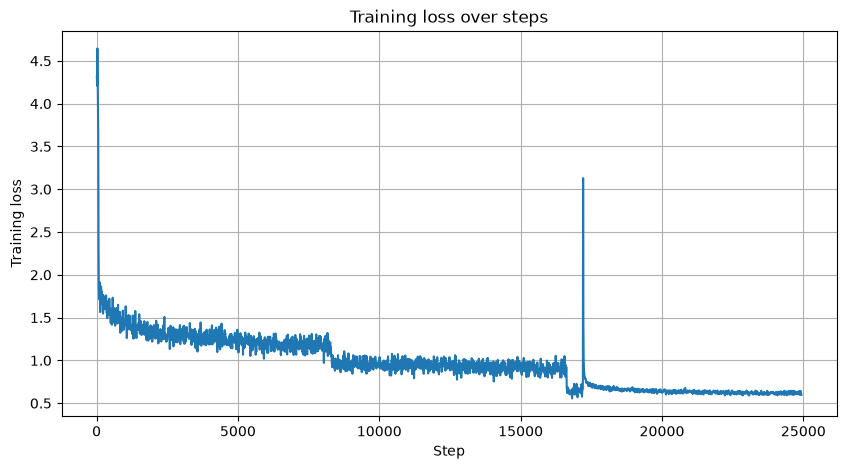


✅ Final logged loss is lower than initial logged loss.


In [20]:
# ============================================================
# Check Cell 2 — Inspect final trainer_state.json and loss history
# Does not load model / does not use GPU
# ============================================================

import json
import pandas as pd
import matplotlib.pyplot as plt

state_path = latest_ckpt / "trainer_state.json"

if not state_path.exists():
    raise FileNotFoundError(f"Missing trainer_state.json: {state_path}")

with open(state_path, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

print("Final checkpoint:", latest_ckpt)
print("global_step:", trainer_state.get("global_step"))
print("epoch:", trainer_state.get("epoch"))
print("max_steps:", trainer_state.get("max_steps"))
print("num_train_epochs:", trainer_state.get("num_train_epochs"))
print("best_model_checkpoint:", trainer_state.get("best_model_checkpoint"))
print("best_metric:", trainer_state.get("best_metric"))

log_history = trainer_state.get("log_history", [])
print("\nlog_history entries:", len(log_history))

log_df = pd.DataFrame(log_history)

print("\nLog columns:")
print(list(log_df.columns))

print("\nLast 30 log entries:")
display(log_df.tail(30))

loss_df = log_df[["step", "loss", "learning_rate", "epoch"]].dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()

if len(loss_df) == 0:
    print("\n⚠️ No training loss found in log_history.")
else:
    print("\nLoss summary:")
    display(loss_df.describe())

    print("\nFirst losses:")
    display(loss_df.head(10))

    print("\nLast losses:")
    display(loss_df.tail(20))

    plt.figure(figsize=(10, 5))
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.xlabel("Step")
    plt.ylabel("Training loss")
    plt.title("Training loss over steps")
    plt.grid(True)
    plt.show()

    if loss_df["loss"].iloc[-1] < loss_df["loss"].iloc[0]:
        print("\n✅ Final logged loss is lower than initial logged loss.")
    else:
        print("\n⚠️ Final logged loss is not lower than initial logged loss. Need inspect more.")

In [21]:
# ============================================================
# Check Cell 3 — Adapter weight drift across checkpoints
# Confirms checkpoints contain real changing LoRA weights
# CPU only, no GPU needed
# ============================================================

import sys
import subprocess
from pathlib import Path
import torch
import pandas as pd

try:
    from safetensors.torch import safe_open
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "safetensors"])
    from safetensors.torch import safe_open

def get_ckpt_by_step(step):
    p = output_dir / f"checkpoint-{step}"
    return p if p.exists() else None

available_steps = [checkpoint_step(p) for p in ckpts]

# Pick meaningful checkpoints:
# first available, checkpoint-900 if present, mid, checkpoint-17200 if present, checkpoint-24900 if present, latest.
candidate_steps = []
candidate_steps.append(available_steps[0])

for s in [900, 17200, 24900, latest_step]:
    if s in available_steps:
        candidate_steps.append(s)

candidate_steps.append(available_steps[len(available_steps) // 2])
candidate_steps = sorted(set(candidate_steps))

selected_ckpts = [get_ckpt_by_step(s) for s in candidate_steps]
selected_ckpts = [p for p in selected_ckpts if p is not None]

print("Selected checkpoints for adapter comparison:")
for p in selected_ckpts:
    print("-", p.name)

def adapter_file(ckpt):
    p = ckpt / "adapter_model.safetensors"
    if p.exists():
        return p

    safes = list(ckpt.glob("*.safetensors"))
    if safes:
        return safes[0]

    raise FileNotFoundError(f"No safetensors adapter file found in {ckpt}")

def adapter_summary(ckpt):
    path = adapter_file(ckpt)

    n_tensors = 0
    n_params = 0
    sum_sq = 0.0
    sum_abs = 0.0
    max_abs = 0.0

    with safe_open(path, framework="pt", device="cpu") as f:
        keys = list(f.keys())
        for k in keys:
            t = f.get_tensor(k).float()
            n_tensors += 1
            n_params += t.numel()
            sum_sq += torch.sum(t * t).item()
            sum_abs += torch.sum(torch.abs(t)).item()
            max_abs = max(max_abs, torch.max(torch.abs(t)).item())

    l2_norm = sum_sq ** 0.5
    mean_abs = sum_abs / max(n_params, 1)

    return {
        "checkpoint": ckpt.name,
        "step": checkpoint_step(ckpt),
        "adapter_file": path.name,
        "n_tensors": n_tensors,
        "n_params": n_params,
        "l2_norm": l2_norm,
        "mean_abs": mean_abs,
        "max_abs": max_abs,
        "file_size": human_size(path.stat().st_size),
    }

summaries = [adapter_summary(p) for p in selected_ckpts]
summary_df = pd.DataFrame(summaries)

print("\nAdapter summaries:")
display(summary_df)

def adapter_l2_distance(ckpt_a, ckpt_b):
    path_a = adapter_file(ckpt_a)
    path_b = adapter_file(ckpt_b)

    sum_sq_diff = 0.0
    sum_sq_a = 0.0
    common = 0

    with safe_open(path_a, framework="pt", device="cpu") as fa, safe_open(path_b, framework="pt", device="cpu") as fb:
        keys_a = set(fa.keys())
        keys_b = set(fb.keys())
        keys = sorted(keys_a & keys_b)

        for k in keys:
            ta = fa.get_tensor(k).float()
            tb = fb.get_tensor(k).float()

            diff = tb - ta
            sum_sq_diff += torch.sum(diff * diff).item()
            sum_sq_a += torch.sum(ta * ta).item()
            common += 1

    diff_l2 = sum_sq_diff ** 0.5
    base_l2 = sum_sq_a ** 0.5
    rel_l2 = diff_l2 / max(base_l2, 1e-12)

    return {
        "from": ckpt_a.name,
        "to": ckpt_b.name,
        "common_tensors": common,
        "diff_l2": diff_l2,
        "relative_l2": rel_l2,
    }

distance_records = []

for a, b in zip(selected_ckpts[:-1], selected_ckpts[1:]):
    distance_records.append(adapter_l2_distance(a, b))

if len(selected_ckpts) >= 2:
    distance_records.append(adapter_l2_distance(selected_ckpts[0], selected_ckpts[-1]))

dist_df = pd.DataFrame(distance_records)

print("\nAdapter drift distances:")
display(dist_df)

if len(dist_df) > 0 and dist_df["diff_l2"].max() > 0:
    print("\n✅ Adapter weights are changing across checkpoints.")
else:
    print("\n⚠️ Adapter weights do not appear to change. This would be suspicious.")

Selected checkpoints for adapter comparison:
- checkpoint-900
- checkpoint-13000
- checkpoint-17200
- checkpoint-24900
- checkpoint-24930

Adapter summaries:


,checkpoint,step,adapter_file,n_tensors,n_params,l2_norm,mean_abs,max_abs,file_size
0,checkpoint-900,900,adapter_model.safetensors,504,29933568,43.757707,0.005517,0.075582,114.25 MB
1,checkpoint-13000,13000,adapter_model.safetensors,504,29933568,96.272611,0.013732,0.182247,114.25 MB
2,checkpoint-17200,17200,adapter_model.safetensors,504,29933568,98.987075,0.014120,0.182065,114.25 MB
3,checkpoint-24900,24900,adapter_model.safetensors,504,29933568,99.315111,0.014167,0.160338,114.25 MB
4,checkpoint-24930,24930,adapter_model.safetensors,504,29933568,99.315111,0.014167,0.160338,114.25 MB



Adapter drift distances:


,from,to,common_tensors,diff_l2,relative_l2
0,checkpoint-900,checkpoint-13000,504,85.769324,1.960096e+00
1,checkpoint-13000,checkpoint-17200,504,22.543943,2.341678e-01
2,checkpoint-17200,checkpoint-24900,504,10.130336,1.023400e-01
3,checkpoint-24900,checkpoint-24930,504,0.000003,3.382205e-08
4,checkpoint-900,checkpoint-24930,504,89.179615,2.038032e+00



✅ Adapter weights are changing across checkpoints.


In [22]:
# ============================================================
# Check Cell 4 — Confirm whether Unsloth is active in this kernel
# ============================================================

import sys

unsloth_modules = [m for m in sys.modules.keys() if m.startswith("unsloth")]

print("Unsloth imported in this kernel:", len(unsloth_modules) > 0)

if unsloth_modules:
    print("\nUnsloth modules found:")
    for m in unsloth_modules[:50]:
        print("-", m)
    print("\n⚠️ Restart kernel before doing clean standard Transformers/PEFT evaluation.")
else:
    print("\n✅ No Unsloth modules currently imported.")

if "trainer" in globals():
    print("\nTrainer class:", trainer.__class__)
    print("Trainer module:", trainer.__class__.__module__)

    if "unsloth" in trainer.__class__.__module__.lower():
        print("\n⚠️ Trainer is Unsloth-patched.")
    else:
        print("\n✅ Trainer does not look Unsloth-patched.")
else:
    print("\nNo trainer object currently found.")

Unsloth imported in this kernel: True

Unsloth modules found:
- unsloth.import_fixes
- unsloth_zoo.hf_cache
- unsloth_zoo.mlx.runtime
- unsloth_zoo.mlx
- unsloth_zoo.model_lists
- unsloth_zoo.mlx_loader
- unsloth_zoo.mlx_trainer
- unsloth_zoo.mlx_utils
- unsloth_zoo.mlx_compile
- unsloth_zoo.mlx_cce
- unsloth_zoo.mlx_cce.runtime_cce
- unsloth_zoo.utils
- unsloth_zoo.device_type
- unsloth_zoo.log
- unsloth_zoo.temporary_patches.common
- unsloth_zoo.temporary_patches.utils
- unsloth_zoo.temporary_patches.gemma
- unsloth_zoo.temporary_patches.misc
- unsloth_zoo.temporary_patches.gemma3n
- unsloth_zoo.temporary_patches.gemma4
- unsloth_zoo.hf_utils
- unsloth_zoo.temporary_patches.moe_utils
- unsloth_zoo.temporary_patches.gpt_oss
- unsloth_zoo.temporary_patches.qwen3_moe
- unsloth_zoo.temporary_patches.qwen3_vl_moe
- unsloth_zoo.temporary_patches.qwen3_next_moe
- unsloth_zoo.temporary_patches.qwen3_5_moe
- unsloth_zoo.temporary_patches.glm4_moe
- unsloth_zoo.temporary_patches.deepseek_v3_mo

In [23]:
# ============================================================
# Check Cell 5 — Load final checkpoint and generate a few samples
# Uses GPU
# NON-UNSLOTH
# ============================================================

import gc
import torch
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# Avoid accidentally keeping old model/trainer in memory
for obj_name in ["model", "trainer"]:
    if obj_name in globals():
        print(f"Deleting old object: {obj_name}")
        del globals()[obj_name]

gc.collect()
torch.cuda.empty_cache()

base_model_dir = PROJECT_DIR / "models" / "hf" / "NileChat-3B-Base"
adapter_ckpt = latest_ckpt

print("Base model:", base_model_dir)
print("Adapter checkpoint:", adapter_ckpt)

dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

tokenizer = AutoTokenizer.from_pretrained(
    str(base_model_dir),
    trust_remote_code=True,
    local_files_only=True,
    use_fast=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    str(base_model_dir),
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    local_files_only=True,
    attn_implementation="sdpa",
)

model = PeftModel.from_pretrained(
    base_model,
    str(adapter_ckpt),
    is_trainable=False,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.use_cache = True
model.eval()

print("\nLoaded final adapter successfully.")
print("GPU memory after load:")
print(torch.cuda.memory_summary(device=0, abbreviated=True))

if "eval_df" not in globals():
    raise RuntimeError("eval_df not found. Run data/prompt cells first before this smoke test.")

if "make_user_prompt" not in globals():
    raise RuntimeError("make_user_prompt function not found. Run prompt-building cell first.")

if "SYSTEM_PROMPT" not in globals():
    SYSTEM_PROMPT = (
        "You are a professional machine translation system. "
        "Translate the current English dialogue turn into natural dialectal Arabic. "
        "Return only the translation, without explanation."
    )

sample_df = eval_df.sample(n=min(5, len(eval_df)), random_state=SEED).copy()

def arabic_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0.0
    ar = sum(1 for ch in text if "\u0600" <= ch <= "\u06FF")
    return ar / max(len(text), 1)

def generate_one(row):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": make_user_prompt(row)},
    ]

    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
        input_ids = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
        ).to(model.device)
        attention_mask = torch.ones_like(input_ids)
    else:
        prompt = messages[0]["content"] + "\n\n" + messages[1]["content"] + "\n\nArabic:"
        encoded = tokenizer(prompt, return_tensors="pt")
        input_ids = encoded["input_ids"].to(model.device)
        attention_mask = encoded["attention_mask"].to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=4,
            num_return_sequences=1,
            length_penalty=1.0,
            early_stopping=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    gen_ids = out[0][input_ids.shape[-1]:]
    pred = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
    return pred

rows = []

for _, row in sample_df.iterrows():
    pred = generate_one(row)

    rows.append({
        "source_id": row.get("source_id", ""),
        "config": row.get("config", ""),
        "source_text": row.get("source_text", ""),
        "reference": row.get("target_arabic", ""),
        "prediction": pred,
        "prediction_len": len(pred),
        "arabic_ratio": arabic_ratio(pred),
    })

smoke_df = pd.DataFrame(rows)

display(smoke_df)

print("\nQuick warnings:")
if (smoke_df["prediction_len"] == 0).any():
    print("⚠️ Some predictions are empty.")
if (smoke_df["arabic_ratio"] < 0.3).any():
    print("⚠️ Some predictions have low Arabic ratio.")
if not (smoke_df["prediction_len"] == 0).any() and not (smoke_df["arabic_ratio"] < 0.3).any():
    print("✅ Smoke test looks reasonable.")

Deleting old object: model
Deleting old object: trainer
Base model: /home/mabdallah/alexandriax_mt_14d/models/hf/NileChat-3B-Base
Adapter checkpoint: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-24930


Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]


Loaded final adapter successfully.
GPU memory after load:
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   6019 MiB |   6795 MiB |  25795 MiB |  19776 MiB |
|---------------------------------------------------------------------------|
| Active memory         |   6019 MiB |   6795 MiB |  25795 MiB |  19776 MiB |
|---------------------------------------------------------------------------|
| Requested memory      |   6008 MiB |   6784 MiB |  25773 MiB |  19765 MiB |
|----

,source_id,config,source_text,reference,prediction,prediction_len,arabic_ratio
0,LY_test_B3-12-2-215_0,LY,The design is very modern. I want to check the...,التصميم حديث جدا. نبي نتأكد من جودة التشطيب.,"Return only the target local dialect, not Mode...",208,0.182692
1,TN_test_B2-11-1-257_0,TN,"Hello, we're a group of five. Is it okay if we...",عسلامة، إحنا خمسة. نجموا ناخذو الطاولة هاذي ون...,"Return only the target local dialect, not Mode...",327,0.159021
2,SA_test_B11-6-7-332_1,SA,Good afternoon. The price displayed on the she...,مساء النور، السعر المعروض على الرف هو اللي يحق...,### Arabic translation:\nمساء النور، السعر الل...,94,0.617021
3,OM_test_B5-13-1-1_0,OM,"Good evening, my friend. I have a photo on my ...",مساء الخير اخوي، عندي صوره فتلفوني، تقدر تسوي ...,"Return only the target local dialect, not Mode...",221,0.217195
4,JO_test_B6-4-1-215_3,JO,"Fine, here you go. Are you satisfied now?",ماشي، هاي خذ، مبسوط هسا؟,### Arabic translation:\nتمام، تفضل. راضي هسا؟,45,0.377778



Quick warnings:
⚠️ Some predictions have low Arabic ratio.


---

### **Checkpoints Sweep for the Best Performance**

In [18]:
# ============================================================
# Cell 17 — Inventory checkpoints and select every 500 steps
# Corrected prompt format: training-style marker prompt
# No model loading, no GPU usage
# ============================================================

from pathlib import Path
import json
import math
import os
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# Main sweep settings
# ------------------------------------------------------------

DECODE_TAG = "beam4"
PROMPT_FORMAT_TAG = "training_style_marker_v2"

# New constraint:
# evaluate only checkpoint steps divisible by 500.
EVAL_EVERY_STEPS = 500

# Keep final checkpoint too, even if not divisible by 500.
# Example: checkpoint-24930 is not divisible by 500, but it is useful to evaluate.
INCLUDE_FINAL_CHECKPOINT = True

OUTPUT_DIR = Path(OUTPUT_DIR)

print("OUTPUT_DIR:", OUTPUT_DIR)
print("DECODE_TAG:", DECODE_TAG)
print("PROMPT_FORMAT_TAG:", PROMPT_FORMAT_TAG)
print("EVAL_EVERY_STEPS:", EVAL_EVERY_STEPS)
print("INCLUDE_FINAL_CHECKPOINT:", INCLUDE_FINAL_CHECKPOINT)

if not OUTPUT_DIR.exists():
    raise FileNotFoundError(f"OUTPUT_DIR does not exist: {OUTPUT_DIR}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def checkpoint_step(path):
    try:
        return int(Path(path).name.replace("checkpoint-", ""))
    except Exception:
        return -1

def human_size(num_bytes):
    n = float(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PB"

def folder_size_bytes(path):
    total = 0
    for f in Path(path).rglob("*"):
        if f.is_file():
            total += f.stat().st_size
    return total

def latest_mtime(path):
    mtimes = [f.stat().st_mtime for f in Path(path).rglob("*") if f.is_file()]
    return max(mtimes) if mtimes else Path(path).stat().st_mtime

def find_adapter_weight_file(ckpt_path):
    ckpt_path = Path(ckpt_path)

    for name in ["adapter_model.safetensors", "adapter_model.bin"]:
        p = ckpt_path / name
        if p.exists():
            return p

    safes = list(ckpt_path.glob("*.safetensors"))
    return safes[0] if safes else None

# ------------------------------------------------------------
# Inventory all checkpoints
# ------------------------------------------------------------

checkpoint_dirs = sorted(
    [p for p in OUTPUT_DIR.glob("checkpoint-*") if p.is_dir()],
    key=checkpoint_step,
)

if not checkpoint_dirs:
    raise RuntimeError(f"No checkpoint folders found under: {OUTPUT_DIR}")

records = []

for ckpt in checkpoint_dirs:
    step = checkpoint_step(ckpt)
    adapter_file = find_adapter_weight_file(ckpt)

    trainer_state_path = ckpt / "trainer_state.json"
    trainer_global_step = None
    trainer_epoch = None
    log_history_len = None
    last_loss = None

    if trainer_state_path.exists():
        try:
            with open(trainer_state_path, "r", encoding="utf-8") as f:
                state = json.load(f)

            trainer_global_step = state.get("global_step", None)
            trainer_epoch = state.get("epoch", None)
            log_history = state.get("log_history", [])
            log_history_len = len(log_history)

            loss_values = [x.get("loss") for x in log_history if "loss" in x]
            last_loss = loss_values[-1] if loss_values else None

        except Exception as e:
            trainer_global_step = f"ERR: {type(e).__name__}"

    size_b = folder_size_bytes(ckpt)
    mtime_str = datetime.fromtimestamp(latest_mtime(ckpt)).strftime("%Y-%m-%d %H:%M:%S")

    records.append({
        "step": step,
        "checkpoint": ckpt.name,
        "path": str(ckpt),
        "size": human_size(size_b),
        "size_bytes": size_b,
        "mtime": mtime_str,
        "has_adapter_config": (ckpt / "adapter_config.json").exists(),
        "has_adapter_weights": adapter_file is not None,
        "adapter_file": adapter_file.name if adapter_file is not None else None,
        "has_optimizer": (ckpt / "optimizer.pt").exists(),
        "has_scheduler": (ckpt / "scheduler.pt").exists(),
        "has_trainer_state": trainer_state_path.exists(),
        "trainer_global_step": trainer_global_step,
        "trainer_epoch": trainer_epoch,
        "log_history_len": log_history_len,
        "last_loss": last_loss,
    })

ckpt_inventory_df = pd.DataFrame(records)

valid_ckpt_df = ckpt_inventory_df[
    (ckpt_inventory_df["step"] > 0)
    & (ckpt_inventory_df["has_adapter_config"])
    & (ckpt_inventory_df["has_adapter_weights"])
].copy()

valid_ckpt_df = valid_ckpt_df.sort_values("step").reset_index(drop=True)

if len(valid_ckpt_df) == 0:
    raise RuntimeError("No valid PEFT adapter checkpoints found.")

ALL_CHECKPOINTS = [Path(p) for p in valid_ckpt_df["path"].tolist()]
ALL_CHECKPOINT_STEPS = [int(s) for s in valid_ckpt_df["step"].tolist()]

# ------------------------------------------------------------
# Select only every 500-step checkpoint
# ------------------------------------------------------------

selected_ckpt_df = valid_ckpt_df[
    valid_ckpt_df["step"].astype(int) % EVAL_EVERY_STEPS == 0
].copy()

if INCLUDE_FINAL_CHECKPOINT:
    final_row = valid_ckpt_df.tail(1).copy()
    selected_ckpt_df = pd.concat([selected_ckpt_df, final_row], ignore_index=True)
    selected_ckpt_df = selected_ckpt_df.drop_duplicates(subset=["step"], keep="first")

selected_ckpt_df = selected_ckpt_df.sort_values("step").reset_index(drop=True)

if len(selected_ckpt_df) == 0:
    raise RuntimeError(
        f"No checkpoints selected. No valid checkpoints divisible by {EVAL_EVERY_STEPS}."
    )

SWEEP_CHECKPOINTS = [Path(p) for p in selected_ckpt_df["path"].tolist()]
SWEEP_CHECKPOINT_STEPS = [int(s) for s in selected_ckpt_df["step"].tolist()]

# Keep aliases for compatibility with earlier code.
SELECTED_CHECKPOINTS = SWEEP_CHECKPOINTS
SELECTED_CHECKPOINT_STEPS = SWEEP_CHECKPOINT_STEPS

# ------------------------------------------------------------
# Corrected sweep output directory
# ------------------------------------------------------------

FULL_SWEEP_TAG = (
    f"full_checkpoint_sweep_{DECODE_TAG}_"
    f"{PROMPT_FORMAT_TAG}_every{EVAL_EVERY_STEPS}"
)

FULL_SWEEP_DIR = PRED_DIR / f"{EXPERIMENT_NAME}_{FULL_SWEEP_TAG}"
FULL_SWEEP_PRED_DIR = FULL_SWEEP_DIR / "predictions"
FULL_SWEEP_METRICS_DIR = FULL_SWEEP_DIR / "metrics"
FULL_SWEEP_RESULTS_CSV = FULL_SWEEP_DIR / "sweep_results_live.csv"
FULL_SWEEP_RANKED_CSV = FULL_SWEEP_DIR / "sweep_results_ranked.csv"

for p in [FULL_SWEEP_DIR, FULL_SWEEP_PRED_DIR, FULL_SWEEP_METRICS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Display inventory
# ------------------------------------------------------------

print("\n==============================")
print("Checkpoint Inventory")
print("==============================")
print("Total checkpoint folders:", len(checkpoint_dirs))
print("Valid adapter checkpoints:", len(ALL_CHECKPOINTS))
print("First valid step:", ALL_CHECKPOINT_STEPS[0])
print("Last valid step:", ALL_CHECKPOINT_STEPS[-1])

print("\n==============================")
print("Selected Sweep Checkpoints")
print("==============================")
print("Evaluate every:", EVAL_EVERY_STEPS, "steps")
print("Selected checkpoints:", len(SWEEP_CHECKPOINTS))
print("First selected step:", SWEEP_CHECKPOINT_STEPS[0])
print("Last selected step:", SWEEP_CHECKPOINT_STEPS[-1])
print("Corrected sweep dir:", FULL_SWEEP_DIR)

print("\nSelected checkpoints:")
display(selected_ckpt_df[[
    "step",
    "checkpoint",
    "path",
    "size",
    "mtime",
    "last_loss",
    "trainer_epoch",
]])

print("\nLast 20 valid checkpoints:")
display(valid_ckpt_df.tail(20))

bad_ckpt_df = ckpt_inventory_df[
    ~ckpt_inventory_df["path"].isin(valid_ckpt_df["path"])
].copy()

print("\nInvalid/incomplete checkpoints:")
display(bad_ckpt_df)

# ------------------------------------------------------------
# Expected final step sanity check
# ------------------------------------------------------------

n_train = None

if "train_dataset_text" in globals():
    n_train = len(train_dataset_text)
elif "train_dataset" in globals():
    n_train = len(train_dataset)
elif "train_df" in globals():
    n_train = len(train_df)

if n_train is not None:
    per_device_bs = globals().get("PER_DEVICE_BATCH_SIZE", 1)
    grad_acc = globals().get("GRAD_ACCUM_STEPS", 8)
    epochs = globals().get("NUM_EPOCHS", 3)

    expected_steps_per_epoch = math.ceil(n_train / (per_device_bs * grad_acc))
    expected_total_steps = expected_steps_per_epoch * epochs

    print("\n==============================")
    print("Expected Step Check")
    print("==============================")
    print("n_train:", n_train)
    print("per_device_batch_size:", per_device_bs)
    print("gradient_accumulation_steps:", grad_acc)
    print("epochs:", epochs)
    print("expected_steps_per_epoch:", expected_steps_per_epoch)
    print("expected_total_steps:", expected_total_steps)
    print("latest_checkpoint_step:", ALL_CHECKPOINT_STEPS[-1])

    if ALL_CHECKPOINT_STEPS[-1] == expected_total_steps:
        print("✅ Latest checkpoint step matches expected total steps.")
    else:
        print("⚠️ Latest checkpoint step does not exactly match expected total steps.")
else:
    print("\nCould not compute expected total steps because train dataset is not loaded.")

print("\nCell 17 ready.")
print("SWEEP_CHECKPOINTS contains only every-500 checkpoints plus final if enabled.")

OUTPUT_DIR: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1
DECODE_TAG: beam4
PROMPT_FORMAT_TAG: training_style_marker_v2
EVAL_EVERY_STEPS: 500
INCLUDE_FINAL_CHECKPOINT: True

Checkpoint Inventory
Total checkpoint folders: 242
Valid adapter checkpoints: 242
First valid step: 900
Last valid step: 24930

Selected Sweep Checkpoints
Evaluate every: 500 steps
Selected checkpoints: 49
First selected step: 1000
Last selected step: 24930
Corrected sweep dir: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500

Selected checkpoints:


,step,checkpoint,path,size,mtime,last_loss,trainer_epoch
0,1000,checkpoint-1000,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,353.97 MB,2026-06-28 22:51:27,1.473329,0.120337
1,1500,checkpoint-1500,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,353.98 MB,2026-06-29 00:18:11,1.402916,0.180505
2,2000,checkpoint-2000,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,353.99 MB,2026-06-29 01:17:45,1.392448,0.240674
3,2500,checkpoint-2500,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.00 MB,2026-06-29 02:12:56,1.234969,0.300842
4,3000,checkpoint-3000,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.01 MB,2026-06-29 03:08:05,1.307936,0.361011
5,3500,checkpoint-3500,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.02 MB,2026-06-29 04:03:17,1.177107,0.421179
6,4000,checkpoint-4000,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.03 MB,2026-06-29 04:58:26,1.362159,0.481348
7,4500,checkpoint-4500,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.04 MB,2026-06-29 05:53:40,1.238347,0.541516
8,5000,checkpoint-5000,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.05 MB,2026-06-29 06:48:59,1.176901,0.601685
9,5500,checkpoint-5500,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.06 MB,2026-06-29 07:44:22,1.241111,0.661853



Last 20 valid checkpoints:


,step,checkpoint,path,size,size_bytes,mtime,has_adapter_config,has_adapter_weights,adapter_file,has_optimizer,has_scheduler,has_trainer_state,trainer_global_step,trainer_epoch,log_history_len,last_loss
222,23100,checkpoint-23100,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.41 MB,371629820,2026-07-01 21:33:16,True,True,adapter_model.safetensors,True,True,True,23100,2.779783,2541,0.612279
223,23200,checkpoint-23200,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.42 MB,371631923,2026-07-01 21:44:25,True,True,adapter_model.safetensors,True,True,True,23200,2.791817,2552,0.631863
224,23300,checkpoint-23300,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.42 MB,371634020,2026-07-01 21:55:35,True,True,adapter_model.safetensors,True,True,True,23300,2.803851,2563,0.615999
225,23400,checkpoint-23400,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.42 MB,371636120,2026-07-01 22:06:45,True,True,adapter_model.safetensors,True,True,True,23400,2.815884,2574,0.603006
226,23500,checkpoint-23500,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.42 MB,371638227,2026-07-01 22:17:54,True,True,adapter_model.safetensors,True,True,True,23500,2.827918,2585,0.621154
227,23600,checkpoint-23600,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.90 MB,372139975,2026-07-01 22:29:04,True,True,adapter_model.safetensors,True,True,True,23600,2.839952,2596,0.600251
228,23700,checkpoint-23700,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.43 MB,371642427,2026-07-01 22:40:13,True,True,adapter_model.safetensors,True,True,True,23700,2.851986,2607,0.623865
229,23800,checkpoint-23800,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.43 MB,371644520,2026-07-01 22:51:20,True,True,adapter_model.safetensors,True,True,True,23800,2.864019,2618,0.600198
230,23900,checkpoint-23900,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.43 MB,371646613,2026-07-01 23:02:30,True,True,adapter_model.safetensors,True,True,True,23900,2.876053,2629,0.624719
231,24000,checkpoint-24000,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,354.43 MB,371648699,2026-07-01 23:13:39,True,True,adapter_model.safetensors,True,True,True,24000,2.888087,2640,0.620819



Invalid/incomplete checkpoints:


,step,checkpoint,path,size,size_bytes,mtime,has_adapter_config,has_adapter_weights,adapter_file,has_optimizer,has_scheduler,has_trainer_state,trainer_global_step,trainer_epoch,log_history_len,last_loss



Expected Step Check
n_train: 66480
per_device_batch_size: 1
gradient_accumulation_steps: 8
epochs: 3
expected_steps_per_epoch: 8310
expected_total_steps: 24930
latest_checkpoint_step: 24930
✅ Latest checkpoint step matches expected total steps.

Cell 17 ready.
SWEEP_CHECKPOINTS contains only every-500 checkpoints plus final if enabled.


### **Inference with Beam4 Search over all checkpoints**

In [25]:
# ============================================================
# Cell 18 — Corrected FULL eval/test Beam4 sweep
# Evaluates only selected checkpoints from Cell 17:
# every 500 steps + optional final checkpoint
# Resumable by checkpoint and by row
# Uses training-style prompt ending with: ### Arabic translation:
# Few-shot preserved through make_user_prompt(row)
# NON-UNSLOTH
# ============================================================

import os
import sys
import gc
import json
import time
from pathlib import Path

import torch
import pandas as pd
import sacrebleu
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

if "unsloth" in sys.modules:
    raise RuntimeError(
        "Unsloth is imported in this kernel. Restart kernel before running this sweep."
    )

if "SWEEP_CHECKPOINTS" not in globals() or not SWEEP_CHECKPOINTS:
    raise RuntimeError("Run Cell 17 first. SWEEP_CHECKPOINTS is missing.")

if "eval_df" not in globals():
    raise RuntimeError("eval_df is missing. Run the data/prompt cells first.")

if "make_user_prompt" not in globals():
    raise RuntimeError("make_user_prompt is missing. Run the prompt-building cell first.")

if "SYSTEM_PROMPT" not in globals():
    raise RuntimeError("SYSTEM_PROMPT is missing. Run Cell 9 first.")

# Clear stale training objects from GPU.
for obj_name in ["trainer", "model", "base_model"]:
    if obj_name in globals():
        print(f"Deleting old object from memory: {obj_name}")
        del globals()[obj_name]

gc.collect()
torch.cuda.empty_cache()

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------

DECODE_TAG = "beam4"
PROMPT_FORMAT_TAG = "training_style_marker_v2"

if "EVAL_EVERY_STEPS" not in globals():
    EVAL_EVERY_STEPS = 500

MAX_NEW_TOKENS = globals().get("MAX_NEW_TOKENS", 120)

GENERATION_KWARGS = {
    "do_sample": False,
    "num_beams": 4,
    "num_return_sequences": 1,
    "length_penalty": 1.0,
    "early_stopping": True,
    "repetition_penalty": 1.05,

    # Corrected pipeline is pure Transformers/PEFT, no Unsloth.
    # If OOM or cache issue occurs, set this False and rerun; progress is resumable.
    "use_cache": True,
}

# RTX 5090 should usually handle 2 with beam4.
# Increase to 4 only after a successful small run.
GEN_BATCH_SIZE = 2

SAVE_EVERY = 50
RETRY_ERROR_ROWS = True
SKIP_COMPLETED_CHECKPOINTS = True

# For debugging only. Keep None for the real sweep.
STOP_AFTER_N_CHECKPOINTS = None

BASE_MODEL_DIR = PROJECT_DIR / "models" / "hf" / "NileChat-3B-Base"

if not BASE_MODEL_DIR.exists():
    BASE_MODEL_DIR = Path(MODEL_NAME)

if not BASE_MODEL_DIR.exists():
    raise FileNotFoundError(f"Base model folder not found: {BASE_MODEL_DIR}")

print("Base model dir:", BASE_MODEL_DIR)
print("Decode tag:", DECODE_TAG)
print("Prompt format:", PROMPT_FORMAT_TAG)
print("Evaluate every steps:", EVAL_EVERY_STEPS)
print("Generation kwargs:", GENERATION_KWARGS)
print("GEN_BATCH_SIZE:", GEN_BATCH_SIZE)
print("Max new tokens:", MAX_NEW_TOKENS)
print("Sweep dir:", FULL_SWEEP_DIR)
print("Selected checkpoints to sweep:", len(SWEEP_CHECKPOINTS))
print("Selected steps:", SWEEP_CHECKPOINT_STEPS)

# ------------------------------------------------------------
# Eval dataframe
# ------------------------------------------------------------

full_eval_df = eval_df.reset_index(drop=True).copy()
full_eval_df["source_id"] = full_eval_df["source_id"].astype(str)

expected_n = len(full_eval_df)
expected_ids = set(full_eval_df["source_id"].tolist())

order_df = full_eval_df[["source_id"]].copy()
order_df["eval_order"] = range(len(order_df))

print("Full eval/test examples:", expected_n)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def checkpoint_step(path):
    try:
        return int(Path(path).name.replace("checkpoint-", ""))
    except Exception:
        return -1

def arabic_ratio(text):
    text = "" if text is None else str(text)
    if len(text.strip()) == 0:
        return 0.0
    ar = sum(1 for ch in text if "\u0600" <= ch <= "\u06FF")
    return ar / max(len(text), 1)

def latin_ratio(text):
    text = "" if text is None else str(text)
    if len(text.strip()) == 0:
        return 0.0
    latin = sum(1 for ch in text if ("a" <= ch.lower() <= "z"))
    return latin / max(len(text), 1)

def has_prompt_leak(text):
    t = "" if text is None else str(text).lower()

    bad_phrases = [
        "return only",
        "do not add",
        "don't add",
        "target local dialect",
        "modern standard arabic",
        "arabic translation",
        "translation:",
        "###",
        "task:",
        "rules:",
        "metadata:",
        "previous english",
        "current english",
        "few-shot",
        "example",
        "preserve the meaning",
        "speaker-to-addressee",
    ]

    return any(p in t for p in bad_phrases)

def strip_special_tokens(text, tokenizer=None):
    text = "" if text is None else str(text)

    specials = [
        "<|endoftext|>",
        "<|im_end|>",
        "<|im_start|>",
        "<turn|>",
    ]

    if tokenizer is not None:
        for tok in [getattr(tokenizer, "eos_token", None), getattr(tokenizer, "pad_token", None)]:
            if tok:
                specials.append(tok)

    for tok in specials:
        text = text.replace(tok, "")

    return text.strip()

def postprocess_prediction(text):
    text = strip_special_tokens(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n").strip()

    split_markers = [
        "### Arabic translation:",
        "### Arabic Translation:",
        "Arabic translation:",
        "Arabic Translation:",
        "### Arabic:",
        "Arabic:",
        "الترجمة العربية:",
        "الترجمة:",
    ]

    for marker in split_markers:
        if marker in text:
            text = text.split(marker)[-1].strip()

    text = text.strip("`").strip()
    text = text.replace("###", "").strip()

    lines = [ln.strip() for ln in text.split("\n") if ln.strip()]
    kept_lines = []

    for ln in lines:
        low = ln.lower().strip()

        drop_prefixes = [
            "return only",
            "do not",
            "don't add",
            "preserve",
            "use the",
            "task:",
            "rules:",
            "metadata:",
            "previous english",
            "current english",
            "few-shot",
            "example",
            "english:",
            "arabic translation",
            "translation:",
            "target dialect",
            "speaker-to-addressee",
        ]

        if any(low.startswith(p) for p in drop_prefixes):
            continue

        if arabic_ratio(ln) < 0.10 and latin_ratio(ln) > 0.35:
            continue

        kept_lines.append(ln)

    cleaned = " ".join(kept_lines).strip()

    if not cleaned and arabic_ratio(text) > 0.10:
        arabic_lines = [ln for ln in lines if arabic_ratio(ln) > 0.10]
        cleaned = " ".join(arabic_lines).strip()

    return cleaned

def compute_metrics_for_predictions(df):
    df = df.copy()

    df["raw_prediction"] = df["raw_prediction"].fillna("").astype(str)
    df["clean_prediction"] = df["clean_prediction"].fillna("").astype(str)
    df["reference_arabic"] = df["reference_arabic"].fillna("").astype(str)

    raw_preds = df["raw_prediction"].tolist()
    clean_preds = df["clean_prediction"].tolist()
    refs = df["reference_arabic"].tolist()

    raw_bleu = sacrebleu.corpus_bleu(raw_preds, [refs])
    raw_spbleu = sacrebleu.corpus_bleu(raw_preds, [refs], tokenize="flores200")
    raw_chrf = sacrebleu.corpus_chrf(raw_preds, [refs])
    raw_chrfpp = sacrebleu.corpus_chrf(raw_preds, [refs], word_order=2)

    clean_bleu = sacrebleu.corpus_bleu(clean_preds, [refs])
    clean_spbleu = sacrebleu.corpus_bleu(clean_preds, [refs], tokenize="flores200")
    clean_chrf = sacrebleu.corpus_chrf(clean_preds, [refs])
    clean_chrfpp = sacrebleu.corpus_chrf(clean_preds, [refs], word_order=2)

    raw_empty_rate = (df["raw_prediction"].str.strip() == "").mean()
    clean_empty_rate = (df["clean_prediction"].str.strip() == "").mean()

    raw_prompt_leak_rate = df["raw_prediction"].apply(has_prompt_leak).mean()
    clean_prompt_leak_rate = df["clean_prediction"].apply(has_prompt_leak).mean()

    raw_arabic_ratio_mean = df["raw_prediction"].apply(arabic_ratio).mean()
    clean_arabic_ratio_mean = df["clean_prediction"].apply(arabic_ratio).mean()

    ref_len = df["reference_arabic"].str.len().clip(lower=1)
    clean_len = df["clean_prediction"].str.len()
    clean_too_long_rate = ((clean_len / ref_len) > 3.0).mean()

    generation_error_rate = 0.0
    if "generation_error" in df.columns:
        generation_error_rate = (
            df["generation_error"].fillna("").astype(str).str.strip() != ""
        ).mean()

    return {
        "num_examples": int(len(df)),

        "raw_BLEU": float(raw_bleu.score),
        "raw_spBLEU": float(raw_spbleu.score),
        "raw_chrF": float(raw_chrf.score),
        "raw_chrFpp": float(raw_chrfpp.score),

        "clean_BLEU": float(clean_bleu.score),
        "clean_spBLEU": float(clean_spbleu.score),
        "clean_chrF": float(clean_chrf.score),
        "clean_chrFpp": float(clean_chrfpp.score),

        "raw_empty_rate": float(raw_empty_rate),
        "clean_empty_rate": float(clean_empty_rate),
        "raw_prompt_leak_rate": float(raw_prompt_leak_rate),
        "clean_prompt_leak_rate": float(clean_prompt_leak_rate),
        "raw_arabic_ratio_mean": float(raw_arabic_ratio_mean),
        "clean_arabic_ratio_mean": float(clean_arabic_ratio_mean),
        "clean_too_long_rate": float(clean_too_long_rate),
        "generation_error_rate": float(generation_error_rate),
    }

def build_training_style_generation_prompt(row_dict):
    """
    Corrected inference prompt.
    This intentionally does NOT use tokenizer.apply_chat_template.

    make_user_prompt(row_dict) already includes:
    - metadata
    - previous context
    - current turn
    - few-shot examples
    - rules
    """
    user_text = make_user_prompt(row_dict)

    if "format_sft_text" in globals():
        try:
            return format_sft_text(
                system_text=SYSTEM_PROMPT,
                user_text=user_text,
                assistant_text=None,
                add_eos=False,
            )
        except TypeError:
            pass
        except Exception as e:
            print("format_sft_text failed; using manual marker fallback:", repr(e))

    return (
        f"{SYSTEM_PROMPT}\n\n"
        f"{user_text}\n\n"
        "### Arabic translation:\n"
    )

def load_model_for_checkpoint(ckpt_path):
    dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

    tokenizer = AutoTokenizer.from_pretrained(
        str(BASE_MODEL_DIR),
        trust_remote_code=True,
        local_files_only=True,
        use_fast=True,
    )

    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "left"

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        str(BASE_MODEL_DIR),
        torch_dtype=dtype,
        device_map="auto",
        trust_remote_code=True,
        local_files_only=True,
        attn_implementation="sdpa",
    )

    model = PeftModel.from_pretrained(
        base_model,
        str(ckpt_path),
        is_trainable=False,
    )

    model.config.use_cache = bool(GENERATION_KWARGS.get("use_cache", True))
    model.eval()

    return model, tokenizer

def generate_batch(model, tokenizer, row_dicts):
    prompts = [build_training_style_generation_prompt(r) for r in row_dicts]

    encoded = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    )

    device = next(model.parameters()).device
    encoded = {k: v.to(device) for k, v in encoded.items()}

    prompt_len = encoded["input_ids"].shape[-1]

    try:
        with torch.no_grad():
            outputs = model.generate(
                **encoded,
                max_new_tokens=MAX_NEW_TOKENS,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
                **GENERATION_KWARGS,
            )

        results = []

        for i in range(len(row_dicts)):
            gen_ids = outputs[i][prompt_len:]
            raw_pred = tokenizer.decode(gen_ids, skip_special_tokens=False)
            raw_pred = strip_special_tokens(raw_pred, tokenizer)
            clean_pred = postprocess_prediction(raw_pred)
            results.append((raw_pred, clean_pred, ""))

        return results

    except RuntimeError as e:
        if "out of memory" in str(e).lower() and len(row_dicts) > 1:
            print(f"\nOOM with batch size {len(row_dicts)}. Splitting batch.")
            torch.cuda.empty_cache()

            split = len(row_dicts) // 2
            return (
                generate_batch(model, tokenizer, row_dicts[:split])
                + generate_batch(model, tokenizer, row_dicts[split:])
            )

        raise

def checkpoint_paths(step):
    pred_path = FULL_SWEEP_PRED_DIR / (
        f"checkpoint_{step}_full_eval_{DECODE_TAG}_"
        f"{PROMPT_FORMAT_TAG}_every{EVAL_EVERY_STEPS}_predictions.csv"
    )

    metrics_path = FULL_SWEEP_METRICS_DIR / (
        f"checkpoint_{step}_full_eval_{DECODE_TAG}_"
        f"{PROMPT_FORMAT_TAG}_every{EVAL_EVERY_STEPS}_metrics.json"
    )

    return pred_path, metrics_path

def save_prediction_rows(pred_rows_by_id, pred_path):
    tmp_df = pd.DataFrame(list(pred_rows_by_id.values()))

    if len(tmp_df):
        tmp_df["source_id"] = tmp_df["source_id"].astype(str)
        tmp_df = tmp_df.merge(order_df, on="source_id", how="left")
        tmp_df = tmp_df.sort_values("eval_order").drop(columns=["eval_order"])
        tmp_df = tmp_df.reset_index(drop=True)

    tmp_df.to_csv(pred_path, index=False, encoding="utf-8-sig")
    return tmp_df

def load_existing_predictions(pred_path):
    if not pred_path.exists():
        return {}

    existing_df = pd.read_csv(pred_path)

    if "source_id" not in existing_df.columns:
        return {}

    existing_df["source_id"] = existing_df["source_id"].astype(str)
    existing_df = existing_df[existing_df["source_id"].isin(expected_ids)].copy()
    existing_df = existing_df.drop_duplicates(subset=["source_id"], keep="first")

    if RETRY_ERROR_ROWS and "generation_error" in existing_df.columns:
        err_mask = existing_df["generation_error"].fillna("").astype(str).str.strip() != ""
        if err_mask.any():
            print(f"Retrying {err_mask.sum()} previous error rows.")
            existing_df = existing_df[~err_mask].copy()

    return {
        str(row["source_id"]): row
        for row in existing_df.to_dict("records")
    }

def evaluate_one_checkpoint(ckpt_path):
    ckpt_path = Path(ckpt_path)
    step = checkpoint_step(ckpt_path)

    pred_path, metrics_path = checkpoint_paths(step)

    print("\n" + "=" * 90)
    print(f"Checkpoint step: {step}")
    print("Checkpoint path:", ckpt_path)
    print("Prediction path:", pred_path)
    print("Metrics path:", metrics_path)

    if SKIP_COMPLETED_CHECKPOINTS and metrics_path.exists():
        with open(metrics_path, "r", encoding="utf-8") as f:
            metrics = json.load(f)

        if (
            metrics.get("prompt_format_tag") == PROMPT_FORMAT_TAG
            and int(metrics.get("eval_every_steps", -1)) == int(EVAL_EVERY_STEPS)
        ):
            print("✅ Corrected metrics already exist. Skipping checkpoint.")
            return metrics
        else:
            print("Existing metrics use old format/settings. Recomputing.")

    pred_rows_by_id = load_existing_predictions(pred_path)
    done_ids = set(pred_rows_by_id.keys())

    print(f"Existing completed rows: {len(done_ids)} / {expected_n}")

    if len(done_ids) == expected_n:
        print("Prediction file already complete. Recomputing clean predictions + metrics.")
        pred_df = save_prediction_rows(pred_rows_by_id, pred_path)

        pred_df["raw_prediction"] = pred_df["raw_prediction"].fillna("").astype(str)
        pred_df["clean_prediction"] = pred_df["raw_prediction"].apply(postprocess_prediction)
        pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

        metrics = compute_metrics_for_predictions(pred_df)
        metrics.update({
            "checkpoint_step": int(step),
            "checkpoint_path": str(ckpt_path),
            "prediction_file": str(pred_path),
            "metrics_file": str(metrics_path),
            "decode_tag": DECODE_TAG,
            "prompt_format_tag": PROMPT_FORMAT_TAG,
            "eval_every_steps": int(EVAL_EVERY_STEPS),
            "generation_kwargs": str(GENERATION_KWARGS),
            "experiment_name": EXPERIMENT_NAME,
            "completed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        })

        with open(metrics_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, ensure_ascii=False, indent=2)

        return metrics

    model = None
    tokenizer = None

    try:
        model, tokenizer = load_model_for_checkpoint(ckpt_path)

        start_time = time.time()
        rows_generated_since_save = 0
        pending_batch = []

        for _, row in tqdm(full_eval_df.iterrows(), total=expected_n, desc=f"step {step}"):
            row_dict = row.to_dict()
            source_id = str(row_dict["source_id"])

            if source_id in done_ids:
                continue

            pending_batch.append(row_dict)

            if len(pending_batch) < GEN_BATCH_SIZE:
                continue

            batch_results = generate_batch(model, tokenizer, pending_batch)

            for one_row_dict, (raw_pred, clean_pred, gen_err) in zip(pending_batch, batch_results):
                sid = str(one_row_dict["source_id"])

                out_row = {
                    "source_id": sid,
                    "config": one_row_dict.get("config", ""),
                    "dialect": one_row_dict.get("dialect", ""),
                    "domain": one_row_dict.get("domain", ""),
                    "source_text": one_row_dict.get("source_text", ""),
                    "reference_arabic": one_row_dict.get("target_arabic", ""),
                    "raw_prediction": raw_pred,
                    "clean_prediction": clean_pred,
                    "checkpoint_step": step,
                    "checkpoint_path": str(ckpt_path),
                    "decode_tag": DECODE_TAG,
                    "prompt_format_tag": PROMPT_FORMAT_TAG,
                    "eval_every_steps": int(EVAL_EVERY_STEPS),
                    "generation_kwargs": str(GENERATION_KWARGS),
                    "generation_error": gen_err,
                    "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
                }

                pred_rows_by_id[sid] = out_row
                done_ids.add(sid)
                rows_generated_since_save += 1

            pending_batch = []

            if rows_generated_since_save >= SAVE_EVERY:
                saved_df = save_prediction_rows(pred_rows_by_id, pred_path)
                print(f"Saved partial predictions for step {step}: {len(saved_df)} / {expected_n}")
                rows_generated_since_save = 0

        # Flush final incomplete batch
        if pending_batch:
            batch_results = generate_batch(model, tokenizer, pending_batch)

            for one_row_dict, (raw_pred, clean_pred, gen_err) in zip(pending_batch, batch_results):
                sid = str(one_row_dict["source_id"])

                out_row = {
                    "source_id": sid,
                    "config": one_row_dict.get("config", ""),
                    "dialect": one_row_dict.get("dialect", ""),
                    "domain": one_row_dict.get("domain", ""),
                    "source_text": one_row_dict.get("source_text", ""),
                    "reference_arabic": one_row_dict.get("target_arabic", ""),
                    "raw_prediction": raw_pred,
                    "clean_prediction": clean_pred,
                    "checkpoint_step": step,
                    "checkpoint_path": str(ckpt_path),
                    "decode_tag": DECODE_TAG,
                    "prompt_format_tag": PROMPT_FORMAT_TAG,
                    "eval_every_steps": int(EVAL_EVERY_STEPS),
                    "generation_kwargs": str(GENERATION_KWARGS),
                    "generation_error": gen_err,
                    "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
                }

                pred_rows_by_id[sid] = out_row
                done_ids.add(sid)
                rows_generated_since_save += 1

        pred_df = save_prediction_rows(pred_rows_by_id, pred_path)

        if len(pred_df) != expected_n:
            missing = expected_ids - set(pred_df["source_id"].astype(str).tolist())
            raise RuntimeError(
                f"Checkpoint {step} prediction file incomplete. "
                f"Rows={len(pred_df)}, expected={expected_n}, missing={len(missing)}"
            )

        pred_df["raw_prediction"] = pred_df["raw_prediction"].fillna("").astype(str)
        pred_df["clean_prediction"] = pred_df["raw_prediction"].apply(postprocess_prediction)
        pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

        metrics = compute_metrics_for_predictions(pred_df)
        elapsed = time.time() - start_time

        metrics.update({
            "checkpoint_step": int(step),
            "checkpoint_path": str(ckpt_path),
            "prediction_file": str(pred_path),
            "metrics_file": str(metrics_path),
            "decode_tag": DECODE_TAG,
            "prompt_format_tag": PROMPT_FORMAT_TAG,
            "eval_every_steps": int(EVAL_EVERY_STEPS),
            "generation_kwargs": str(GENERATION_KWARGS),
            "experiment_name": EXPERIMENT_NAME,
            "elapsed_minutes": float(elapsed / 60),
            "completed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        })

        with open(metrics_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, ensure_ascii=False, indent=2)

        print("\n✅ Completed checkpoint:", step)
        print(f"clean chrF++: {metrics['clean_chrFpp']:.4f}")
        print(f"clean spBLEU: {metrics['clean_spBLEU']:.4f}")
        print(f"clean prompt leak rate: {metrics['clean_prompt_leak_rate']:.4f}")
        print(f"clean empty rate: {metrics['clean_empty_rate']:.4f}")
        print(f"elapsed minutes: {metrics['elapsed_minutes']:.2f}")

        return metrics

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("\nCUDA OOM. Saving progress before raising error.")
            save_prediction_rows(pred_rows_by_id, pred_path)
            torch.cuda.empty_cache()
        raise

    finally:
        if model is not None:
            del model
        if tokenizer is not None:
            del tokenizer
        gc.collect()
        torch.cuda.empty_cache()

def collect_completed_metrics():
    rows = []

    pattern = f"checkpoint_*_full_eval_{DECODE_TAG}_{PROMPT_FORMAT_TAG}_every{EVAL_EVERY_STEPS}_metrics.json"

    for metrics_file in sorted(FULL_SWEEP_METRICS_DIR.glob(pattern)):
        try:
            with open(metrics_file, "r", encoding="utf-8") as f:
                row = json.load(f)

            if (
                row.get("prompt_format_tag") == PROMPT_FORMAT_TAG
                and int(row.get("eval_every_steps", -1)) == int(EVAL_EVERY_STEPS)
            ):
                rows.append(row)

        except Exception:
            pass

    df = pd.DataFrame(rows)

    if len(df):
        df = df.sort_values("checkpoint_step").reset_index(drop=True)
        df.to_csv(FULL_SWEEP_RESULTS_CSV, index=False, encoding="utf-8-sig")

    return df

# ------------------------------------------------------------
# Main sweep loop
# ------------------------------------------------------------

completed_metrics = collect_completed_metrics()

if len(completed_metrics):
    print("\nAlready completed corrected every-500 checkpoints:", len(completed_metrics))
    display(completed_metrics.tail(10))

checkpoints_to_run = SWEEP_CHECKPOINTS

if STOP_AFTER_N_CHECKPOINTS is not None:
    checkpoints_to_run = checkpoints_to_run[:STOP_AFTER_N_CHECKPOINTS]

print("\nStarting/resuming corrected every-500 checkpoint sweep.")
print("Checkpoints in this run:", len(checkpoints_to_run))
print("Steps:", [checkpoint_step(p) for p in checkpoints_to_run])
print("This cell is resumable. Re-run it after interruption to continue.")

all_metric_rows = []

for idx, ckpt_path in enumerate(checkpoints_to_run, start=1):
    print(f"\nSweep checkpoint {idx} / {len(checkpoints_to_run)}")

    metrics = evaluate_one_checkpoint(ckpt_path)
    all_metric_rows.append(metrics)

    live_df = collect_completed_metrics()

    if len(live_df):
        print("\nCurrent live top 5 by clean chrF++:")
        top_live = live_df.sort_values(
            ["clean_chrFpp", "clean_spBLEU", "clean_prompt_leak_rate", "clean_empty_rate"],
            ascending=[False, False, True, True],
        ).head(5)

        display(top_live[
            [
                "checkpoint_step",
                "clean_chrFpp",
                "clean_spBLEU",
                "raw_chrFpp",
                "raw_spBLEU",
                "clean_prompt_leak_rate",
                "clean_empty_rate",
                "clean_arabic_ratio_mean",
                "prompt_format_tag",
                "eval_every_steps",
            ]
        ])

print("\nCorrected every-500 sweep cell finished for available work.")
print("Live results saved to:", FULL_SWEEP_RESULTS_CSV)

final_live_df = collect_completed_metrics()
display(final_live_df.tail(20))

Base model dir: /home/mabdallah/alexandriax_mt_14d/models/hf/NileChat-3B-Base
Decode tag: beam4
Prompt format: training_style_marker_v2
Evaluate every steps: 500
Generation kwargs: {'do_sample': False, 'num_beams': 4, 'num_return_sequences': 1, 'length_penalty': 1.0, 'early_stopping': True, 'repetition_penalty': 1.05, 'use_cache': True}
GEN_BATCH_SIZE: 2
Max new tokens: 120
Sweep dir: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500
Selected checkpoints to sweep: 49
Selected steps: [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500, 13000, 13500, 14000, 14500, 15000, 15500, 16000, 16500, 17000, 17500, 18000, 18500, 19000, 19500, 20000, 20500, 21000, 21500, 22000, 22500, 23000, 23500, 24000, 24500, 24930]


,num_examples,raw_BLEU,raw_spBLEU,raw_chrF,raw_chrFpp,clean_BLEU,clean_spBLEU,clean_chrF,clean_chrFpp,raw_empty_rate,...,checkpoint_path,prediction_file,metrics_file,decode_tag,prompt_format_tag,eval_every_steps,generation_kwargs,experiment_name,elapsed_minutes,completed_at
32,14442,16.086609,28.081755,46.517912,43.226116,16.086702,28.081810,46.517202,43.225498,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,36.377166,2026-07-06 10:14:17
33,14442,15.381783,27.348640,45.665280,42.416837,15.729411,27.649711,45.864216,42.597389,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,156.026980,2026-07-06 12:50:21
34,14442,15.813716,27.774863,45.958729,42.693648,15.861614,27.776586,45.983814,42.716438,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,154.171646,2026-07-06 15:24:34
35,14442,15.907856,27.910060,46.089153,42.843007,15.943284,27.949749,46.108463,42.860682,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,154.557006,2026-07-06 17:59:09
36,14442,15.955605,27.957811,46.082549,42.831049,15.969650,27.958502,46.089326,42.837390,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,154.114646,2026-07-06 20:33:18
37,14442,15.902203,27.913484,46.030471,42.789814,15.934185,27.915225,46.047647,42.805594,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,154.197283,2026-07-06 23:07:33
38,14442,16.039628,28.034935,46.265609,43.003100,16.047710,28.043477,46.268709,43.006134,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,154.692370,2026-07-07 01:42:16
39,14442,16.062404,27.997767,46.154542,42.905998,16.064678,28.000104,46.154173,42.905891,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,154.644748,2026-07-07 04:16:57
40,14442,15.988448,27.932714,46.168248,42.928028,16.008346,27.953905,46.178107,42.937179,0.0,...,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...,/home/mabdallah/alexandriax_mt_14d/predictions...,beam4,training_style_marker_v2,500,"{'do_sample': False, 'num_beams': 4, 'num_retu...",nilechat3b_alexandria_all14_context3_complete2...,155.125608,2026-07-07 


Starting/resuming corrected every-500 checkpoint sweep.
Checkpoints in this run: 49
Steps: [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500, 13000, 13500, 14000, 14500, 15000, 15500, 16000, 16500, 17000, 17500, 18000, 18500, 19000, 19500, 20000, 20500, 21000, 21500, 22000, 22500, 23000, 23500, 24000, 24500, 24930]
This cell is resumable. Re-run it after interruption to continue.

Sweep checkpoint 1 / 49

Checkpoint step: 1000
Checkpoint path: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-1000
Prediction path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/predictions/che

,checkpoint_step,clean_chrFpp,clean_spBLEU,raw_chrFpp,raw_spBLEU,clean_prompt_leak_rate,clean_empty_rate,clean_arabic_ratio_mean,prompt_format_tag,eval_every_steps
31,16500,43.902537,28.886789,43.902986,28.886746,0.000000,0.000069,0.802060,training_style_marker_v2,500
30,16000,43.636086,28.863358,43.636538,28.863747,0.000000,0.000069,0.803879,training_style_marker_v2,500
28,15000,43.589126,28.614067,43.589408,28.614007,0.000000,0.000208,0.802073,training_style_marker_v2,500
29,15500,43.587476,28.701759,43.588183,28.701676,0.000069,0.000208,0.803118,training_style_marker_v2,500
27,14500,43.468888,28.575379,43.469366,28.575317,0.000000,0.000138,0.802341,training_style_marker_v2,500



Sweep checkpoint 2 / 49

Checkpoint step: 1500
Checkpoint path: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-1500
Prediction path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/predictions/checkpoint_1500_full_eval_beam4_training_style_marker_v2_every500_predictions.csv
Metrics path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/metrics/checkpoint_1500_full_eval_beam4_training_style_marker_v2_every500_metrics.json
✅ Corrected metrics already exist. Skipping checkpoint.

Current liv

...


Sweep checkpoint 48 / 49

Checkpoint step: 24500
Checkpoint path: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-24500
Prediction path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/predictions/checkpoint_24500_full_eval_beam4_training_style_marker_v2_every500_predictions.csv
Metrics path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/metrics/checkpoint_24500_full_eval_beam4_training_style_marker_v2_every500_metrics.json
Existing completed rows: 0 / 14442


Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

step 24500:   0%|          | 0/14442 [00:00<?, ?it/s]

Saved partial predictions for step 24500: 50 / 14442
Saved partial predictions for step 24500: 100 / 14442
Saved partial predictions for step 24500: 150 / 14442
Saved partial predictions for step 24500: 200 / 14442
Saved partial predictions for step 24500: 250 / 14442
Saved partial predictions for step 24500: 300 / 14442
Saved partial predictions for step 24500: 350 / 14442
Saved partial predictions for step 24500: 400 / 14442
Saved partial predictions for step 24500: 450 / 14442
Saved partial predictions for step 24500: 500 / 14442
Saved partial predictions for step 24500: 550 / 14442
Saved partial predictions for step 24500: 600 / 14442
Saved partial predictions for step 24500: 650 / 14442
Saved partial predictions for step 24500: 700 / 14442
Saved partial predictions for step 24500: 750 / 14442
Saved partial predictions for step 24500: 800 / 14442
Saved partial predictions for step 24500: 850 / 14442
Saved partial predictions for step 24500: 900 / 14442
Saved partial predictions for

KeyboardInterrupt: 

In [ ]:
# ============================================================
# Cell 18B — Evaluate extra checkpoints around the suspected best region
# Reuses Cell 18 functions and conventions:
# - evaluate_one_checkpoint()
# - collect_completed_metrics()
# - checkpoint_paths()
# - FULL_SWEEP_PRED_DIR / FULL_SWEEP_METRICS_DIR
# - corrected training-style prompt
# - same Beam4 decoding
# - same every500 filename/folder convention
#
# Extra checkpoints:
# 16600, 16700, 16800, 16900
# ============================================================

from pathlib import Path
import pandas as pd
import json
import gc
import torch

# ------------------------------------------------------------
# Required Cell 18 objects/functions
# ------------------------------------------------------------

required_after_cell18 = [
    "OUTPUT_DIR",
    "FULL_SWEEP_DIR",
    "FULL_SWEEP_PRED_DIR",
    "FULL_SWEEP_METRICS_DIR",
    "FULL_SWEEP_RESULTS_CSV",
    "FULL_SWEEP_RANKED_CSV",
    "DECODE_TAG",
    "PROMPT_FORMAT_TAG",
    "EVAL_EVERY_STEPS",
    "evaluate_one_checkpoint",
    "collect_completed_metrics",
    "checkpoint_step",
]

missing_after_cell18 = [x for x in required_after_cell18 if x not in globals()]

if missing_after_cell18:
    raise RuntimeError(
        "Cell 18B must be run after Cell 18. Missing:\n"
        + "\n".join(missing_after_cell18)
    )

print("Cell 18B will use the same sweep folder:")
print(FULL_SWEEP_DIR)

print("\nPrompt format:", PROMPT_FORMAT_TAG)
print("Decode tag:", DECODE_TAG)
print("Eval every steps convention:", EVAL_EVERY_STEPS)

# ------------------------------------------------------------
# Extra checkpoints to evaluate
# ------------------------------------------------------------

EXTRA_CHECKPOINT_STEPS_18B = [16100, 16200, 16300, 16400]

OUTPUT_DIR = Path(OUTPUT_DIR)

extra_checkpoint_paths = []

for step in EXTRA_CHECKPOINT_STEPS_18B:
    ckpt_path = OUTPUT_DIR / f"checkpoint-{step}"

    if not ckpt_path.exists():
        print(f"⚠️ Missing checkpoint folder: {ckpt_path}")
        continue

    adapter_config = ckpt_path / "adapter_config.json"
    adapter_safetensors = ckpt_path / "adapter_model.safetensors"
    adapter_bin = ckpt_path / "adapter_model.bin"

    if not adapter_config.exists():
        print(f"⚠️ Missing adapter_config.json for checkpoint-{step}. Skipping.")
        continue

    if not adapter_safetensors.exists() and not adapter_bin.exists():
        print(f"⚠️ Missing adapter weights for checkpoint-{step}. Skipping.")
        continue

    extra_checkpoint_paths.append(ckpt_path)

if len(extra_checkpoint_paths) == 0:
    raise RuntimeError("No valid extra checkpoints found to evaluate.")

EXTRA_CHECKPOINT_STEPS_18B_FOUND = [checkpoint_step(p) for p in extra_checkpoint_paths]

print("\nExtra valid checkpoints to evaluate:")
print(EXTRA_CHECKPOINT_STEPS_18B_FOUND)

# ------------------------------------------------------------
# Add extra checkpoints to global sweep lists for Cell 19
# This prevents Cell 19 from treating them only as unexpected extras.
# ------------------------------------------------------------

if "SWEEP_CHECKPOINTS" not in globals():
    SWEEP_CHECKPOINTS = []

if "SWEEP_CHECKPOINT_STEPS" not in globals():
    SWEEP_CHECKPOINT_STEPS = []

existing_step_to_path = {}

for p in SWEEP_CHECKPOINTS:
    existing_step_to_path[int(checkpoint_step(p))] = Path(p)

for p in extra_checkpoint_paths:
    existing_step_to_path[int(checkpoint_step(p))] = Path(p)

merged_steps = sorted(existing_step_to_path.keys())

SWEEP_CHECKPOINT_STEPS = merged_steps
SWEEP_CHECKPOINTS = [existing_step_to_path[s] for s in merged_steps]

# Compatibility aliases, if you used them elsewhere.
SELECTED_CHECKPOINT_STEPS = SWEEP_CHECKPOINT_STEPS
SELECTED_CHECKPOINTS = SWEEP_CHECKPOINTS

print("\nUpdated SWEEP_CHECKPOINT_STEPS for Cell 19:")
print(SWEEP_CHECKPOINT_STEPS)

# ------------------------------------------------------------
# Show already completed metrics before running
# ------------------------------------------------------------

before_df = collect_completed_metrics()

print("\nCompleted metrics before Cell 18B:", len(before_df))

if len(before_df):
    display_cols = [
        "checkpoint_step",
        "clean_chrFpp",
        "clean_spBLEU",
        "raw_chrFpp",
        "raw_spBLEU",
        "clean_prompt_leak_rate",
        "clean_empty_rate",
        "prompt_format_tag",
        "eval_every_steps",
    ]
    display_cols = [c for c in display_cols if c in before_df.columns]

    print("\nCurrent completed checkpoints:")
    display(before_df[display_cols].sort_values("checkpoint_step").tail(20))

# ------------------------------------------------------------
# Evaluate only the extra checkpoints
# evaluate_one_checkpoint is resumable and skips completed metrics.
# ------------------------------------------------------------

print("\nStarting Cell 18B extra checkpoint evaluation.")
print("This is resumable. Re-run Cell 18B if interrupted.")

extra_metric_rows = []

for idx, ckpt_path in enumerate(extra_checkpoint_paths, start=1):
    step = checkpoint_step(ckpt_path)

    print("\n" + "=" * 90)
    print(f"Cell 18B extra checkpoint {idx} / {len(extra_checkpoint_paths)}")
    print("Step:", step)
    print("Path:", ckpt_path)

    metrics = evaluate_one_checkpoint(ckpt_path)
    extra_metric_rows.append(metrics)

    live_df = collect_completed_metrics()

    if len(live_df):
        print("\nCurrent live top 10 by clean chrF++ after Cell 18B update:")

        top_live = live_df.sort_values(
            [
                "clean_chrFpp",
                "clean_spBLEU",
                "clean_prompt_leak_rate",
                "clean_empty_rate",
            ],
            ascending=[False, False, True, True],
        ).head(10)

        display_cols = [
            "checkpoint_step",
            "clean_chrFpp",
            "clean_spBLEU",
            "raw_chrFpp",
            "raw_spBLEU",
            "clean_prompt_leak_rate",
            "clean_empty_rate",
            "clean_arabic_ratio_mean",
            "prompt_format_tag",
            "eval_every_steps",
        ]
        display_cols = [c for c in display_cols if c in top_live.columns]

        display(top_live[display_cols])

# ------------------------------------------------------------
# Final collection
# ------------------------------------------------------------

final_live_df = collect_completed_metrics()

print("\nCell 18B finished.")
print("Metrics were added to the same live results file:")
print(FULL_SWEEP_RESULTS_CSV)

print("\nCompleted metrics after Cell 18B:", len(final_live_df))

if len(final_live_df):
    display_cols = [
        "checkpoint_step",
        "clean_chrFpp",
        "clean_spBLEU",
        "raw_chrFpp",
        "raw_spBLEU",
        "clean_prompt_leak_rate",
        "clean_empty_rate",
        "clean_arabic_ratio_mean",
        "elapsed_minutes",
        "prompt_format_tag",
        "eval_every_steps",
    ]
    display_cols = [c for c in display_cols if c in final_live_df.columns]

    print("\nAll completed checkpoints around the 16k region:")
    region_df = final_live_df[
        final_live_df["checkpoint_step"].astype(int).between(16000, 17000)
    ].sort_values("checkpoint_step")

    display(region_df[display_cols])

    print("\nCurrent top 20 overall:")
    top20_df = final_live_df.sort_values(
        [
            "clean_chrFpp",
            "clean_spBLEU",
            "clean_prompt_leak_rate",
            "clean_empty_rate",
        ],
        ascending=[False, False, True, True],
    ).head(20)

    display(top20_df[display_cols])

gc.collect()
torch.cuda.empty_cache()

Cell 18B will use the same sweep folder:
/home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500

Prompt format: training_style_marker_v2
Decode tag: beam4
Eval every steps convention: 500

Extra valid checkpoints to evaluate:
[16100, 16200, 16300, 16400]

Updated SWEEP_CHECKPOINT_STEPS for Cell 19:
[1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500, 13000, 13500, 14000, 14500, 15000, 15500, 16000, 16100, 16200, 16300, 16400, 16500, 16600, 16700, 16800, 16900, 17000, 17500, 18000, 18500, 19000, 19500, 20000, 20500, 21000, 21500, 22000, 22500, 23000, 23500, 24000, 24500, 24930]

Completed metrics before Cell 18B: 51

Current completed checkpoints:


,checkpoint_step,clean_chrFpp,clean_spBLEU,raw_chrFpp,raw_spBLEU,clean_prompt_leak_rate,clean_empty_rate,prompt_format_tag,eval_every_steps
31,16500,43.902537,28.886789,43.902986,28.886746,0.000000,0.000069,training_style_marker_v2,500
32,16600,43.879076,29.106327,43.879526,29.106281,0.000000,0.000069,training_style_marker_v2,500
33,16700,43.411272,28.423287,43.411272,28.423287,0.000000,0.000000,training_style_marker_v2,500
34,16800,43.226795,28.377130,43.227247,28.377511,0.000000,0.000069,training_style_marker_v2,500
35,16900,43.363927,28.520580,43.364546,28.520520,0.000000,0.000138,training_style_marker_v2,500
36,17000,43.225498,28.081810,43.226116,28.081755,0.000069,0.000138,training_style_marker_v2,500
37,17500,42.597389,27.649711,42.416837,27.348640,0.000000,0.000485,training_style_marker_v2,500
38,18000,42.716438,27.776586,42.693648,27.774863,0.000000,0.000277,training_style_marker_v2,500
39,18500,42.860682,27.949749,42.843007,27.910060,0.000000,0.000069,training_style_marker_v2,500
40,19000,42.837390,27.958502,42.831049,27.957811,0.000000,0.000069,training_style_marker_v2,500



Starting Cell 18B extra checkpoint evaluation.
This is resumable. Re-run Cell 18B if interrupted.

Cell 18B extra checkpoint 1 / 4
Step: 16100
Path: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-16100

Checkpoint step: 16100
Checkpoint path: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-16100
Prediction path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/predictions/checkpoint_16100_full_eval_beam4_training_style_marker_v2_every500_predictions.csv
Metrics path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alex

Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

step 16100:   0%|          | 0/14442 [00:00<?, ?it/s]

Saved partial predictions for step 16100: 50 / 14442
Saved partial predictions for step 16100: 100 / 14442
Saved partial predictions for step 16100: 300 / 14442
Saved partial predictions for step 16100: 350 / 14442
Saved partial predictions for step 16100: 400 / 14442
Saved partial predictions for step 16100: 450 / 14442
Saved partial predictions for step 16100: 500 / 14442
Saved partial predictions for step 16100: 550 / 14442
Saved partial predictions for step 16100: 600 / 14442
Saved partial predictions for step 16100: 650 / 14442
Saved partial predictions for step 16100: 700 / 14442
Saved partial predictions for step 16100: 750 / 14442
Saved partial predictions for step 16100: 800 / 14442
Saved partial predictions for step 16100: 850 / 14442
Saved partial predictions for step 16100: 900 / 14442
Saved partial predictions for step 16100: 950 / 14442
Saved partial predictions for step 16100: 1000 / 14442
Saved partial predictions for step 16100: 1050 / 14442
Saved partial predictions f

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Saved partial predictions for step 16100: 4050 / 14442
Saved partial predictions for step 16100: 4100 / 14442


### **Ranking all completed checkpoints** 

In [30]:
# ============================================================
# Cell 19 — OFFICIAL-style ranking over AVAILABLE completed checkpoints only
#
# Does NOT wait for all selected checkpoints to finish.
# It ranks whatever checkpoint prediction/metric files already exist now.
#
# Official ranking:
#   Primary:   Average spBLEU macro-averaged across countries/configs
#   Secondary: Average chrF++ macro-averaged across countries/configs
#
# Uses:
#   - corrected Cell 18 / Cell 18B prediction files
#   - clean_prediction as the final submission text
#   - SacreBLEU spBLEU with flores200 tokenizer
#   - SacreBLEU chrF++ with word_order=2
#
# Validates:
#   - missing source_id
#   - duplicate source_id
#   - unexpected source_id
#   - empty predictions
# ============================================================

import json
import pandas as pd
from pathlib import Path
import sacrebleu

# ------------------------------------------------------------
# Required globals
# ------------------------------------------------------------

if "FULL_SWEEP_METRICS_DIR" not in globals():
    raise RuntimeError("FULL_SWEEP_METRICS_DIR is missing. Run Cell 17/18 first.")

if "FULL_SWEEP_PRED_DIR" not in globals():
    raise RuntimeError("FULL_SWEEP_PRED_DIR is missing. Run Cell 17/18 first.")

if "FULL_SWEEP_DIR" not in globals():
    raise RuntimeError("FULL_SWEEP_DIR is missing. Run Cell 17/18 first.")

if "eval_df" not in globals():
    raise RuntimeError("eval_df is missing. Run data preparation cells first.")

if "PROMPT_FORMAT_TAG" not in globals():
    PROMPT_FORMAT_TAG = "training_style_marker_v2"

if "EVAL_EVERY_STEPS" not in globals():
    EVAL_EVERY_STEPS = 500

if "DECODE_TAG" not in globals():
    DECODE_TAG = "beam4"

AVAILABLE_ONLY_RANKING = True

print("==============================")
print("Cell 19 ranking mode")
print("==============================")
print("AVAILABLE_ONLY_RANKING:", AVAILABLE_ONLY_RANKING)
print("This cell ranks completed checkpoints only.")
print("It will NOT fail just because some selected checkpoints are still running.")
print("Metrics dir:", FULL_SWEEP_METRICS_DIR)
print("Predictions dir:", FULL_SWEEP_PRED_DIR)
print("Prompt format:", PROMPT_FORMAT_TAG)
print("Eval every steps convention:", EVAL_EVERY_STEPS)

# ------------------------------------------------------------
# Expected eval/test structure
# ------------------------------------------------------------

expected_eval_df = eval_df.reset_index(drop=True).copy()
expected_eval_df["source_id"] = expected_eval_df["source_id"].astype(str)

if "config" not in expected_eval_df.columns:
    raise RuntimeError("eval_df must contain a config column for official per-country macro scoring.")

if "target_arabic" not in expected_eval_df.columns:
    raise RuntimeError("eval_df must contain target_arabic column for scoring.")

expected_ids = set(expected_eval_df["source_id"].tolist())

expected_country_counts = (
    expected_eval_df.groupby("config")["source_id"]
    .count()
    .reset_index()
    .rename(columns={"source_id": "expected_count"})
    .sort_values("config")
    .reset_index(drop=True)
)

print("\nExpected countries/configs:")
display(expected_country_counts)

# ------------------------------------------------------------
# Official metric helpers
# ------------------------------------------------------------

def official_metric_dict(preds, refs):
    return {
        "spBLEU": float(
            sacrebleu.corpus_bleu(preds, [refs], tokenize="flores200").score
        ),
        "chrFpp": float(
            sacrebleu.corpus_chrf(preds, [refs], word_order=2).score
        ),
        "BLEU": float(
            sacrebleu.corpus_bleu(preds, [refs]).score
        ),
        "chrF": float(
            sacrebleu.corpus_chrf(preds, [refs]).score
        ),
    }

def compute_official_macro_scores(pred_df, pred_col="clean_prediction", country_col="config"):
    rows = []

    for country in sorted(pred_df[country_col].fillna("").astype(str).unique()):
        tmp = pred_df[pred_df[country_col].fillna("").astype(str) == country].copy()

        preds = tmp[pred_col].fillna("").astype(str).tolist()
        refs = tmp["reference_arabic"].fillna("").astype(str).tolist()

        m = official_metric_dict(preds, refs)

        rows.append({
            "country": country,
            "num_examples": int(len(tmp)),
            "spBLEU": m["spBLEU"],
            "chrFpp": m["chrFpp"],
            "BLEU": m["BLEU"],
            "chrF": m["chrF"],
        })

    per_country_df = pd.DataFrame(rows).sort_values("country").reset_index(drop=True)

    macro = {
        "avg_spBLEU": float(per_country_df["spBLEU"].mean()) if len(per_country_df) else float("nan"),
        "avg_chrFpp": float(per_country_df["chrFpp"].mean()) if len(per_country_df) else float("nan"),
        "avg_BLEU": float(per_country_df["BLEU"].mean()) if len(per_country_df) else float("nan"),
        "avg_chrF": float(per_country_df["chrF"].mean()) if len(per_country_df) else float("nan"),
        "num_countries": int(len(per_country_df)),
    }

    return macro, per_country_df

def validate_prediction_file(pred_df, expected_eval_df):
    pred_df = pred_df.copy()
    expected_eval_df = expected_eval_df.copy()

    pred_df["source_id"] = pred_df["source_id"].astype(str)
    expected_eval_df["source_id"] = expected_eval_df["source_id"].astype(str)

    expected_ids_local = set(expected_eval_df["source_id"].tolist())
    actual_ids = set(pred_df["source_id"].tolist())

    duplicate_mask = pred_df["source_id"].duplicated(keep=False)
    duplicate_ids = sorted(pred_df.loc[duplicate_mask, "source_id"].unique().tolist())

    missing_ids = sorted(expected_ids_local - actual_ids)
    unexpected_ids = sorted(actual_ids - expected_ids_local)

    empty_clean = 0
    empty_raw = 0

    if "clean_prediction" in pred_df.columns:
        empty_clean = int((pred_df["clean_prediction"].fillna("").astype(str).str.strip() == "").sum())

    if "raw_prediction" in pred_df.columns:
        empty_raw = int((pred_df["raw_prediction"].fillna("").astype(str).str.strip() == "").sum())

    return {
        "num_expected": int(len(expected_eval_df)),
        "num_rows": int(len(pred_df)),
        "num_unique_source_ids": int(pred_df["source_id"].nunique()),
        "num_missing_ids": int(len(missing_ids)),
        "num_unexpected_ids": int(len(unexpected_ids)),
        "num_duplicate_ids": int(len(duplicate_ids)),
        "num_empty_clean_predictions": int(empty_clean),
        "num_empty_raw_predictions": int(empty_raw),
        "is_valid_for_scoring": (
            len(pred_df) == len(expected_eval_df)
            and pred_df["source_id"].nunique() == len(expected_eval_df)
            and len(missing_ids) == 0
            and len(unexpected_ids) == 0
            and len(duplicate_ids) == 0
        ),
        "missing_ids_preview": missing_ids[:10],
        "unexpected_ids_preview": unexpected_ids[:10],
        "duplicate_ids_preview": duplicate_ids[:10],
    }

def add_per_country_columns(row_dict, per_country_df, prefix="clean"):
    row_dict = dict(row_dict)

    for _, r in per_country_df.iterrows():
        country = str(r["country"])
        row_dict[f"{prefix}_{country}_spBLEU"] = float(r["spBLEU"])
        row_dict[f"{prefix}_{country}_chrFpp"] = float(r["chrFpp"])

    return row_dict

# ------------------------------------------------------------
# Find available completed metric files
# ------------------------------------------------------------

metric_pattern = (
    f"checkpoint_*_full_eval_{DECODE_TAG}_"
    f"{PROMPT_FORMAT_TAG}_every{EVAL_EVERY_STEPS}_metrics.json"
)

metric_files = sorted(FULL_SWEEP_METRICS_DIR.glob(metric_pattern))

if not metric_files:
    raise RuntimeError(
        f"No completed metric files found with pattern:\n{metric_pattern}\n"
        f"in:\n{FULL_SWEEP_METRICS_DIR}\n"
        "Run Cell 18 or Cell 18B first until at least one checkpoint finishes."
    )

print("\nCompleted metric files found:", len(metric_files))

metric_rows = []

for mf in metric_files:
    try:
        with open(mf, "r", encoding="utf-8") as f:
            row = json.load(f)

        if (
            row.get("prompt_format_tag") == PROMPT_FORMAT_TAG
            and int(row.get("eval_every_steps", -1)) == int(EVAL_EVERY_STEPS)
        ):
            row["_metric_file_path"] = str(mf)
            metric_rows.append(row)
        else:
            print("Skipping metric file with mismatched settings:", mf)

    except Exception as e:
        print("Could not read metric file:", mf, repr(e))

sweep_df = pd.DataFrame(metric_rows)

if len(sweep_df) == 0:
    raise RuntimeError("No valid completed metric rows loaded.")

# ------------------------------------------------------------
# Numeric cleanup
# ------------------------------------------------------------

numeric_cols = [
    "checkpoint_step",
    "num_examples",
    "raw_BLEU",
    "raw_spBLEU",
    "raw_chrF",
    "raw_chrFpp",
    "clean_BLEU",
    "clean_spBLEU",
    "clean_chrF",
    "clean_chrFpp",
    "raw_empty_rate",
    "clean_empty_rate",
    "raw_prompt_leak_rate",
    "clean_prompt_leak_rate",
    "raw_arabic_ratio_mean",
    "clean_arabic_ratio_mean",
    "clean_too_long_rate",
    "generation_error_rate",
    "elapsed_minutes",
    "eval_every_steps",
]

for col in numeric_cols:
    if col in sweep_df.columns:
        sweep_df[col] = pd.to_numeric(sweep_df[col], errors="coerce")

sweep_df = sweep_df.drop_duplicates(subset=["checkpoint_step"], keep="last")
sweep_df = sweep_df.sort_values("checkpoint_step").reset_index(drop=True)

completed_steps = sorted(sweep_df["checkpoint_step"].dropna().astype(int).tolist())

print("\n==============================")
print("Available completed checkpoint coverage")
print("==============================")
print("Completed checkpoints available for ranking:", len(completed_steps))
print("Completed steps:", completed_steps)

if "SWEEP_CHECKPOINT_STEPS" in globals():
    expected_selected_steps = sorted([int(x) for x in SWEEP_CHECKPOINT_STEPS])
    missing_selected_steps = sorted(set(expected_selected_steps) - set(completed_steps))
    extra_completed_steps = sorted(set(completed_steps) - set(expected_selected_steps))

    print("\nSelected checkpoints from Cell 17/18B:", len(expected_selected_steps))
    print("Missing selected checkpoints still not completed:", len(missing_selected_steps))
    print("Extra completed checkpoints not in SWEEP_CHECKPOINT_STEPS:", len(extra_completed_steps))

    if missing_selected_steps:
        print("Missing selected steps preview:", missing_selected_steps[:50])

    if extra_completed_steps:
        print("Extra completed steps preview:", extra_completed_steps[:50])

    print("\nNo error raised because AVAILABLE_ONLY_RANKING=True.")

# ------------------------------------------------------------
# Recompute official scores from available prediction CSVs
# ------------------------------------------------------------

official_rows = []
per_country_records = []

required_pred_cols = {
    "source_id",
    "config",
    "reference_arabic",
    "raw_prediction",
    "clean_prediction",
}

for _, metric_row in sweep_df.iterrows():
    step = int(metric_row["checkpoint_step"])
    pred_path = Path(metric_row["prediction_file"])

    print(f"\nScoring checkpoint-{step}")
    print("Prediction file:", pred_path)

    if not pred_path.exists():
        print("⚠️ Prediction file missing. Skipping checkpoint:", step)
        continue

    pred_df = pd.read_csv(pred_path)
    pred_df["source_id"] = pred_df["source_id"].astype(str)

    missing_pred_cols = required_pred_cols - set(pred_df.columns)

    if missing_pred_cols:
        print(f"⚠️ Skipping checkpoint-{step}; missing prediction columns:", missing_pred_cols)
        continue

    validation = validate_prediction_file(pred_df, expected_eval_df)

    # Align to expected eval order.
    order_df = expected_eval_df[["source_id"]].copy()
    order_df["eval_order"] = range(len(order_df))

    pred_df = pred_df.merge(order_df, on="source_id", how="right", suffixes=("", "_expected"))
    pred_df = pred_df.sort_values("eval_order").drop(columns=["eval_order"]).reset_index(drop=True)

    # Fill config/reference from eval_df to avoid any accidental file issue.
    expected_cols = expected_eval_df[["source_id", "config", "target_arabic"]].rename(
        columns={
            "config": "expected_config",
            "target_arabic": "expected_reference_arabic",
        }
    )

    pred_df = pred_df.merge(expected_cols, on="source_id", how="left")

    pred_df["config"] = pred_df["config"].fillna(pred_df["expected_config"]).astype(str)
    pred_df["reference_arabic"] = pred_df["reference_arabic"].fillna(
        pred_df["expected_reference_arabic"]
    ).fillna("").astype(str)

    pred_df["raw_prediction"] = pred_df["raw_prediction"].fillna("").astype(str)
    pred_df["clean_prediction"] = pred_df["clean_prediction"].fillna("").astype(str)

    # Official final score should use the final submitted text.
    # Here: clean_prediction.
    clean_macro, clean_per_country_df = compute_official_macro_scores(
        pred_df,
        pred_col="clean_prediction",
        country_col="config",
    )

    raw_macro, raw_per_country_df = compute_official_macro_scores(
        pred_df,
        pred_col="raw_prediction",
        country_col="config",
    )

    clean_pc = clean_per_country_df.copy()
    clean_pc["checkpoint_step"] = step
    clean_pc["prediction_type"] = "clean_prediction"
    per_country_records.extend(clean_pc.to_dict("records"))

    raw_pc = raw_per_country_df.copy()
    raw_pc["checkpoint_step"] = step
    raw_pc["prediction_type"] = "raw_prediction"
    per_country_records.extend(raw_pc.to_dict("records"))

    official_row = {
        "checkpoint_step": step,
        "checkpoint_path": metric_row.get("checkpoint_path", ""),
        "prediction_file": str(pred_path),
        "metrics_file": metric_row.get("metrics_file", ""),
        "decode_tag": metric_row.get("decode_tag", DECODE_TAG),
        "prompt_format_tag": metric_row.get("prompt_format_tag", PROMPT_FORMAT_TAG),
        "eval_every_steps": int(metric_row.get("eval_every_steps", EVAL_EVERY_STEPS)),
        "elapsed_minutes": metric_row.get("elapsed_minutes", None),

        # Official ranking metrics
        "official_avg_spBLEU": clean_macro["avg_spBLEU"],
        "official_avg_chrFpp": clean_macro["avg_chrFpp"],

        # Extra official-style macro diagnostics
        "official_avg_BLEU": clean_macro["avg_BLEU"],
        "official_avg_chrF": clean_macro["avg_chrF"],
        "official_num_countries": clean_macro["num_countries"],

        # Raw diagnostics only
        "raw_avg_spBLEU": raw_macro["avg_spBLEU"],
        "raw_avg_chrFpp": raw_macro["avg_chrFpp"],

        # Previous corpus-level diagnostics from Cell 18 JSON
        "corpus_clean_spBLEU": metric_row.get("clean_spBLEU", None),
        "corpus_clean_chrFpp": metric_row.get("clean_chrFpp", None),
        "corpus_raw_spBLEU": metric_row.get("raw_spBLEU", None),
        "corpus_raw_chrFpp": metric_row.get("raw_chrFpp", None),

        # Official validity diagnostics
        "is_valid_for_scoring": validation["is_valid_for_scoring"],
        "num_expected": validation["num_expected"],
        "num_rows": validation["num_rows"],
        "num_unique_source_ids": validation["num_unique_source_ids"],
        "num_missing_ids": validation["num_missing_ids"],
        "num_unexpected_ids": validation["num_unexpected_ids"],
        "num_duplicate_ids": validation["num_duplicate_ids"],
        "num_empty_clean_predictions": validation["num_empty_clean_predictions"],
        "num_empty_raw_predictions": validation["num_empty_raw_predictions"],

        # Existing quality diagnostics
        "clean_prompt_leak_rate": metric_row.get("clean_prompt_leak_rate", None),
        "clean_empty_rate": metric_row.get("clean_empty_rate", None),
        "generation_error_rate": metric_row.get("generation_error_rate", None),
        "clean_arabic_ratio_mean": metric_row.get("clean_arabic_ratio_mean", None),
    }

    official_row = add_per_country_columns(
        official_row,
        clean_per_country_df,
        prefix="clean",
    )

    official_rows.append(official_row)

official_df = pd.DataFrame(official_rows)
per_country_scores_df = pd.DataFrame(per_country_records)

if len(official_df) == 0:
    raise RuntimeError("No prediction files could be scored.")

# ------------------------------------------------------------
# Numeric cleanup
# ------------------------------------------------------------

numeric_cols_2 = [
    "checkpoint_step",
    "official_avg_spBLEU",
    "official_avg_chrFpp",
    "official_avg_BLEU",
    "official_avg_chrF",
    "official_num_countries",
    "raw_avg_spBLEU",
    "raw_avg_chrFpp",
    "corpus_clean_spBLEU",
    "corpus_clean_chrFpp",
    "corpus_raw_spBLEU",
    "corpus_raw_chrFpp",
    "clean_prompt_leak_rate",
    "clean_empty_rate",
    "generation_error_rate",
    "clean_arabic_ratio_mean",
    "elapsed_minutes",
    "num_expected",
    "num_rows",
    "num_unique_source_ids",
    "num_missing_ids",
    "num_unexpected_ids",
    "num_duplicate_ids",
    "num_empty_clean_predictions",
    "num_empty_raw_predictions",
]

for col in numeric_cols_2:
    if col in official_df.columns:
        official_df[col] = pd.to_numeric(official_df[col], errors="coerce")

# ------------------------------------------------------------
# Rank available checkpoints by official metric
# ------------------------------------------------------------

ranked_df = official_df.sort_values(
    [
        "is_valid_for_scoring",
        "official_avg_spBLEU",
        "official_avg_chrFpp",
        "clean_prompt_leak_rate",
        "clean_empty_rate",
        "generation_error_rate",
    ],
    ascending=[False, False, False, True, True, True],
).reset_index(drop=True)

ranked_df["rank"] = range(1, len(ranked_df) + 1)
ranked_df = ranked_df[["rank"] + [c for c in ranked_df.columns if c != "rank"]]

# ------------------------------------------------------------
# Save official ranking files
# ------------------------------------------------------------

OFFICIAL_SWEEP_RESULTS_CSV = FULL_SWEEP_DIR / "sweep_results_official_macro_available_live.csv"
OFFICIAL_SWEEP_RANKED_CSV = FULL_SWEEP_DIR / "sweep_results_official_macro_available_ranked.csv"
OFFICIAL_PER_COUNTRY_CSV = FULL_SWEEP_DIR / "sweep_results_official_per_country_available.csv"

official_df.to_csv(OFFICIAL_SWEEP_RESULTS_CSV, index=False, encoding="utf-8-sig")
ranked_df.to_csv(OFFICIAL_SWEEP_RANKED_CSV, index=False, encoding="utf-8-sig")
per_country_scores_df.to_csv(OFFICIAL_PER_COUNTRY_CSV, index=False, encoding="utf-8-sig")

# Keep these names compatible with Cell 20.
FULL_SWEEP_RESULTS_CSV = OFFICIAL_SWEEP_RESULTS_CSV
FULL_SWEEP_RANKED_CSV = OFFICIAL_SWEEP_RANKED_CSV

# ------------------------------------------------------------
# Select best among AVAILABLE valid checkpoints
# ------------------------------------------------------------

valid_ranked_df = ranked_df[ranked_df["is_valid_for_scoring"] == True].copy()

if len(valid_ranked_df) == 0:
    print("\n🚨 No available checkpoint is fully valid for official scoring.")
    print("Showing available rows for debugging:")
    display(ranked_df.head(30))
    raise RuntimeError("No valid available checkpoint prediction files found.")

best_row = valid_ranked_df.iloc[0].to_dict()

BEST_STEP = int(best_row["checkpoint_step"])
BEST_CHECKPOINT_PATH = Path(best_row["checkpoint_path"])
BEST_SWEEP_PRED_PATH = Path(best_row["prediction_file"])
BEST_SWEEP_METRICS_PATH = Path(best_row["metrics_file"]) if "metrics_file" in best_row else None

# Official selected metrics
BEST_OFFICIAL_AVG_SPBLEU = float(best_row["official_avg_spBLEU"])
BEST_OFFICIAL_AVG_CHRFPP = float(best_row["official_avg_chrFpp"])

# Backward-compatible names for Cell 20.
# These now represent official macro metrics, not old global corpus metrics.
BEST_CLEAN_SPBLEU = BEST_OFFICIAL_AVG_SPBLEU
BEST_CLEAN_CHRFPP = BEST_OFFICIAL_AVG_CHRFPP

BEST_RAW_SPBLEU = float(best_row["raw_avg_spBLEU"])
BEST_RAW_CHRFPP = float(best_row["raw_avg_chrFpp"])

BEST_PER_COUNTRY_DF = per_country_scores_df[
    (per_country_scores_df["checkpoint_step"] == BEST_STEP)
    & (per_country_scores_df["prediction_type"] == "clean_prediction")
].copy().sort_values("country").reset_index(drop=True)

# ------------------------------------------------------------
# Display ranking
# ------------------------------------------------------------

print("\n==============================")
print("Top available checkpoints by OFFICIAL Average spBLEU")
print("==============================")

display_cols = [
    "rank",
    "checkpoint_step",
    "official_avg_spBLEU",
    "official_avg_chrFpp",
    "raw_avg_spBLEU",
    "raw_avg_chrFpp",
    "corpus_clean_spBLEU",
    "corpus_clean_chrFpp",
    "is_valid_for_scoring",
    "num_missing_ids",
    "num_duplicate_ids",
    "num_unexpected_ids",
    "num_empty_clean_predictions",
    "clean_prompt_leak_rate",
    "clean_empty_rate",
    "generation_error_rate",
    "clean_arabic_ratio_mean",
    "elapsed_minutes",
    "prompt_format_tag",
    "eval_every_steps",
]

display_cols = [c for c in display_cols if c in ranked_df.columns]
display(ranked_df[display_cols].head(30))

print("\n==============================")
print("Selected BEST AVAILABLE checkpoint by official scoring")
print("==============================")
print("BEST_STEP:", BEST_STEP)
print("BEST_CHECKPOINT_PATH:", BEST_CHECKPOINT_PATH)
print("BEST_SWEEP_PRED_PATH:", BEST_SWEEP_PRED_PATH)
print("BEST_OFFICIAL_AVG_SPBLEU:", BEST_OFFICIAL_AVG_SPBLEU)
print("BEST_OFFICIAL_AVG_CHRFPP:", BEST_OFFICIAL_AVG_CHRFPP)
print("PROMPT_FORMAT_TAG:", PROMPT_FORMAT_TAG)
print("EVAL_EVERY_STEPS:", EVAL_EVERY_STEPS)

print("\nBest checkpoint per-country clean scores:")
display(BEST_PER_COUNTRY_DF)

print("\nSaved official available-ranking files:")
print("OFFICIAL_SWEEP_RESULTS_CSV:", OFFICIAL_SWEEP_RESULTS_CSV)
print("OFFICIAL_SWEEP_RANKED_CSV:", OFFICIAL_SWEEP_RANKED_CSV)
print("OFFICIAL_PER_COUNTRY_CSV:", OFFICIAL_PER_COUNTRY_CSV)

print("\nYou can rerun this same Cell 19 later as more checkpoints finish.")
print("It will automatically include newly completed checkpoint files.")

Cell 19 ranking mode
AVAILABLE_ONLY_RANKING: True
This cell ranks completed checkpoints only.
It will NOT fail just because some selected checkpoints are still running.
Metrics dir: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/metrics
Predictions dir: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/predictions
Prompt format: training_style_marker_v2
Eval every steps convention: 500

Expected countries/configs:


,config,expected_count
0,EG,1118
1,JO,1107
2,LB,1106
3,LY,1109
4,MA,1115
5,MR,1112
6,OM,1118
7,PS,1109
8,SA,1113
9,SD,1106



Completed metric files found: 51

Available completed checkpoint coverage
Completed checkpoints available for ranking: 51
Completed steps: [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500, 13000, 13500, 14000, 14500, 15000, 15500, 16000, 16500, 16600, 16700, 16800, 16900, 17000, 17500, 18000, 18500, 19000, 19500, 20000, 20500, 21000, 21500, 22000, 22500, 23000, 23500, 24000]

Selected checkpoints from Cell 17/18B: 57
Missing selected checkpoints still not completed: 6
Extra completed checkpoints not in SWEEP_CHECKPOINT_STEPS: 0
Missing selected steps preview: [16100, 16200, 16300, 16400, 24500, 24930]

No error raised because AVAILABLE_ONLY_RANKING=True.

Scoring checkpoint-1000
Prediction file: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_swe

,rank,checkpoint_step,official_avg_spBLEU,official_avg_chrFpp,raw_avg_spBLEU,raw_avg_chrFpp,corpus_clean_spBLEU,corpus_clean_chrFpp,is_valid_for_scoring,num_missing_ids,num_duplicate_ids,num_unexpected_ids,num_empty_clean_predictions,clean_prompt_leak_rate,clean_empty_rate,generation_error_rate,clean_arabic_ratio_mean,elapsed_minutes,prompt_format_tag,eval_every_steps
0,1,16600,28.866665,43.919536,28.866728,43.920012,29.106327,43.879076,True,0,0,0,1,0.000000,0.000069,0.0,0.802469,225.603228,training_style_marker_v2,500
1,2,16500,28.786949,43.951394,28.787015,43.951869,28.886789,43.902537,True,0,0,0,1,0.000000,0.000069,0.0,0.802060,155.832725,training_style_marker_v2,500
2,3,16000,28.682228,43.683828,28.682293,43.684305,28.863358,43.636086,True,0,0,0,1,0.000000,0.000069,0.0,0.803879,152.323729,training_style_marker_v2,500
3,4,15500,28.478546,43.632150,28.478890,43.632889,28.701759,43.587476,True,0,0,0,3,0.000069,0.000208,0.0,0.803118,155.176427,training_style_marker_v2,500
4,5,15000,28.437809,43.642602,28.438229,43.642887,28.614067,43.589126,True,0,0,0,3,0.000000,0.000208,0.0,0.802073,134.177141,training_style_marker_v2,500
5,6,14500,28.339987,43.511670,28.340189,43.512167,28.575379,43.468888,True,0,0,0,2,0.000000,0.000138,0.0,0.802341,104.869149,training_style_marker_v2,500
6,7,16700,28.278905,43.453588,28.278905,43.453588,28.423287,43.411272,True,0,0,0,0,0.000000,0.000000,0.0,0.801072,154.890969,training_style_marker_v2,500
7,8,16900,28.271717,43.409941,28.271924,43.410591,28.520580,43.363927,True,0,0,0,2,0.000000,0.000138,0.0,0.802814,63.353404,training_style_marker_v2,500
8,9,14000,28.132372,43.315997,28.132441,43.316475,28.325384,43.268508,True,0,0,0,1,0.000000,0.000069,0.0,0.801576,155.349926,training_style_marker_v2,500
9,10,16800,28.119259,43.271845,28.119327,43.272321,28.377130,43.226795,True,0,0,0,1,0.000000,0.000069,0.0,0.800351,154.178725,training_style_marker_v2,500



Selected BEST AVAILABLE checkpoint by official scoring
BEST_STEP: 16600
BEST_CHECKPOINT_PATH: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-16600
BEST_SWEEP_PRED_PATH: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/predictions/checkpoint_16600_full_eval_beam4_training_style_marker_v2_every500_predictions.csv
BEST_OFFICIAL_AVG_SPBLEU: 28.866665051950783
BEST_OFFICIAL_AVG_CHRFPP: 43.91953639801876
PROMPT_FORMAT_TAG: training_style_marker_v2
EVAL_EVERY_STEPS: 500

Best checkpoint per-country clean scores:


,country,num_examples,spBLEU,chrFpp,BLEU,chrF,checkpoint_step,prediction_type
0,EG,1118,30.040094,44.229941,17.225821,47.102916,16600,clean_prediction
1,JO,1107,33.634848,48.513055,18.616438,52.111567,16600,clean_prediction
2,LB,1106,32.727212,46.891213,21.497381,49.467072,16600,clean_prediction
3,LY,1109,19.105560,36.097745,8.803997,39.813912,16600,clean_prediction
4,MA,1115,23.124747,39.409373,12.545957,42.264960,16600,clean_prediction
5,MR,1112,17.247468,33.978414,7.706589,38.001876,16600,clean_prediction
6,OM,1118,32.571105,47.090573,18.234815,50.636785,16600,clean_prediction
7,PS,1109,32.868607,47.365974,20.734534,50.587930,16600,clean_prediction
8,SA,1113,34.867921,49.278017,20.357401,52.959966,16600,clean_prediction
9,SD,1106,21.335591,37.214854,9.426187,41.391931,16600,clean_prediction



Saved official available-ranking files:
OFFICIAL_SWEEP_RESULTS_CSV: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/sweep_results_official_macro_available_live.csv
OFFICIAL_SWEEP_RANKED_CSV: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/sweep_results_official_macro_available_ranked.csv
OFFICIAL_PER_COUNTRY_CSV: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/sweep_results_official_per_country_available.csv

You can rerun this sam

In [32]:
# ============================================================
# Cell 19B — Best checkpoint per country/lang + mixed macro score
#
# Run after updated Cell 19.
#
# Uses available completed checkpoints only.
#
# For each country/lang:
#   Primary:   per-country spBLEU
#   Secondary: per-country chrF++
#
# Then computes:
#   MIXED_BEST_PER_COUNTRY_AVG_SPBLEU
#   MIXED_BEST_PER_COUNTRY_AVG_CHRFPP
#
# This answers:
# "If I take the best checkpoint for each lang separately,
#  what is the average spBLEU / chrF++ over all countries?"
# ============================================================

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

ONLY_VALID_CHECKPOINTS_FOR_PER_COUNTRY = True
TOP_K_PER_COUNTRY = 5

print("==============================")
print("Cell 19B — Per-country best checkpoint analysis")
print("==============================")
print("ONLY_VALID_CHECKPOINTS_FOR_PER_COUNTRY:", ONLY_VALID_CHECKPOINTS_FOR_PER_COUNTRY)
print("TOP_K_PER_COUNTRY:", TOP_K_PER_COUNTRY)

# ------------------------------------------------------------
# Load per-country official scores from Cell 19
# ------------------------------------------------------------

if "per_country_scores_df" in globals() and len(per_country_scores_df):
    pc_df = per_country_scores_df.copy()
    print("\nUsing per_country_scores_df from current kernel.")
else:
    if "OFFICIAL_PER_COUNTRY_CSV" in globals():
        pc_path = Path(OFFICIAL_PER_COUNTRY_CSV)
    else:
        pc_path = FULL_SWEEP_DIR / "sweep_results_official_per_country_available.csv"

    if not pc_path.exists():
        raise FileNotFoundError(
            "Could not find per-country official scores. "
            "Run the updated Cell 19 first.\n"
            f"Expected: {pc_path}"
        )

    pc_df = pd.read_csv(pc_path)
    print("\nLoaded per-country scores from:", pc_path)

if len(pc_df) == 0:
    raise RuntimeError("Per-country scores table is empty.")

required_pc_cols = {
    "checkpoint_step",
    "country",
    "prediction_type",
    "spBLEU",
    "chrFpp",
    "num_examples",
}

missing_pc_cols = required_pc_cols - set(pc_df.columns)
if missing_pc_cols:
    raise ValueError(f"per-country scores missing columns: {missing_pc_cols}")

# Use final submission text only.
clean_pc_df = pc_df[pc_df["prediction_type"] == "clean_prediction"].copy()

if len(clean_pc_df) == 0:
    raise RuntimeError("No clean_prediction per-country rows found.")

clean_pc_df["checkpoint_step"] = pd.to_numeric(
    clean_pc_df["checkpoint_step"], errors="coerce"
).astype(int)

clean_pc_df["spBLEU"] = pd.to_numeric(clean_pc_df["spBLEU"], errors="coerce")
clean_pc_df["chrFpp"] = pd.to_numeric(clean_pc_df["chrFpp"], errors="coerce")
clean_pc_df["BLEU"] = pd.to_numeric(clean_pc_df.get("BLEU", pd.NA), errors="coerce")
clean_pc_df["chrF"] = pd.to_numeric(clean_pc_df.get("chrF", pd.NA), errors="coerce")
clean_pc_df["num_examples"] = pd.to_numeric(
    clean_pc_df["num_examples"], errors="coerce"
).astype(int)

# ------------------------------------------------------------
# Add checkpoint metadata from Cell 19 ranking if available
# ------------------------------------------------------------

meta_cols = [
    "checkpoint_step",
    "rank",
    "checkpoint_path",
    "prediction_file",
    "official_avg_spBLEU",
    "official_avg_chrFpp",
    "is_valid_for_scoring",
    "num_missing_ids",
    "num_duplicate_ids",
    "num_unexpected_ids",
    "num_empty_clean_predictions",
    "clean_prompt_leak_rate",
    "generation_error_rate",
]

meta_df = None

if "ranked_df" in globals() and len(ranked_df):
    meta_df = ranked_df[[c for c in meta_cols if c in ranked_df.columns]].copy()
    print("Using ranked_df metadata from current kernel.")
elif "OFFICIAL_SWEEP_RANKED_CSV" in globals() and Path(OFFICIAL_SWEEP_RANKED_CSV).exists():
    tmp_ranked = pd.read_csv(OFFICIAL_SWEEP_RANKED_CSV)
    meta_df = tmp_ranked[[c for c in meta_cols if c in tmp_ranked.columns]].copy()
    print("Loaded ranking metadata from:", OFFICIAL_SWEEP_RANKED_CSV)
else:
    ranked_path = FULL_SWEEP_DIR / "sweep_results_official_macro_available_ranked.csv"
    if ranked_path.exists():
        tmp_ranked = pd.read_csv(ranked_path)
        meta_df = tmp_ranked[[c for c in meta_cols if c in tmp_ranked.columns]].copy()
        print("Loaded ranking metadata from:", ranked_path)

if meta_df is not None and len(meta_df):
    meta_df["checkpoint_step"] = pd.to_numeric(
        meta_df["checkpoint_step"], errors="coerce"
    ).astype(int)

    meta_df = meta_df.drop_duplicates(subset=["checkpoint_step"], keep="first")

    clean_pc_df = clean_pc_df.merge(
        meta_df,
        on="checkpoint_step",
        how="left",
    )

# ------------------------------------------------------------
# Optional: keep only globally valid checkpoint files
# ------------------------------------------------------------

if ONLY_VALID_CHECKPOINTS_FOR_PER_COUNTRY and "is_valid_for_scoring" in clean_pc_df.columns:
    before_n = len(clean_pc_df)
    clean_pc_df = clean_pc_df[clean_pc_df["is_valid_for_scoring"] == True].copy()
    after_n = len(clean_pc_df)

    print(f"\nFiltered to valid checkpoint files only: {before_n} -> {after_n} country/checkpoint rows")

    if len(clean_pc_df) == 0:
        raise RuntimeError("No valid checkpoint rows remain after filtering.")

# ------------------------------------------------------------
# Rank checkpoints within each country/lang
# ------------------------------------------------------------

sort_cols = ["country", "spBLEU", "chrFpp"]
ascending_flags = [True, False, False]

# Additional tie-breakers
for optional_col, asc in [
    ("is_valid_for_scoring", False),
    ("clean_prompt_leak_rate", True),
    ("generation_error_rate", True),
    ("num_empty_clean_predictions", True),
    ("official_avg_spBLEU", False),
]:
    if optional_col in clean_pc_df.columns:
        sort_cols.append(optional_col)
        ascending_flags.append(asc)

clean_pc_ranked_df = clean_pc_df.sort_values(
    sort_cols,
    ascending=ascending_flags,
).reset_index(drop=True)

clean_pc_ranked_df["country_rank"] = (
    clean_pc_ranked_df
    .groupby("country")
    .cumcount()
    + 1
)

# Best checkpoint per country/lang
best_per_country_df = (
    clean_pc_ranked_df[clean_pc_ranked_df["country_rank"] == 1]
    .copy()
    .sort_values("country")
    .reset_index(drop=True)
)

# Top-K per country for inspection
topk_per_country_df = (
    clean_pc_ranked_df[clean_pc_ranked_df["country_rank"] <= TOP_K_PER_COUNTRY]
    .copy()
    .sort_values(["country", "country_rank"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Compute mixed per-country-best macro average
# ------------------------------------------------------------

MIXED_BEST_PER_COUNTRY_AVG_SPBLEU = float(best_per_country_df["spBLEU"].mean())
MIXED_BEST_PER_COUNTRY_AVG_CHRFPP = float(best_per_country_df["chrFpp"].mean())

MIXED_BEST_PER_COUNTRY_AVG_BLEU = (
    float(best_per_country_df["BLEU"].mean())
    if "BLEU" in best_per_country_df.columns
    else None
)

MIXED_BEST_PER_COUNTRY_AVG_CHRF = (
    float(best_per_country_df["chrF"].mean())
    if "chrF" in best_per_country_df.columns
    else None
)

MIXED_BEST_PER_COUNTRY_NUM_COUNTRIES = int(best_per_country_df["country"].nunique())

# Rename only for final display/export clarity
best_per_country_export_df = best_per_country_df.rename(columns={
    "checkpoint_step": "best_checkpoint_step",
    "spBLEU": "best_spBLEU",
    "chrFpp": "best_chrFpp",
    "BLEU": "best_BLEU",
    "chrF": "best_chrF",
    "num_examples": "country_num_examples",
})

# Useful dicts
BEST_STEP_BY_COUNTRY = {
    row["country"]: int(row["best_checkpoint_step"])
    for _, row in best_per_country_export_df.iterrows()
}

BEST_SPBLEU_BY_COUNTRY = {
    row["country"]: float(row["best_spBLEU"])
    for _, row in best_per_country_export_df.iterrows()
}

BEST_CHRFPP_BY_COUNTRY = {
    row["country"]: float(row["best_chrFpp"])
    for _, row in best_per_country_export_df.iterrows()
}

# Summary one-row dataframe
mixed_best_summary_df = pd.DataFrame([{
    "mixed_selection_name": "best_checkpoint_per_country_by_spBLEU",
    "num_countries": MIXED_BEST_PER_COUNTRY_NUM_COUNTRIES,
    "avg_spBLEU": MIXED_BEST_PER_COUNTRY_AVG_SPBLEU,
    "avg_chrFpp": MIXED_BEST_PER_COUNTRY_AVG_CHRFPP,
    "avg_BLEU": MIXED_BEST_PER_COUNTRY_AVG_BLEU,
    "avg_chrF": MIXED_BEST_PER_COUNTRY_AVG_CHRF,
    "selection_primary": "per-country spBLEU",
    "selection_secondary": "per-country chrF++",
    "only_valid_checkpoints": ONLY_VALID_CHECKPOINTS_FOR_PER_COUNTRY,
}])

# ------------------------------------------------------------
# Compare against best single checkpoint from Cell 19 if available
# ------------------------------------------------------------

comparison_rows = []

if "BEST_OFFICIAL_AVG_SPBLEU" in globals() and "BEST_OFFICIAL_AVG_CHRFPP" in globals():
    comparison_rows.append({
        "selection_type": "best_single_checkpoint",
        "step_or_policy": int(BEST_STEP) if "BEST_STEP" in globals() else None,
        "avg_spBLEU": float(BEST_OFFICIAL_AVG_SPBLEU),
        "avg_chrFpp": float(BEST_OFFICIAL_AVG_CHRFPP),
    })

comparison_rows.append({
    "selection_type": "mixed_best_checkpoint_per_country",
    "step_or_policy": str(BEST_STEP_BY_COUNTRY),
    "avg_spBLEU": MIXED_BEST_PER_COUNTRY_AVG_SPBLEU,
    "avg_chrFpp": MIXED_BEST_PER_COUNTRY_AVG_CHRFPP,
})

mixed_vs_single_df = pd.DataFrame(comparison_rows)

if len(mixed_vs_single_df) == 2:
    single_sp = mixed_vs_single_df.loc[
        mixed_vs_single_df["selection_type"] == "best_single_checkpoint",
        "avg_spBLEU"
    ].iloc[0]

    single_ch = mixed_vs_single_df.loc[
        mixed_vs_single_df["selection_type"] == "best_single_checkpoint",
        "avg_chrFpp"
    ].iloc[0]

    mixed_vs_single_df["delta_vs_single_spBLEU"] = (
        mixed_vs_single_df["avg_spBLEU"] - single_sp
    )

    mixed_vs_single_df["delta_vs_single_chrFpp"] = (
        mixed_vs_single_df["avg_chrFpp"] - single_ch
    )

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

BEST_PER_COUNTRY_CSV = FULL_SWEEP_DIR / "best_checkpoint_per_country_by_spBLEU_available.csv"
TOPK_PER_COUNTRY_CSV = FULL_SWEEP_DIR / f"top{TOP_K_PER_COUNTRY}_checkpoints_per_country_by_spBLEU_available.csv"
MIXED_BEST_SUMMARY_CSV = FULL_SWEEP_DIR / "mixed_best_per_country_macro_scores_available.csv"
MIXED_VS_SINGLE_CSV = FULL_SWEEP_DIR / "mixed_best_per_country_vs_best_single_available.csv"

best_per_country_export_df.to_csv(BEST_PER_COUNTRY_CSV, index=False, encoding="utf-8-sig")
topk_per_country_df.to_csv(TOPK_PER_COUNTRY_CSV, index=False, encoding="utf-8-sig")
mixed_best_summary_df.to_csv(MIXED_BEST_SUMMARY_CSV, index=False, encoding="utf-8-sig")
mixed_vs_single_df.to_csv(MIXED_VS_SINGLE_CSV, index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n==============================")
print("Mixed best-per-country macro score")
print("==============================")
print("This uses a potentially different checkpoint for each country/lang.")
print("Countries:", MIXED_BEST_PER_COUNTRY_NUM_COUNTRIES)
print(f"Mixed avg spBLEU: {MIXED_BEST_PER_COUNTRY_AVG_SPBLEU:.4f}")
print(f"Mixed avg chrF++: {MIXED_BEST_PER_COUNTRY_AVG_CHRFPP:.4f}")

display(mixed_best_summary_df)

print("\nComparison with best single checkpoint from Cell 19:")
display(mixed_vs_single_df)

print("\n==============================")
print("Best checkpoint per country/lang")
print("==============================")

display_cols = [
    "country",
    "best_checkpoint_step",
    "best_spBLEU",
    "best_chrFpp",
    "country_num_examples",
    "official_avg_spBLEU",
    "official_avg_chrFpp",
    "rank",
    "checkpoint_path",
    "prediction_file",
]

display_cols = [c for c in display_cols if c in best_per_country_export_df.columns]
display(best_per_country_export_df[display_cols])

print("\nBest step by country:")
print(BEST_STEP_BY_COUNTRY)

print("\nTop checkpoints per country:")
topk_display_cols = [
    "country",
    "country_rank",
    "checkpoint_step",
    "spBLEU",
    "chrFpp",
    "num_examples",
    "official_avg_spBLEU",
    "official_avg_chrFpp",
    "rank",
    "checkpoint_path",
    "prediction_file",
]
topk_display_cols = [c for c in topk_display_cols if c in topk_per_country_df.columns]
display(topk_per_country_df[topk_display_cols])

print("\nSaved:")
print("BEST_PER_COUNTRY_CSV:", BEST_PER_COUNTRY_CSV)
print("TOPK_PER_COUNTRY_CSV:", TOPK_PER_COUNTRY_CSV)
print("MIXED_BEST_SUMMARY_CSV:", MIXED_BEST_SUMMARY_CSV)
print("MIXED_VS_SINGLE_CSV:", MIXED_VS_SINGLE_CSV)

Cell 19B — Per-country best checkpoint analysis
ONLY_VALID_CHECKPOINTS_FOR_PER_COUNTRY: True
TOP_K_PER_COUNTRY: 5

Using per_country_scores_df from current kernel.
Using ranked_df metadata from current kernel.

Filtered to valid checkpoint files only: 663 -> 663 country/checkpoint rows

Mixed best-per-country macro score
This uses a potentially different checkpoint for each country/lang.
Countries: 13
Mixed avg spBLEU: 29.0280
Mixed avg chrF++: 43.9915


,mixed_selection_name,num_countries,avg_spBLEU,avg_chrFpp,avg_BLEU,avg_chrF,selection_primary,selection_secondary,only_valid_checkpoints
0,best_checkpoint_per_country_by_spBLEU,13,29.027968,43.991541,16.805156,47.221106,per-country spBLEU,per-country chrF++,True



Comparison with best single checkpoint from Cell 19:


,selection_type,step_or_policy,avg_spBLEU,avg_chrFpp,delta_vs_single_spBLEU,delta_vs_single_chrFpp
0,best_single_checkpoint,16600,28.866665,43.919536,0.000000,0.000000
1,mixed_best_checkpoint_per_country,"{'EG': 16500, 'JO': 16000, 'LB': 16500, 'LY': ...",29.027968,43.991541,0.161303,0.072004



Best checkpoint per country/lang


,country,best_checkpoint_step,best_spBLEU,best_chrFpp,country_num_examples,official_avg_spBLEU,official_avg_chrFpp,rank,checkpoint_path,prediction_file
0,EG,16500,30.413890,44.561099,1118,28.786949,43.951394,2,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
1,JO,16000,34.192130,48.393063,1107,28.682228,43.683828,3,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
2,LB,16500,32.982403,47.249807,1106,28.786949,43.951394,2,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
3,LY,7000,19.518340,35.991178,1109,26.457324,41.911471,39,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
4,MA,14500,23.220874,39.436072,1115,28.339987,43.511670,6,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
5,MR,16600,17.247468,33.978414,1112,28.866665,43.919536,1,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
6,OM,16600,32.571105,47.090573,1118,28.866665,43.919536,1,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
7,PS,16600,32.868607,47.365974,1109,28.866665,43.919536,1,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
8,SA,16600,34.867921,49.278017,1113,28.866665,43.919536,1,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
9,SD,8000,21.359144,37.272024,1106,26.888843,42.311279,35,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...



Best step by country:
{'EG': 16500, 'JO': 16000, 'LB': 16500, 'LY': 7000, 'MA': 14500, 'MR': 16600, 'OM': 16600, 'PS': 16600, 'SA': 16600, 'SD': 8000, 'SY': 16500, 'TN': 16600, 'YE': 16500}

Top checkpoints per country:


,country,country_rank,checkpoint_step,spBLEU,chrFpp,num_examples,official_avg_spBLEU,official_avg_chrFpp,rank,checkpoint_path,prediction_file
0,EG,1,16500,30.413890,44.561099,1118,28.786949,43.951394,2,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
1,EG,2,14000,30.195725,44.274277,1118,28.132372,43.315997,9,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
2,EG,3,16000,30.169774,44.358417,1118,28.682228,43.683828,3,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
3,EG,4,16600,30.040094,44.229941,1118,28.866665,43.919536,1,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
4,EG,5,12000,29.894671,43.876313,1118,27.727850,43.020357,24,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
...,...,...,...,...,...,...,...,...,...,...,...
60,YE,1,16500,24.844487,41.142518,1106,28.786949,43.951394,2,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
61,YE,2,16600,24.666880,40.952398,1106,28.866665,43.919536,1,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
62,YE,3,13500,24.482376,40.821882,1106,28.026170,43.214164,11,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...
63,YE,4,13000,24.470348,40.666913,1106,27.910424,42.965207,14,/home/mabdallah/alexandriax_mt_14d/runs/nilech...,/home/mabdallah/alexandriax_mt_14d/predictions...



Saved:
BEST_PER_COUNTRY_CSV: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/best_checkpoint_per_country_by_spBLEU_available.csv
TOPK_PER_COUNTRY_CSV: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/top5_checkpoints_per_country_by_spBLEU_available.csv
MIXED_BEST_SUMMARY_CSV: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_full_checkpoint_sweep_beam4_training_style_marker_v2_every500/mixed_best_per_country_macro_scores_available.csv
MIXED_VS_SINGLE_CSV: /home/mabdallah/alexandriax_mt_14d/predi

### **Export best checkpoint result**

In [33]:
# ============================================================
# Cell 20 — Export BEST corrected every-500 checkpoint
# Uses corrected predictions already generated by Cell 18
# ============================================================

import json
import shutil
from pathlib import Path
import pandas as pd
import sacrebleu
from transformers import AutoTokenizer

if "BEST_STEP" not in globals():
    raise RuntimeError("Run Cell 19 first. BEST_STEP is missing.")

if "BEST_SWEEP_PRED_PATH" not in globals():
    raise RuntimeError("Run Cell 19 first. BEST_SWEEP_PRED_PATH is missing.")

if "PROMPT_FORMAT_TAG" not in globals():
    PROMPT_FORMAT_TAG = "training_style_marker_v2"

if "EVAL_EVERY_STEPS" not in globals():
    EVAL_EVERY_STEPS = 500

BEST_SWEEP_PRED_PATH = Path(BEST_SWEEP_PRED_PATH)

if not BEST_SWEEP_PRED_PATH.exists():
    raise FileNotFoundError(f"Best prediction file missing: {BEST_SWEEP_PRED_PATH}")

best_pred_df = pd.read_csv(BEST_SWEEP_PRED_PATH)

required_cols = {
    "source_id",
    "config",
    "source_text",
    "reference_arabic",
    "raw_prediction",
    "clean_prediction",
}

missing = required_cols - set(best_pred_df.columns)

if missing:
    raise ValueError(f"Best prediction file missing columns: {missing}")

best_pred_df["source_id"] = best_pred_df["source_id"].astype(str)
best_pred_df["raw_prediction"] = best_pred_df["raw_prediction"].fillna("").astype(str)
best_pred_df["clean_prediction"] = best_pred_df["clean_prediction"].fillna("").astype(str)
best_pred_df["reference_arabic"] = best_pred_df["reference_arabic"].fillna("").astype(str)

expected_eval_df = eval_df.reset_index(drop=True).copy()
expected_eval_df["source_id"] = expected_eval_df["source_id"].astype(str)

order_df = expected_eval_df[["source_id"]].copy()
order_df["eval_order"] = range(len(order_df))

best_pred_df = best_pred_df.merge(order_df, on="source_id", how="left")
best_pred_df = best_pred_df.sort_values("eval_order").drop(columns=["eval_order"])
best_pred_df = best_pred_df.reset_index(drop=True)

expected_ids = set(expected_eval_df["source_id"].tolist())
actual_ids = set(best_pred_df["source_id"].tolist())

missing_ids = expected_ids - actual_ids
extra_ids = actual_ids - expected_ids

print("==============================")
print("Best Corrected Prediction Coverage")
print("==============================")
print("Expected eval/test examples:", len(expected_eval_df))
print("Best prediction rows:", len(best_pred_df))
print("Missing IDs:", len(missing_ids))
print("Extra IDs:", len(extra_ids))
print("Prompt format:", PROMPT_FORMAT_TAG)
print("Eval every steps:", EVAL_EVERY_STEPS)

if missing_ids:
    raise RuntimeError(f"Best prediction file is incomplete. Missing {len(missing_ids)} examples.")

FINAL_BEST_TAG = (
    f"BEST_step{BEST_STEP}_{DECODE_TAG}_"
    f"{PROMPT_FORMAT_TAG}_every{EVAL_EVERY_STEPS}_clean_chrfpp"
)

FINAL_RAW_PRED_PATH = PRED_DIR / f"final_raw_predictions_{EXPERIMENT_NAME}_{FINAL_BEST_TAG}.csv"
FINAL_CLEAN_PRED_PATH = PRED_DIR / f"final_clean_predictions_{EXPERIMENT_NAME}_{FINAL_BEST_TAG}.csv"
FINAL_METRICS_PATH = PRED_DIR / f"final_metrics_{EXPERIMENT_NAME}_{FINAL_BEST_TAG}.json"

BEST_ADAPTER_PATH = ADAPTER_DIR / (
    f"{EXPERIMENT_NAME}_BEST_step{BEST_STEP}_"
    f"{PROMPT_FORMAT_TAG}_every{EVAL_EVERY_STEPS}_clean_chrfpp"
)

BEST_ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

print("\nFinal raw prediction path:", FINAL_RAW_PRED_PATH)
print("Final clean prediction path:", FINAL_CLEAN_PRED_PATH)
print("Final metrics path:", FINAL_METRICS_PATH)
print("Best adapter export path:", BEST_ADAPTER_PATH)

# ------------------------------------------------------------
# Save raw and clean prediction files
# ------------------------------------------------------------

raw_export_df = best_pred_df.copy()
raw_export_df["prediction"] = raw_export_df["raw_prediction"]

clean_export_df = best_pred_df.copy()
clean_export_df["prediction"] = clean_export_df["clean_prediction"]

raw_export_df.to_csv(FINAL_RAW_PRED_PATH, index=False, encoding="utf-8-sig")
clean_export_df.to_csv(FINAL_CLEAN_PRED_PATH, index=False, encoding="utf-8-sig")

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def compute_overall_metrics(preds, refs):
    return {
        "BLEU": sacrebleu.corpus_bleu(preds, [refs]).score,
        "spBLEU": sacrebleu.corpus_bleu(preds, [refs], tokenize="flores200").score,
        "chrF": sacrebleu.corpus_chrf(preds, [refs]).score,
        "chrF++": sacrebleu.corpus_chrf(preds, [refs], word_order=2).score,
    }

def compute_group_metrics(df, pred_col, group_col):
    rows = []

    if group_col not in df.columns:
        return pd.DataFrame(rows)

    for group_value in sorted(df[group_col].fillna("").astype(str).unique()):
        tmp = df[df[group_col].fillna("").astype(str) == group_value].copy()

        preds = tmp[pred_col].fillna("").astype(str).tolist()
        refs = tmp["reference_arabic"].fillna("").astype(str).tolist()

        m = compute_overall_metrics(preds, refs)

        rows.append({
            group_col: group_value,
            "num_examples": len(tmp),
            "BLEU": m["BLEU"],
            "spBLEU": m["spBLEU"],
            "chrF": m["chrF"],
            "chrF++": m["chrF++"],
        })

    return pd.DataFrame(rows)

refs = best_pred_df["reference_arabic"].fillna("").astype(str).tolist()
raw_preds = best_pred_df["raw_prediction"].fillna("").astype(str).tolist()
clean_preds = best_pred_df["clean_prediction"].fillna("").astype(str).tolist()

raw_metrics = compute_overall_metrics(raw_preds, refs)
clean_metrics = compute_overall_metrics(clean_preds, refs)

per_config_clean = compute_group_metrics(best_pred_df, "clean_prediction", "config")
per_dialect_clean = compute_group_metrics(best_pred_df, "clean_prediction", "dialect")
per_domain_clean = compute_group_metrics(best_pred_df, "clean_prediction", "domain")

print("\n==============================")
print("FINAL BEST CORRECTED METRICS")
print("==============================")
print("Best checkpoint:", BEST_CHECKPOINT_PATH)
print("Best step:", BEST_STEP)
print("Prompt format:", PROMPT_FORMAT_TAG)
print("Eval every steps:", EVAL_EVERY_STEPS)

print("\nRaw metrics:")
print(f"BLEU:   {raw_metrics['BLEU']:.4f}")
print(f"spBLEU: {raw_metrics['spBLEU']:.4f}")
print(f"chrF:   {raw_metrics['chrF']:.4f}")
print(f"chrF++: {raw_metrics['chrF++']:.4f}")

print("\nClean metrics:")
print(f"BLEU:   {clean_metrics['BLEU']:.4f}")
print(f"spBLEU: {clean_metrics['spBLEU']:.4f}")
print(f"chrF:   {clean_metrics['chrF']:.4f}")
print(f"chrF++: {clean_metrics['chrF++']:.4f}")

print("\nPer-config clean metrics:")
display(per_config_clean)

if len(per_dialect_clean):
    print("\nPer-dialect clean metrics:")
    display(per_dialect_clean)

if len(per_domain_clean):
    print("\nPer-domain clean metrics:")
    display(per_domain_clean)

# ------------------------------------------------------------
# Export adapter
# ------------------------------------------------------------

BEST_CHECKPOINT_PATH = Path(BEST_CHECKPOINT_PATH)

adapter_files_to_copy = [
    "adapter_config.json",
    "adapter_model.safetensors",
    "adapter_model.bin",
    "README.md",
]

for fname in adapter_files_to_copy:
    src = BEST_CHECKPOINT_PATH / fname

    if src.exists():
        dst = BEST_ADAPTER_PATH / fname
        shutil.copy2(src, dst)
        print("Copied:", src.name)

BASE_MODEL_DIR = PROJECT_DIR / "models" / "hf" / "NileChat-3B-Base"

if not BASE_MODEL_DIR.exists():
    BASE_MODEL_DIR = Path(MODEL_NAME)

try:
    export_tokenizer = AutoTokenizer.from_pretrained(
        str(BASE_MODEL_DIR),
        trust_remote_code=True,
        local_files_only=True,
        use_fast=True,
    )

    export_tokenizer.save_pretrained(str(BEST_ADAPTER_PATH))
    print("Saved tokenizer files to best adapter folder.")

except Exception as e:
    print("Tokenizer export failed, but adapter files were copied:")
    print(repr(e))

# ------------------------------------------------------------
# Save final metrics JSON
# ------------------------------------------------------------

final_metrics = {
    "experiment": EXPERIMENT_NAME,
    "model_name": str(MODEL_NAME),
    "best_step": int(BEST_STEP),
    "best_checkpoint_path": str(BEST_CHECKPOINT_PATH),
    "best_adapter_path": str(BEST_ADAPTER_PATH),
    "decode_tag": DECODE_TAG,
    "prompt_format_tag": PROMPT_FORMAT_TAG,
    "eval_every_steps": int(EVAL_EVERY_STEPS),
    "generation_kwargs": str(GENERATION_KWARGS) if "GENERATION_KWARGS" in globals() else "",
    "num_examples": int(len(best_pred_df)),

    "raw_metrics": raw_metrics,
    "clean_metrics": clean_metrics,

    "selection_primary": "clean_chrF++",
    "selection_secondary": "clean_spBLEU",

    "final_raw_prediction_file": str(FINAL_RAW_PRED_PATH),
    "final_clean_prediction_file": str(FINAL_CLEAN_PRED_PATH),

    "per_config_clean": per_config_clean.to_dict("records"),
    "per_dialect_clean": per_dialect_clean.to_dict("records"),
    "per_domain_clean": per_domain_clean.to_dict("records"),

    "selected_checkpoint_steps": [int(x) for x in SWEEP_CHECKPOINT_STEPS] if "SWEEP_CHECKPOINT_STEPS" in globals() else [],
    "load_in_4bit": bool(globals().get("LOAD_IN_4BIT", False)),
    "selected_configs": globals().get("selected_configs", []),
}

with open(FINAL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, ensure_ascii=False, indent=2)

print("\nSaved final metrics to:")
print(FINAL_METRICS_PATH)

# ------------------------------------------------------------
# Optional Drive mirror
# ------------------------------------------------------------

if globals().get("USE_DRIVE_MIRROR", False) and globals().get("DRIVE_PRED_DIR", None) is not None:
    shutil.copy2(FINAL_RAW_PRED_PATH, DRIVE_PRED_DIR / FINAL_RAW_PRED_PATH.name)
    shutil.copy2(FINAL_CLEAN_PRED_PATH, DRIVE_PRED_DIR / FINAL_CLEAN_PRED_PATH.name)
    shutil.copy2(FINAL_METRICS_PATH, DRIVE_PRED_DIR / FINAL_METRICS_PATH.name)
    print("\nMirrored final prediction + metrics files to Google Drive.")

if globals().get("USE_DRIVE_MIRROR", False) and globals().get("DRIVE_ADAPTER_DIR", None) is not None:
    drive_best_adapter_path = DRIVE_ADAPTER_DIR / BEST_ADAPTER_PATH.name

    if drive_best_adapter_path.exists():
        print("Drive best adapter path already exists, not overwriting:", drive_best_adapter_path)
    else:
        shutil.copytree(BEST_ADAPTER_PATH, drive_best_adapter_path)
        print("Mirrored best adapter to Google Drive:", drive_best_adapter_path)

print("\nPreview clean predictions:")
display(clean_export_df[["source_text", "reference_arabic", "clean_prediction"]].head(10))

print("\nCell 20 finished.")
print("BEST_STEP:", BEST_STEP)
print("BEST_ADAPTER_PATH:", BEST_ADAPTER_PATH)
print("FINAL_CLEAN_PRED_PATH:", FINAL_CLEAN_PRED_PATH)
print("FINAL_METRICS_PATH:", FINAL_METRICS_PATH)

Best Corrected Prediction Coverage
Expected eval/test examples: 14442
Best prediction rows: 14442
Missing IDs: 0
Extra IDs: 0
Prompt format: training_style_marker_v2
Eval every steps: 500

Final raw prediction path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/final_raw_predictions_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_BEST_step16600_beam4_training_style_marker_v2_every500_clean_chrfpp.csv
Final clean prediction path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/final_clean_predictions_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_BEST_step16600_beam4_training_style_marker_v2_every500_clean_chrfpp.csv
Final metrics path: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/final_metrics_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_BEST_step

,config,num_examples,BLEU,spBLEU,chrF,chrF++
0,EG,1118,17.225821,30.040094,47.102916,44.229941
1,JO,1107,18.616438,33.634848,52.111567,48.513055
2,LB,1106,21.497381,32.727212,49.467072,46.891213
3,LY,1109,8.803997,19.105560,39.813912,36.097745
4,MA,1115,12.545957,23.124747,42.264960,39.409373
5,MR,1112,7.706589,17.247468,38.001876,33.978414
6,OM,1118,18.234815,32.571105,50.636785,47.090573
7,PS,1109,20.734534,32.868607,50.587930,47.365974
8,SA,1113,20.357401,34.867921,52.959966,49.278017
9,SD,1106,9.426187,21.335591,41.391931,37.214854



Per-dialect clean metrics:


,dialect,num_examples,BLEU,spBLEU,chrF,chrF++
0,Egyptian Arabic (Cairene) Dialect,1118,17.225821,30.040094,47.102916,44.229941
1,Jordanian Irbidi Dialect,1107,18.616438,33.634848,52.111567,48.513055
2,Lebanese Standard Dialect,1106,21.497381,32.727212,49.467072,46.891213
3,Libyan Arabic (Misrati/Central) Dialect,1109,8.803997,19.105560,39.813912,36.097745
4,Mauritanian Hassaniya Dialect,1112,7.706589,17.247468,38.001876,33.978414
5,Moroccan Standard Darija Dialect,1115,12.545957,23.124747,42.264960,39.409373
6,Omani Al-Wafi Dialect,384,19.997009,34.332760,52.740408,49.420305
7,Omani Ibri (Al Nahda) Dialect,56,2.862050,8.944293,32.137960,28.044382
8,Omani Rustaqi Dialect,348,19.081082,35.313656,52.840257,49.095968
9,Omani Seebi (Al Mawaleh) Dialect,10,6.460286,15.618700,38.479937,33.811928



Per-domain clean metrics:


,domain,num_examples,BLEU,spBLEU,chrF,chrF++
0,Agriculture and farming,1308,16.488486,27.828384,46.030775,42.831992
1,Commerce and transactions,1312,16.974291,29.085024,46.041783,43.042413
2,Construction and real estate,1313,15.996828,28.298171,46.715652,43.350992
3,Education and academia,1315,17.777777,29.882185,47.966413,44.802672
4,Energy and resources,1313,17.226750,29.853930,48.042394,44.629665
5,Everyday and social,1310,16.949930,27.664943,45.373659,42.487787
6,Healthcare and medical,1314,16.139942,28.303703,46.360224,43.249884
7,Legal and financial,1315,17.268642,30.457296,49.223527,45.663476
8,Logistics and transportation,1314,18.179620,30.307574,48.025155,44.928725
9,Professional and workplace,1317,16.994118,29.382836,47.434222,44.101975


Copied: adapter_config.json
Copied: adapter_model.safetensors
Copied: README.md
Saved tokenizer files to best adapter folder.

Saved final metrics to:
/home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/final_metrics_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_BEST_step16600_beam4_training_style_marker_v2_every500_clean_chrfpp.json

Preview clean predictions:


,source_text,reference_arabic,clean_prediction
0,"I would like one order of kunafa, please.",عايز واحد كنافة لو سمحت.,عايز واحد كنافة لو سمحت.
1,Certainly. Would you like that with cheese or ...,أكيد. تحبها بالجبنة ولا بالقشطة؟,طبعا. تحبها بالجبنة ولا بالكريمة؟
2,"With cream, please.",بالقشطة، لو سمحت.,بجبنة لو سمحت.
3,"Pardon me, I believe the meat is overcooked. I...",لو سمحت، أعتقد اللحمة مستوية زيادة. ناشفة جدا.,لو سمحتي، أنا شايف إن اللحمة مطبوخة زيادة. صعب...
4,"I'm very sorry to hear that, sir. Would you li...",آسفه جدا يا فندم. تحب أخلي الشيف يجهزلك واحدة ...,أنا آسفة جدا يا فندم. تحب أخلي الشيف يجهزلك وا...
5,"Yes, please. Thank you.",أيوه لو سمحتي. شكرا.,أيوه يا ريت، شكرا جدا.
6,"Honestly, the driver was rude and the car was ...",بصراحة، السواق كان بجح و العربيه ماكانتش نضيفه...,بصراحة السواق كان وقح والعيارة كانت مش نضيفة. ...
7,I truly apologize that we failed to provide yo...,أنا حقيقي بعتذر ان احنا فشلنا اننا نقدملك خدمة...,أنا بعتذر جدا إننا ماقدمناش خدمة كويسة النهارد...
8,"Engineer, good morning. Before you run your ca...",صباح الخير يا هندسه. قبل ما تمد الكابلات في ال...,صباح الخير يا باشمهندس. قبل ما تركب الكابلات ف...
9,"Good thing you caught me, I was about to start...",كويس إنك لحقتني، أنا كنت هابدأ. هتحط خطوط المي...,من حسن حظك اني لقيتك، كنت هبدأ. انت هتحط خطوط ...



Cell 20 finished.
BEST_STEP: 16600
BEST_ADAPTER_PATH: /home/mabdallah/alexandriax_mt_14d/models/final_adapters/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_BEST_step16600_training_style_marker_v2_every500_clean_chrfpp
FINAL_CLEAN_PRED_PATH: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/final_clean_predictions_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_BEST_step16600_beam4_training_style_marker_v2_every500_clean_chrfpp.csv
FINAL_METRICS_PATH: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/final_metrics_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_BEST_step16600_beam4_training_style_marker_v2_every500_clean_chrfpp.json


## **Submission**

In [43]:
# ============================================================
# Find correct leaderboard/reference split
#
# Goal:
#   Find the split that contains scorer key:
#      country = EG
#      conv_id = B0-1-0-183
#
# Current eval_df does NOT contain it, so current predictions are wrong split.
# ============================================================

import pandas as pd
from datasets import get_dataset_config_names, get_dataset_split_names, load_dataset

DATASET_NAME = "UBC-NLP/alexandria"

SCORER_COUNTRY = "EG"
SCORER_CONV_ID = "B0-1-0-183"

print("==============================")
print("Searching Alexandria HF splits")
print("==============================")
print("Dataset:", DATASET_NAME)
print("Looking for:", SCORER_COUNTRY, SCORER_CONV_ID)

configs = get_dataset_config_names(DATASET_NAME)
print("Configs:", configs)

all_split_rows = []
hits = []

for cfg in configs:
    try:
        split_names = get_dataset_split_names(DATASET_NAME, cfg)
    except Exception as e:
        print("Could not get splits for", cfg, repr(e))
        continue

    for split in split_names:
        print(f"\nLoading {cfg} / {split} ...")

        try:
            ds = load_dataset(DATASET_NAME, cfg, split=split)
            df = ds.to_pandas()
        except Exception as e:
            print("Failed:", cfg, split, repr(e))
            continue

        all_split_rows.append({
            "config": cfg,
            "split": split,
            "rows": len(df),
            "columns": list(df.columns),
        })

        # Search all object/string columns for scorer conv id
        mask = pd.Series(False, index=df.index)

        for col in df.columns:
            try:
                mask = mask | df[col].astype(str).str.contains(SCORER_CONV_ID, regex=False, na=False)
            except Exception:
                pass

        found_df = df[mask].copy()

        if len(found_df):
            print("\n✅ FOUND scorer conversation!")
            print("Config:", cfg)
            print("Split:", split)
            print("Rows in split:", len(df))
            print("Matching rows:", len(found_df))
            print("Columns:", list(df.columns))
            display(found_df.head(20))

            hits.append({
                "config": cfg,
                "split": split,
                "rows": len(df),
                "df": df.copy(),
                "found_df": found_df.copy(),
            })

summary_df = pd.DataFrame([
    {
        "config": r["config"],
        "split": r["split"],
        "rows": r["rows"],
        "columns": ", ".join(r["columns"]),
    }
    for r in all_split_rows
])

print("\n==============================")
print("All discovered splits")
print("==============================")
display(summary_df.sort_values(["config", "split"]).reset_index(drop=True))

if not hits:
    raise RuntimeError(
        "Could not find scorer conversation in any loaded HF split. "
        "This may mean the scorer uses a separate dev/test file from the baseline notebook."
    )

hits_summary_df = pd.DataFrame([
    {
        "config": h["config"],
        "split": h["split"],
        "rows": h["rows"],
        "matching_rows": len(h["found_df"]),
    }
    for h in hits
])

print("\n==============================")
print("Candidate official split hits")
print("==============================")
display(hits_summary_df)

# Choose the first hit automatically
OFFICIAL_HIT = hits[0]
OFFICIAL_CONFIG = OFFICIAL_HIT["config"]
OFFICIAL_SPLIT = OFFICIAL_HIT["split"]

print("\nSelected candidate:")
print("OFFICIAL_CONFIG:", OFFICIAL_CONFIG)
print("OFFICIAL_SPLIT:", OFFICIAL_SPLIT)
print("Rows in selected raw split:", OFFICIAL_HIT["rows"])

OFFICIAL_RAW_DF = OFFICIAL_HIT["df"].copy()

Searching Alexandria HF splits
Dataset: UBC-NLP/alexandria
Looking for: EG B0-1-0-183
Configs: ['EG', 'JO', 'LB', 'LY', 'MA', 'MR', 'OM', 'PS', 'SA', 'SD', 'SY', 'TN', 'YE']

Loading EG / train ...

Loading EG / test ...

Loading EG / dev ...

✅ FOUND scorer conversation!
Config: EG
Split: dev
Rows in split: 352
Matching rows: 1
Columns: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id']


,conv_id,country,domain,dialect,participants,english_conversation,dialectal_conversation,translator_id,reviewer_id
9,B0-1-0-183,EG,Agriculture and farming,Egyptian Arabic (Cairene) Dialect,"Water Resource Manager, Senior Engineer","[{'direction': 'female -> female', 'speaker': ...","[{'direction': 'female -> female', 'speaker': ...",5ea30bd4,02a1ce47



Loading JO / train ...

Loading JO / test ...

Loading JO / dev ...

Loading LB / train ...

Loading LB / test ...

Loading LB / dev ...

Loading LY / test ...

Loading MA / train ...

Loading MA / test ...

Loading MA / dev ...

Loading MR / train ...

Loading MR / test ...

Loading MR / dev ...

Loading OM / train ...

Loading OM / test ...

Loading OM / dev ...

Loading PS / train ...

Loading PS / test ...

Loading PS / dev ...

Loading SA / train ...

Loading SA / test ...

Loading SA / dev ...

Loading SD / test ...

Loading SY / train ...

Loading SY / test ...

Loading SY / dev ...

Loading TN / train ...

Loading TN / test ...

Loading TN / dev ...

Loading YE / train ...

Loading YE / test ...

Loading YE / dev ...

All discovered splits


,config,split,rows,columns
0,EG,dev,352,"conv_id, country, domain, dialect, participant..."
1,EG,test,366,"conv_id, country, domain, dialect, participant..."
2,EG,train,982,"conv_id, country, domain, dialect, participant..."
3,JO,dev,352,"conv_id, country, domain, dialect, participant..."
4,JO,test,347,"conv_id, country, domain, dialect, participant..."
5,JO,train,1730,"conv_id, country, domain, dialect, participant..."
6,LB,dev,371,"conv_id, country, domain, dialect, participant..."
7,LB,test,369,"conv_id, country, domain, dialect, participant..."
8,LB,train,2915,"conv_id, country, domain, dialect, participant..."
9,LY,test,374,"conv_id, country, domain, dialect, participant..."



Candidate official split hits


,config,split,rows,matching_rows
0,EG,dev,352,1



Selected candidate:
OFFICIAL_CONFIG: EG
OFFICIAL_SPLIT: dev
Rows in selected raw split: 352


In [45]:
# ============================================================
# Build official DEV eval_df for leaderboard submission — UPDATED
#
# Fix:
#   Handles HF nested turns stored as:
#   - list of dicts
#   - numpy arrays of dicts
#   - dict of lists
#   - parallel list columns
#
# Expected:
#   official DEV total turns = 12250
#   scorer debug key exists:
#      EG / B0-1-0-183 / turn 1
# ============================================================

import numpy as np
import pandas as pd
from datasets import get_dataset_config_names, get_dataset_split_names, load_dataset

DATASET_NAME = "UBC-NLP/alexandria"
OFFICIAL_SPLIT = "dev"

# Dev configs only. LY and SD have no dev split.
OFFICIAL_DEV_CONFIGS = []

for cfg in get_dataset_config_names(DATASET_NAME):
    splits = get_dataset_split_names(DATASET_NAME, cfg)
    if OFFICIAL_SPLIT in splits:
        OFFICIAL_DEV_CONFIGS.append(cfg)

print("OFFICIAL_DEV_CONFIGS:", OFFICIAL_DEV_CONFIGS)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def to_plain(x):
    """Convert numpy/list-like nested objects to plain Python objects."""
    if isinstance(x, np.ndarray):
        return x.tolist()

    if isinstance(x, list):
        return [to_plain(v) for v in x]

    if isinstance(x, tuple):
        return [to_plain(v) for v in x]

    if isinstance(x, dict):
        return {k: to_plain(v) for k, v in x.items()}

    return x

def is_seq(x):
    x = to_plain(x)
    return isinstance(x, list)

def pick_first_existing(d, keys, default=""):
    for k in keys:
        if k in d and d[k] is not None:
            val = to_plain(d[k])

            # Avoid returning NaN
            try:
                if pd.isna(val):
                    continue
            except Exception:
                pass

            return val

    return default

def dict_of_lists_to_list_of_dicts(d):
    d = to_plain(d)

    if not isinstance(d, dict):
        return []

    lengths = []

    for v in d.values():
        v = to_plain(v)
        if isinstance(v, list):
            lengths.append(len(v))

    if not lengths:
        return []

    n = max(lengths)
    out = []

    for i in range(n):
        item = {}

        for k, v in d.items():
            v = to_plain(v)

            if isinstance(v, list):
                item[k] = v[i] if i < len(v) else None
            else:
                item[k] = v

        out.append(item)

    return out

def looks_like_turn_dict(x):
    x = to_plain(x)

    if not isinstance(x, dict):
        return False

    keys = {str(k).lower() for k in x.keys()}

    hints = {
        "turn_order",
        "turn_id",
        "order",
        "speaker",
        "role",
        "source",
        "source_text",
        "english",
        "target",
        "arabic",
        "translation",
        "dialectal_translation",
        "utterance",
        "text",
    }

    return bool(keys & hints)

def normalize_turns_value(turns_value):
    """
    Normalize common HF nested conversation formats into list[dict].
    """
    turns_value = to_plain(turns_value)

    if turns_value is None:
        return []

    # list/array of dicts
    if isinstance(turns_value, list):
        if len(turns_value) == 0:
            return []

        if all(isinstance(to_plain(x), dict) for x in turns_value):
            return [to_plain(x) for x in turns_value]

        # list of strings fallback
        if all(isinstance(x, str) for x in turns_value):
            return [{"text": x} for x in turns_value]

    # dict of lists
    if isinstance(turns_value, dict):
        return dict_of_lists_to_list_of_dicts(turns_value)

    return []

SOURCE_KEYS = [
    "english",
    "source",
    "source_text",
    "src",
    "input",
    "text",
    "utterance",
    "sentence",
    "message",
    "en",
]

TARGET_KEYS = [
    "arabic",
    "target",
    "target_arabic",
    "dialectal_translation",
    "translation",
    "reference",
    "gold",
    "ar",
]

SPEAKER_KEYS = [
    "speaker",
    "speaker_id",
    "participant",
    "role",
]

TURN_ORDER_KEYS = [
    "turn_order",
    "turn_id",
    "order",
    "idx",
    "index",
]

def extract_by_keys_or_hint(turn, explicit_keys, include_hints, exclude_hints=None):
    turn = to_plain(turn)

    if not isinstance(turn, dict):
        return ""

    exclude_hints = exclude_hints or []

    # Exact keys first
    for k in explicit_keys:
        if k in turn and turn[k] is not None:
            val = to_plain(turn[k])
            if isinstance(val, str):
                return val.strip()
            if val is not None and not isinstance(val, (list, dict)):
                return str(val).strip()

    # Fuzzy key matching
    for k, v in turn.items():
        klow = str(k).lower()

        if any(ex in klow for ex in exclude_hints):
            continue

        if any(h in klow for h in include_hints):
            v = to_plain(v)

            if isinstance(v, str):
                return v.strip()

            if v is not None and not isinstance(v, (list, dict)):
                return str(v).strip()

    return ""

def extract_english_from_turn(turn):
    return extract_by_keys_or_hint(
        turn,
        SOURCE_KEYS,
        include_hints=["english", "source", "src", "utterance", "message", "text", "sentence", "en"],
        exclude_hints=["arabic", "target", "translation", "reference", "gold"],
    )

def extract_target_from_turn(turn):
    return extract_by_keys_or_hint(
        turn,
        TARGET_KEYS,
        include_hints=["arabic", "target", "translation", "reference", "gold", "dialectal", "ar"],
        exclude_hints=["english", "source", "src"],
    )

def extract_speaker_from_turn(turn):
    return extract_by_keys_or_hint(
        turn,
        SPEAKER_KEYS,
        include_hints=["speaker", "participant", "role"],
    )

def extract_turn_order(turn, fallback_idx):
    turn = to_plain(turn)

    if isinstance(turn, dict):
        for k in TURN_ORDER_KEYS:
            if k in turn and turn[k] is not None:
                try:
                    return int(turn[k])
                except Exception:
                    pass

    # Important default for official scorer:
    # dev examples expect turn_order 1, 2, ...
    return int(fallback_idx + 1)

def find_turns_in_conversation_row(conv):
    """
    Robustly find the nested turns column in one raw conversation row.
    """
    conv = {k: to_plain(v) for k, v in conv.items()}

    candidate_names = [
        "turns",
        "dialogue",
        "conversation",
        "messages",
        "utterances",
        "sentences",
        "samples",
        "items",
    ]

    # 1) Try known candidate container names
    for name in candidate_names:
        if name in conv:
            turns = normalize_turns_value(conv[name])
            if turns:
                return turns, name

    # 2) Try any column containing list/dict turns
    for name, value in conv.items():
        turns = normalize_turns_value(value)

        if turns and any(looks_like_turn_dict(t) for t in turns[:3]):
            return turns, name

    # 3) Parallel list columns fallback
    list_cols = {}

    for name, value in conv.items():
        value = to_plain(value)

        if isinstance(value, list) and len(value) > 0:
            list_cols[name] = value

    if list_cols:
        # Choose the most common max length
        lengths = {k: len(v) for k, v in list_cols.items()}
        max_len = max(lengths.values())

        if max_len > 1:
            turns = []

            for i in range(max_len):
                item = {}

                for k, vals in list_cols.items():
                    if len(vals) == max_len:
                        item[k] = vals[i]

                turns.append(item)

            return turns, "parallel_list_columns"

    return [], None

def flatten_conversation_df(raw_df, cfg, split):
    rows = []
    debug_printed = False

    for conv_idx, conv_row in raw_df.reset_index(drop=True).iterrows():
        conv = {k: to_plain(v) for k, v in conv_row.to_dict().items()}

        conv_id = str(pick_first_existing(
            conv,
            ["conv_id", "conversation_id", "id"],
            f"{cfg}_{split}_{conv_idx}",
        ))

        country = str(pick_first_existing(conv, ["country", "config"], cfg))
        dialect = str(pick_first_existing(conv, ["dialect"], country))
        domain = str(pick_first_existing(conv, ["domain"], ""))
        persona = str(pick_first_existing(conv, ["persona", "participants", "participant_info"], ""))
        gender_direction = str(pick_first_existing(conv, ["gender_direction", "gender", "speaker_gender"], ""))

        turns, turns_source_col = find_turns_in_conversation_row(conv)

        if not turns:
            if not debug_printed:
                print(f"\n⚠️ Could not find turns for first row in {cfg}/{split}")
                print("Raw columns:", list(raw_df.columns))
                print("First row value types:")
                for k, v in conv.items():
                    pv = to_plain(v)
                    if isinstance(pv, list):
                        print(f"  {k}: list len={len(pv)} sample={pv[:1]}")
                    elif isinstance(pv, dict):
                        print(f"  {k}: dict keys={list(pv.keys())[:20]}")
                    else:
                        print(f"  {k}: {type(pv).__name__} value={str(pv)[:120]}")
                debug_printed = True

            continue

        previous_english_turns = []

        for turn_idx, turn in enumerate(turns):
            turn = to_plain(turn)

            if not isinstance(turn, dict):
                continue

            source_text = extract_english_from_turn(turn)
            target_arabic = extract_target_from_turn(turn)
            speaker = extract_speaker_from_turn(turn)
            turn_order = extract_turn_order(turn, turn_idx)

            # Skip truly empty source turns
            if not str(source_text).strip():
                continue

            source_id = f"{cfg}_{split}_{conv_id}_{turn_order}"

            rows.append({
                "source_id": source_id,
                "config": cfg,
                "split": split,
                "conversation_id": conv_id,
                "turn_id": int(turn_order),
                "country": country,
                "dialect": dialect,
                "domain": domain,
                "persona": persona,
                "speaker": speaker,
                "gender_direction": gender_direction,
                "previous_english_turns": list(previous_english_turns),
                "source_text": source_text,
                "target_arabic": target_arabic,
                "turns_source_col": turns_source_col,
            })

            previous_english_turns.append(source_text)

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# Load + flatten official DEV
# ------------------------------------------------------------

official_dev_parts = []

for cfg in OFFICIAL_DEV_CONFIGS:
    print(f"\nLoading {cfg}/{OFFICIAL_SPLIT} ...")
    raw_ds = load_dataset(DATASET_NAME, cfg, split=OFFICIAL_SPLIT)
    raw_df = raw_ds.to_pandas()

    print("Raw conversations:", len(raw_df))
    print("Raw columns:", list(raw_df.columns))

    # Show one sample for EG only to verify structure
    if cfg == "EG":
        print("\nEG raw sample:")
        display(raw_df.head(1))

    flat_df = flatten_conversation_df(raw_df, cfg, OFFICIAL_SPLIT)

    print(cfg, "conversations:", len(raw_df), "turns:", len(flat_df))

    if len(flat_df):
        display(flat_df.head(3))

    official_dev_parts.append(flat_df)

official_dev_parts = [x for x in official_dev_parts if len(x)]

if not official_dev_parts:
    raise RuntimeError(
        "All flattened dev parts are empty. Inspect the printed raw sample columns above."
    )

official_eval_df = pd.concat(official_dev_parts, ignore_index=True)

official_eval_df["source_id"] = official_eval_df["source_id"].astype(str)
official_eval_df["conversation_id"] = official_eval_df["conversation_id"].astype(str)
official_eval_df["config"] = official_eval_df["config"].astype(str)
official_eval_df["turn_id"] = pd.to_numeric(
    official_eval_df["turn_id"],
    errors="raise",
).astype(int)

official_eval_df = official_eval_df.sort_values(
    ["config", "conversation_id", "turn_id"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Summary + validation
# ------------------------------------------------------------

print("\n==============================")
print("Official DEV eval_df summary")
print("==============================")
print("Countries:", sorted(official_eval_df["config"].unique().tolist()))
print("Turns:", len(official_eval_df))
print("Conversations:", official_eval_df[["config", "conversation_id"]].drop_duplicates().shape[0])
print("Duplicate source_id:", int(official_eval_df["source_id"].duplicated().sum()))
print("Empty source_text:", int((official_eval_df["source_text"].fillna("").astype(str).str.strip() == "").sum()))

summary = (
    official_eval_df.groupby("config")
    .agg(
        turns=("source_id", "count"),
        conversations=("conversation_id", "nunique"),
        min_turn=("turn_id", "min"),
        max_turn=("turn_id", "max"),
        turns_source_col=("turns_source_col", lambda x: sorted(set(map(str, x)))[:5]),
    )
    .reset_index()
)

display(summary)

debug = official_eval_df[
    (official_eval_df["config"] == "EG")
    & (official_eval_df["conversation_id"] == "B0-1-0-183")
].copy()

print("\nDebug scorer conversation EG / B0-1-0-183:")
display(debug[["source_id", "config", "conversation_id", "turn_id", "source_text"]])

if len(debug) == 0:
    raise RuntimeError("Still cannot find EG / B0-1-0-183 in official dev eval_df.")

if int(official_eval_df["source_id"].duplicated().sum()) > 0:
    dup = official_eval_df[official_eval_df["source_id"].duplicated(keep=False)].sort_values("source_id")
    display(dup.head(20))
    raise RuntimeError("Duplicate source_id found in official dev eval_df.")

if int((official_eval_df["source_text"].fillna("").astype(str).str.strip() == "").sum()) > 0:
    bad = official_eval_df[official_eval_df["source_text"].fillna("").astype(str).str.strip() == ""]
    display(bad.head(20))
    raise RuntimeError("Empty source_text found.")

if len(official_eval_df) != 12250:
    print("\n⚠️ WARNING")
    print("Expected scorer total appears to be 12250.")
    print("Current official_eval_df turns:", len(official_eval_df))
    print("If this is not 12250, inspect the raw sample and flattening.")
else:
    print("\n✅ Turn count matches scorer expected total: 12250")

# Replace eval_df for official-dev generation.
OLD_EVAL_DF_WRONG_SPLIT = eval_df.copy() if "eval_df" in globals() else None
eval_df = official_eval_df.copy()

print("\n✅ eval_df is now official DEV split.")

OFFICIAL_DEV_CONFIGS: ['EG', 'JO', 'LB', 'MA', 'MR', 'OM', 'PS', 'SA', 'SY', 'TN', 'YE']

Loading EG/dev ...
Raw conversations: 352
Raw columns: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id']

EG raw sample:


,conv_id,country,domain,dialect,participants,english_conversation,dialectal_conversation,translator_id,reviewer_id
0,B2-1-0-260,EG,Agriculture and farming,Egyptian Arabic (Cairene) Dialect,"Farmer, Buyer","[{'direction': 'male -> male', 'speaker': 'Far...","[{'direction': 'male -> male', 'speaker': 'Far...",f1868947,5ea30bd4


EG conversations: 352 turns: 1113


,source_id,config,split,conversation_id,turn_id,country,dialect,domain,persona,speaker,gender_direction,previous_english_turns,source_text,target_arabic,turns_source_col
0,EG_dev_B2-1-0-260_1,EG,dev,B2-1-0-260,1,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,"Farmer, Buyer",Farmer,,[],Good morning. The best cucumbers and peppers y...,,english_conversation
1,EG_dev_B2-1-0-260_2,EG,dev,B2-1-0-260,2,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,"Farmer, Buyer",Buyer,,[Good morning. The best cucumbers and peppers ...,Good morning to you. What's the final price fo...,,english_conversation
2,EG_dev_B2-1-0-260_3,EG,dev,B2-1-0-260,3,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,"Farmer, Buyer",Farmer,,[Good morning. The best cucumbers and peppers ...,"For you, a special price. Let's say eight poun...",,english_conversation



Loading JO/dev ...
Raw conversations: 352
Raw columns: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id']
JO conversations: 352 turns: 1113


...


Official DEV eval_df summary
Countries: ['EG', 'JO', 'LB', 'MA', 'MR', 'OM', 'PS', 'SA', 'SY', 'TN', 'YE']
Turns: 12250
Conversations: 3963
Duplicate source_id: 0
Empty source_text: 0


,config,turns,conversations,min_turn,max_turn,turns_source_col
0,EG,1113,352,1,4,[english_conversation]
1,JO,1113,352,1,5,[english_conversation]
2,LB,1118,371,1,4,[english_conversation]
3,MA,1110,354,1,5,[english_conversation]
4,MR,1114,352,1,4,[english_conversation]
5,OM,1109,381,1,4,[english_conversation]
6,PS,1110,352,1,4,[english_conversation]
7,SA,1110,363,1,4,[english_conversation]
8,SY,1119,347,1,4,[english_conversation]
9,TN,1116,378,1,4,[english_conversation]



Debug scorer conversation EG / B0-1-0-183:


,source_id,config,conversation_id,turn_id,source_text
0,EG_dev_B0-1-0-183_1,EG,B0-1-0-183,1,"Good news, the ministry has finally approved t..."
1,EG_dev_B0-1-0-183_2,EG,B0-1-0-183,2,Thank God! That is a huge relief. When can we ...
2,EG_dev_B0-1-0-183_3,EG,B0-1-0-183,3,I'm pushing to get the paperwork started next ...



✅ Turn count matches scorer expected total: 12250

✅ eval_df is now official DEV split.


In [52]:
# ============================================================
# Cell 2 — Generate official DEV predictions using checkpoint 16600
#
# Fix:
#   make_user_prompt() expects previous_english_turns as list[dict].
#   Official DEV eval_df currently has previous_english_turns as list[str].
#   This cell normalizes them before generation.
#
# Reuses Cell 18 functions:
#   - load_model_for_checkpoint()
#   - generate_batch()
#
# Writes:
#   FINAL_OFFICIAL_DEV_CSV
# ============================================================

import gc
import ast
import time
import torch
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# ------------------------------------------------------------
# Required checks
# ------------------------------------------------------------

required_funcs = [
    "load_model_for_checkpoint",
    "generate_batch",
]

missing_funcs = [f for f in required_funcs if f not in globals()]

if missing_funcs:
    raise RuntimeError(f"Missing Cell 18 functions: {missing_funcs}. Run Cell 18 first.")

if "eval_df" not in globals():
    raise RuntimeError("eval_df is missing. Run official DEV Cell 1 first.")

if "PRED_DIR" not in globals():
    raise RuntimeError("PRED_DIR is missing.")

if "EXPERIMENT_NAME" not in globals():
    raise RuntimeError("EXPERIMENT_NAME is missing.")

if "DECODE_TAG" not in globals():
    DECODE_TAG = "beam4"

if "PROMPT_FORMAT_TAG" not in globals():
    PROMPT_FORMAT_TAG = "training_style_marker_v2"

# ------------------------------------------------------------
# Use checkpoint 16600
# ------------------------------------------------------------

if "OUTPUT_DIR" not in globals():
    raise RuntimeError("OUTPUT_DIR is missing.")

OFFICIAL_DEV_CHECKPOINT_PATH = Path(OUTPUT_DIR) / "checkpoint-16600"

if not OFFICIAL_DEV_CHECKPOINT_PATH.exists():
    if "BEST_CHECKPOINT_PATH" in globals():
        OFFICIAL_DEV_CHECKPOINT_PATH = Path(BEST_CHECKPOINT_PATH)

if not OFFICIAL_DEV_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {OFFICIAL_DEV_CHECKPOINT_PATH}")

OFFICIAL_DEV_STEP = int(str(OFFICIAL_DEV_CHECKPOINT_PATH.name).replace("checkpoint-", ""))

# ------------------------------------------------------------
# Output path
# ------------------------------------------------------------

OFFICIAL_DEV_PRED_DIR = Path(PRED_DIR) / f"{EXPERIMENT_NAME}_OFFICIAL_DEV_submission_predictions"
OFFICIAL_DEV_PRED_DIR.mkdir(parents=True, exist_ok=True)

OFFICIAL_DEV_PRED_CSV = OFFICIAL_DEV_PRED_DIR / (
    f"official_dev_predictions_{EXPERIMENT_NAME}_step{OFFICIAL_DEV_STEP}_"
    f"{DECODE_TAG}_{PROMPT_FORMAT_TAG}.csv"
)

print("==============================")
print("Generate official DEV predictions")
print("==============================")
print("Checkpoint:", OFFICIAL_DEV_CHECKPOINT_PATH)
print("Step:", OFFICIAL_DEV_STEP)
print("Output CSV:", OFFICIAL_DEV_PRED_CSV)

# ------------------------------------------------------------
# Normalize eval_df for old make_user_prompt()
# ------------------------------------------------------------

def safe_parse_list_maybe(x):
    """
    Handles:
    - real list
    - string representation of list
    - NaN/None
    """
    if x is None:
        return []

    if isinstance(x, list):
        return x

    if isinstance(x, tuple):
        return list(x)

    if isinstance(x, str):
        x_strip = x.strip()

        if x_strip == "" or x_strip.lower() in {"nan", "none", "null"}:
            return []

        if x_strip.startswith("[") and x_strip.endswith("]"):
            try:
                parsed = ast.literal_eval(x_strip)
                if isinstance(parsed, list):
                    return parsed
            except Exception:
                pass

        return [x]

    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    return [str(x)]

def normalize_previous_english_turns_for_prompt(prev_turns):
    """
    Old build_context() expects list of dicts:
        [{"speaker": "...", "text": "..."}]

    Official DEV Cell 1 produced list[str], so convert safely.
    """
    prev_turns = safe_parse_list_maybe(prev_turns)

    normalized = []

    for item in prev_turns:
        if item is None:
            continue

        if isinstance(item, dict):
            speaker = str(item.get("speaker", "")).strip()
            text = str(
                item.get(
                    "text",
                    item.get(
                        "source_text",
                        item.get(
                            "english",
                            item.get("utterance", "")
                        )
                    )
                )
            ).strip()

            if text:
                normalized.append({
                    "speaker": speaker,
                    "text": text,
                })

        else:
            text = str(item).strip()

            if text:
                normalized.append({
                    "speaker": "",
                    "text": text,
                })

    return normalized

official_df = eval_df.reset_index(drop=True).copy()
official_df["source_id"] = official_df["source_id"].astype(str)

required_cols = [
    "source_id",
    "config",
    "conversation_id",
    "turn_id",
    "source_text",
    "previous_english_turns",
]

missing_cols = [c for c in required_cols if c not in official_df.columns]
if missing_cols:
    raise ValueError(f"Official eval_df missing columns: {missing_cols}")

official_df["previous_english_turns"] = official_df["previous_english_turns"].apply(
    normalize_previous_english_turns_for_prompt
)

official_df["turn_id"] = pd.to_numeric(official_df["turn_id"], errors="raise").astype(int)

expected_n = len(official_df)

print("Rows:", expected_n)
print("Countries:", sorted(official_df["config"].astype(str).unique().tolist()))
print("Duplicate source_id:", int(official_df["source_id"].duplicated().sum()))
print("Empty source_text:", int((official_df["source_text"].fillna("").astype(str).str.strip() == "").sum()))

if expected_n != 12250:
    raise RuntimeError(f"Expected 12250 official DEV turns, got {expected_n}")

if official_df["source_id"].duplicated().any():
    raise RuntimeError("Duplicate source_id in official_df.")

if int((official_df["source_text"].fillna("").astype(str).str.strip() == "").sum()):
    raise RuntimeError("Empty source_text found in official_df.")

debug_df = official_df[
    (official_df["config"] == "EG")
    & (official_df["conversation_id"] == "B0-1-0-183")
].copy()

print("\nDebug scorer conversation before generation:")
display(debug_df[["source_id", "config", "conversation_id", "turn_id", "source_text", "previous_english_turns"]])

if len(debug_df) == 0:
    raise RuntimeError("Official DEV eval_df does not contain scorer debug conversation.")

# ------------------------------------------------------------
# Resume existing predictions if present
# ------------------------------------------------------------

if OFFICIAL_DEV_PRED_CSV.exists():
    existing_df = pd.read_csv(OFFICIAL_DEV_PRED_CSV)
    existing_df["source_id"] = existing_df["source_id"].astype(str)

    # Keep only rows that belong to this official dev split.
    expected_ids = set(official_df["source_id"].tolist())
    existing_df = existing_df[existing_df["source_id"].isin(expected_ids)].copy()
    existing_df = existing_df.drop_duplicates(subset=["source_id"], keep="first")

    # Remove empty/error rows so they get retried.
    if "prediction" in existing_df.columns:
        empty_mask = existing_df["prediction"].fillna("").astype(str).str.strip() == ""
        if empty_mask.any():
            print("Retrying empty existing predictions:", int(empty_mask.sum()))
            existing_df = existing_df[~empty_mask].copy()

    if "generation_error" in existing_df.columns:
        err_mask = existing_df["generation_error"].fillna("").astype(str).str.strip() != ""
        if err_mask.any():
            print("Retrying previous error rows:", int(err_mask.sum()))
            existing_df = existing_df[~err_mask].copy()

    pred_rows_by_id = {
        row["source_id"]: row
        for row in existing_df.to_dict("records")
    }

    print("Resuming existing predictions:", len(pred_rows_by_id), "/", expected_n)

else:
    pred_rows_by_id = {}

# ------------------------------------------------------------
# Save helper
# ------------------------------------------------------------

def save_official_predictions(pred_rows_by_id):
    tmp = pd.DataFrame(list(pred_rows_by_id.values()))

    if len(tmp):
        order_df = official_df[["source_id"]].copy()
        order_df["eval_order"] = range(len(order_df))

        tmp["source_id"] = tmp["source_id"].astype(str)
        tmp = tmp.merge(order_df, on="source_id", how="left")
        tmp = tmp.sort_values("eval_order").drop(columns=["eval_order"])
        tmp = tmp.reset_index(drop=True)

    tmp.to_csv(OFFICIAL_DEV_PRED_CSV, index=False, encoding="utf-8-sig")
    return tmp

# ------------------------------------------------------------
# Load model and generate
# ------------------------------------------------------------

SAVE_EVERY_OFFICIAL = 50
GEN_BATCH_SIZE_OFFICIAL = globals().get("GEN_BATCH_SIZE", 2)

print("\nGeneration batch size:", GEN_BATCH_SIZE_OFFICIAL)

model = None
tokenizer = None

try:
    model, tokenizer = load_model_for_checkpoint(OFFICIAL_DEV_CHECKPOINT_PATH)

    rows_since_save = 0
    pending_batch = []
    start_time = time.time()

    for _, row in tqdm(
        official_df.iterrows(),
        total=expected_n,
        desc=f"official-dev step {OFFICIAL_DEV_STEP}",
    ):
        row_dict = row.to_dict()
        sid = str(row_dict["source_id"])

        if sid in pred_rows_by_id:
            continue

        pending_batch.append(row_dict)

        if len(pending_batch) < GEN_BATCH_SIZE_OFFICIAL:
            continue

        batch_results = generate_batch(model, tokenizer, pending_batch)

        for one_row_dict, (raw_pred, clean_pred, gen_err) in zip(pending_batch, batch_results):
            sid = str(one_row_dict["source_id"])

            raw_pred = str(raw_pred).strip()
            clean_pred = str(clean_pred).strip()

            final_pred = clean_pred if clean_pred else raw_pred

            # Last-resort non-empty fallback to avoid scorer format failure.
            # This should rarely/never trigger.
            if final_pred.strip() == "":
                final_pred = "."

            pred_rows_by_id[sid] = {
                "source_id": sid,
                "config": one_row_dict.get("config", ""),
                "country": one_row_dict.get("country", one_row_dict.get("config", "")),
                "conversation_id": one_row_dict.get("conversation_id", ""),
                "turn_id": int(one_row_dict.get("turn_id", 0)),
                "source_text": one_row_dict.get("source_text", ""),
                "raw_prediction": raw_pred,
                "clean_prediction": clean_pred,
                "prediction": final_pred,
                "checkpoint_step": OFFICIAL_DEV_STEP,
                "checkpoint_path": str(OFFICIAL_DEV_CHECKPOINT_PATH),
                "decode_tag": DECODE_TAG,
                "prompt_format_tag": PROMPT_FORMAT_TAG,
                "generation_error": gen_err,
                "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
            }

            rows_since_save += 1

        pending_batch = []

        if rows_since_save >= SAVE_EVERY_OFFICIAL:
            tmp = save_official_predictions(pred_rows_by_id)
            print("Saved:", len(tmp), "/", expected_n)
            rows_since_save = 0

    # Final incomplete batch
    if pending_batch:
        batch_results = generate_batch(model, tokenizer, pending_batch)

        for one_row_dict, (raw_pred, clean_pred, gen_err) in zip(pending_batch, batch_results):
            sid = str(one_row_dict["source_id"])

            raw_pred = str(raw_pred).strip()
            clean_pred = str(clean_pred).strip()
            final_pred = clean_pred if clean_pred else raw_pred

            if final_pred.strip() == "":
                final_pred = "."

            pred_rows_by_id[sid] = {
                "source_id": sid,
                "config": one_row_dict.get("config", ""),
                "country": one_row_dict.get("country", one_row_dict.get("config", "")),
                "conversation_id": one_row_dict.get("conversation_id", ""),
                "turn_id": int(one_row_dict.get("turn_id", 0)),
                "source_text": one_row_dict.get("source_text", ""),
                "raw_prediction": raw_pred,
                "clean_prediction": clean_pred,
                "prediction": final_pred,
                "checkpoint_step": OFFICIAL_DEV_STEP,
                "checkpoint_path": str(OFFICIAL_DEV_CHECKPOINT_PATH),
                "decode_tag": DECODE_TAG,
                "prompt_format_tag": PROMPT_FORMAT_TAG,
                "generation_error": gen_err,
                "generated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
            }

    pred_df = save_official_predictions(pred_rows_by_id)

finally:
    if model is not None:
        del model
    if tokenizer is not None:
        del tokenizer

    gc.collect()
    torch.cuda.empty_cache()

    if torch.cuda.is_available() and hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

pred_df = pd.read_csv(OFFICIAL_DEV_PRED_CSV)
pred_df["source_id"] = pred_df["source_id"].astype(str)
pred_df["prediction"] = pred_df["prediction"].fillna("").astype(str).str.strip()

expected_ids = set(official_df["source_id"].tolist())
actual_ids = set(pred_df["source_id"].tolist())

missing_ids = expected_ids - actual_ids
extra_ids = actual_ids - expected_ids

print("\n==============================")
print("Official DEV prediction summary")
print("==============================")
print("Rows:", len(pred_df))
print("Expected:", expected_n)
print("Missing IDs:", len(missing_ids))
print("Extra IDs:", len(extra_ids))
print("Duplicate source_id:", int(pred_df["source_id"].duplicated().sum()))
print("Empty predictions:", int((pred_df["prediction"] == "").sum()))

if missing_ids:
    print("Missing examples:", list(missing_ids)[:20])
    raise RuntimeError(f"Incomplete official dev predictions. Missing {len(missing_ids)} rows.")

if extra_ids:
    print("Extra examples:", list(extra_ids)[:20])
    raise RuntimeError(f"Official dev predictions include {len(extra_ids)} unexpected rows.")

if len(pred_df) != expected_n:
    raise RuntimeError(f"Incomplete official dev predictions: {len(pred_df)} / {expected_n}")

if pred_df["source_id"].duplicated().any():
    dup = pred_df[pred_df["source_id"].duplicated(keep=False)].sort_values("source_id")
    display(dup.head(20))
    raise RuntimeError("Duplicate source_id in official dev predictions.")

if int((pred_df["prediction"] == "").sum()):
    display(pred_df[pred_df["prediction"] == ""].head(20))
    raise RuntimeError("Empty predictions found.")

FINAL_OFFICIAL_DEV_CSV = OFFICIAL_DEV_PRED_CSV

print("\n✅ FINAL_OFFICIAL_DEV_CSV:")
print(FINAL_OFFICIAL_DEV_CSV)

Generate official DEV predictions
Checkpoint: /home/mabdallah/alexandriax_mt_14d/runs/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1/checkpoint-16600
Step: 16600
Output CSV: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_OFFICIAL_DEV_submission_predictions/official_dev_predictions_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_step16600_beam4_training_style_marker_v2.csv
Rows: 12250
Countries: ['EG', 'JO', 'LB', 'MA', 'MR', 'OM', 'PS', 'SA', 'SY', 'TN', 'YE']
Duplicate source_id: 0
Empty source_text: 0

Debug scorer conversation before generation:


,source_id,config,conversation_id,turn_id,source_text,previous_english_turns
0,EG_dev_B0-1-0-183_1,EG,B0-1-0-183,1,"Good news, the ministry has finally approved t...",[]
1,EG_dev_B0-1-0-183_2,EG,B0-1-0-183,2,Thank God! That is a huge relief. When can we ...,"[{'speaker': '', 'text': 'Good news, the minis..."
2,EG_dev_B0-1-0-183_3,EG,B0-1-0-183,3,I'm pushing to get the paperwork started next ...,"[{'speaker': '', 'text': 'Good news, the minis..."


Resuming existing predictions: 12250 / 12250

Generation batch size: 2


Loading weights:   0%|          | 0/435 [00:00<?, ?it/s]

official-dev step 16600:   0%|          | 0/12250 [00:00<?, ?it/s]


Official DEV prediction summary
Rows: 12250
Expected: 12250
Missing IDs: 0
Extra IDs: 0
Duplicate source_id: 0
Empty predictions: 0

✅ FINAL_OFFICIAL_DEV_CSV:
/home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_OFFICIAL_DEV_submission_predictions/official_dev_predictions_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_step16600_beam4_training_style_marker_v2.csv


In [53]:
# ============================================================
# Cell 3 — Build official predictions.jsonl + ZIP
#
# Input:
#   FINAL_OFFICIAL_DEV_CSV from Cell 2
#
# Output:
#   predictions.jsonl
#   submission_predictions.zip
#
# Required JSONL:
# {
#   "conv_id": "...",
#   "country": "EG",
#   "turns": [
#       {"turn_order": 1, "prediction": "..."}
#   ]
# }
# ============================================================

import json
import zipfile
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

if "FINAL_OFFICIAL_DEV_CSV" not in globals():
    raise RuntimeError("FINAL_OFFICIAL_DEV_CSV is missing. Run Cell 2 first.")

PREDICTION_CSV_PATH = Path(FINAL_OFFICIAL_DEV_CSV)

if not PREDICTION_CSV_PATH.exists():
    raise FileNotFoundError(PREDICTION_CSV_PATH)

print("==============================")
print("Build official DEV submission ZIP")
print("==============================")
print("Using:", PREDICTION_CSV_PATH)

pred_df = pd.read_csv(PREDICTION_CSV_PATH)
pred_df["source_id"] = pred_df["source_id"].astype(str)

if "prediction" not in pred_df.columns:
    if "clean_prediction" in pred_df.columns:
        pred_df["prediction"] = pred_df["clean_prediction"]
    else:
        raise ValueError(f"No prediction column found. Columns: {list(pred_df.columns)}")

pred_df["prediction"] = pred_df["prediction"].fillna("").astype(str).str.strip()

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("Rows:", len(pred_df))
print("Empty predictions:", int((pred_df["prediction"] == "").sum()))
print("Duplicate source_id:", int(pred_df["source_id"].duplicated().sum()))

if len(pred_df) != 12250:
    raise RuntimeError(f"Expected 12250 official DEV turns, got {len(pred_df)}")

if int((pred_df["prediction"] == "").sum()):
    bad = pred_df[pred_df["prediction"] == ""].head(20)
    display(bad)
    raise RuntimeError("Empty predictions found.")

if pred_df["source_id"].duplicated().any():
    dup = pred_df[pred_df["source_id"].duplicated(keep=False)].sort_values("source_id")
    display(dup.head(20))
    raise RuntimeError("Duplicate source_id found.")

# ------------------------------------------------------------
# Parse official keys from source_id
# Example:
#   EG_dev_B0-1-0-183_1
#   country = EG
#   split = dev
#   conv_id = B0-1-0-183
#   turn_order = 1
# ------------------------------------------------------------

def parse_source_id(source_id):
    source_id = str(source_id)

    parts = source_id.split("_", 2)

    if len(parts) != 3:
        raise ValueError(f"Bad source_id: {source_id}")

    country = parts[0]
    split = parts[1]
    rest = parts[2]

    if "_" not in rest:
        raise ValueError(f"No turn suffix in source_id: {source_id}")

    conv_id, turn_str = rest.rsplit("_", 1)

    if not turn_str.isdigit():
        raise ValueError(f"Turn suffix is not numeric in source_id: {source_id}")

    turn_order = int(turn_str)

    return country, split, conv_id, turn_order

parsed = pred_df["source_id"].apply(parse_source_id)

pred_df["country"] = parsed.apply(lambda x: x[0])
pred_df["split"] = parsed.apply(lambda x: x[1])
pred_df["conv_id"] = parsed.apply(lambda x: x[2])
pred_df["turn_order"] = parsed.apply(lambda x: x[3]).astype(int)

print("\nParsed submission keys:")
print("Countries:", sorted(pred_df["country"].unique().tolist()))
print("Splits:", sorted(pred_df["split"].unique().tolist()))
print("Min turn_order:", int(pred_df["turn_order"].min()))
print("Max turn_order:", int(pred_df["turn_order"].max()))

if sorted(pred_df["split"].unique().tolist()) != ["dev"]:
    raise RuntimeError("Submission file is not purely dev split.")

# ------------------------------------------------------------
# Scorer debug key validation
# ------------------------------------------------------------

debug = pred_df[
    (pred_df["country"] == "EG")
    & (pred_df["conv_id"] == "B0-1-0-183")
].sort_values("turn_order")

print("\nDebug scorer conversation EG / B0-1-0-183:")
display(debug[["source_id", "country", "conv_id", "turn_order", "prediction"]])

required_debug_keys = [
    ("EG", "B0-1-0-183", 1),
    ("EG", "B0-1-0-183", 2),
]

submission_keys = set(
    zip(
        pred_df["country"].astype(str),
        pred_df["conv_id"].astype(str),
        pred_df["turn_order"].astype(int),
    )
)

for k in required_debug_keys:
    if k not in submission_keys:
        raise RuntimeError(f"Still missing scorer key: {k}")

print("Confirmed scorer keys exist:")
for k in required_debug_keys:
    print(" ", k)

# ------------------------------------------------------------
# Official key uniqueness
# ------------------------------------------------------------

key_cols = ["country", "conv_id", "turn_order"]

if pred_df.duplicated(subset=key_cols).any():
    dup = pred_df[pred_df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols)
    display(dup[["source_id", "country", "conv_id", "turn_order", "prediction"]].head(20))
    raise RuntimeError("Duplicate official keys.")

print("Unique official keys:", pred_df[key_cols].drop_duplicates().shape[0])

# ------------------------------------------------------------
# Build JSONL: one conversation per line
# ------------------------------------------------------------

pred_df = pred_df.sort_values(
    ["country", "conv_id", "turn_order"]
).reset_index(drop=True)

submission_records = []

for (country, conv_id), g in pred_df.groupby(["country", "conv_id"], sort=True):
    g = g.sort_values("turn_order")

    if g["turn_order"].duplicated().any():
        raise RuntimeError(f"Duplicate turn_order inside country={country}, conv_id={conv_id}")

    turns = [
        {
            "turn_order": int(row["turn_order"]),
            "prediction": str(row["prediction"]),
        }
        for _, row in g.iterrows()
    ]

    submission_records.append({
        "conv_id": str(conv_id),
        "country": str(country),
        "turns": turns,
    })

total_turns = sum(len(x["turns"]) for x in submission_records)

print("\nJSONL summary:")
print("Conversations:", len(submission_records))
print("Turns:", total_turns)

if total_turns != 12250:
    raise RuntimeError(f"JSONL turn count mismatch: {total_turns}")

# ------------------------------------------------------------
# Save JSONL and ZIP
# ------------------------------------------------------------

if "PRED_DIR" not in globals():
    PRED_DIR = PREDICTION_CSV_PATH.parent

if "EXPERIMENT_NAME" not in globals():
    EXPERIMENT_NAME = "experiment"

if "OFFICIAL_DEV_STEP" not in globals():
    OFFICIAL_DEV_STEP = "unknown"

SUBMISSION_DIR = Path(PRED_DIR) / f"OFFICIAL_DEV_SUBMISSION_{EXPERIMENT_NAME}_step{OFFICIAL_DEV_STEP}"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

JSONL_PATH = SUBMISSION_DIR / "predictions.jsonl"
ZIP_PATH = SUBMISSION_DIR / "submission_predictions.zip"

with open(JSONL_PATH, "w", encoding="utf-8") as f:
    for rec in submission_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(JSONL_PATH, arcname="predictions.jsonl")

# ------------------------------------------------------------
# Readback validation from ZIP
# ------------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    names = zf.namelist()

    print("\nZIP contents:", names)

    if names != ["predictions.jsonl"]:
        raise RuntimeError(f"ZIP should contain only predictions.jsonl. Found: {names}")

    readback_keys = set()
    readback_turns = 0

    with zf.open("predictions.jsonl", "r") as f:
        for line in f:
            rec = json.loads(line.decode("utf-8"))

            country = str(rec["country"])
            conv_id = str(rec["conv_id"])

            for turn in rec["turns"]:
                readback_turns += 1
                readback_keys.add(
                    (
                        country,
                        conv_id,
                        int(turn["turn_order"]),
                    )
                )

print("Readback turns:", readback_turns)
print("Readback unique keys:", len(readback_keys))

if readback_turns != 12250:
    raise RuntimeError(f"Readback turn count mismatch: {readback_turns}")

for k in required_debug_keys:
    if k not in readback_keys:
        raise RuntimeError(f"Readback ZIP missing scorer key: {k}")

print("Readback confirmed scorer keys exist.")

# ------------------------------------------------------------
# Preview + final path
# ------------------------------------------------------------

print("\n✅ Saved final official submission:")
print("JSONL_PATH:", JSONL_PATH)
print("ZIP_PATH:", ZIP_PATH)

print("\nPreview first 3 JSONL lines:")
with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for i in range(3):
        line = f.readline()
        if not line:
            break
        print(line[:1200])

print("\nSUBMIT THIS ZIP:")
print(ZIP_PATH)

Build official DEV submission ZIP
Using: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_OFFICIAL_DEV_submission_predictions/official_dev_predictions_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_step16600_beam4_training_style_marker_v2.csv
Rows: 12250
Empty predictions: 0
Duplicate source_id: 0

Parsed submission keys:
Countries: ['EG', 'JO', 'LB', 'MA', 'MR', 'OM', 'PS', 'SA', 'SY', 'TN', 'YE']
Splits: ['dev']
Min turn_order: 1
Max turn_order: 5

Debug scorer conversation EG / B0-1-0-183:


,source_id,country,conv_id,turn_order,prediction
0,EG_dev_B0-1-0-183_1,EG,B0-1-0-183,1,أخبار حلوة، الوزارة أخيرا وافقت على ميزانية إص...
1,EG_dev_B0-1-0-183_2,EG,B0-1-0-183,2,الحمد لله! دي راحة كبيرة. إمتى ممكن نبدأ منافس...
2,EG_dev_B0-1-0-183_3,EG,B0-1-0-183,3,أنا بدفع عشان نبدأ الورق الأسبوع الجي. احنا ضي...


Confirmed scorer keys exist:
  ('EG', 'B0-1-0-183', 1)
  ('EG', 'B0-1-0-183', 2)
Unique official keys: 12250

JSONL summary:
Conversations: 3963
Turns: 12250

ZIP contents: ['predictions.jsonl']
Readback turns: 12250
Readback unique keys: 12250
Readback confirmed scorer keys exist.

✅ Saved final official submission:
JSONL_PATH: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/OFFICIAL_DEV_SUBMISSION_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_step16600/predictions.jsonl
ZIP_PATH: /home/mabdallah/alexandriax_mt_14d/predictions/nilechat3b_all14/OFFICIAL_DEV_SUBMISSION_nilechat3b_alexandria_all14_context3_complete2shot_all_group_r16_alpha32_3epochs_beam4_nonquant_server5090_v1_step16600/submission_predictions.zip

Preview first 3 JSONL lines:
{"conv_id": "B0-1-0-183", "country": "EG", "turns": [{"turn_order": 1, "prediction": "أخبار حلوة، الوزارة أخيرا وافقت على ميزانية إصلاح السد."}, {"turn_order": 2, "pred